## **Analizar los Parámetros Seminales mediante Estadística Descriptiva, Pruebas de Asociación y Comparación de Grupos**

## **Librerías Importadas**

In [1]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import itertools

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from scipy.stats import shapiro, levene, f_oneway, kruskal
from scipy.stats import chi2_contingency, chi2, chisquare, fisher_exact
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from IPython.display import display

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

## **Lectura de Datos**

In [3]:
df = pd.read_excel('datos.xlsx')

## **Delimitación Temporal de la Muestra**

Los registros disponibles abarcan desde 2017 hasta marzo de 2026; sin embargo, al contar únicamente con el primer trimestre de 2026, se opta por filtrar este año para mantener la consistencia del análisis, quedándonos con el período 2017–2025.

In [4]:
df = df[df['año'] != 26]
df = df.reset_index(drop=True)

## **Funciones**

### **Selección Automática de Pruebas Estadísticas para Tablas de Contingencia**

El sistema implementa un proceso automatizado para seleccionar la prueba estadística más apropiada al analizar tablas de contingencia, comenzando con la evaluación de los supuestos de Cochran mediante la función `verificar_supuestos`. Esta verificación comprueba que ningún valor esperado sea menor a 1 y que menos del 20% de las celdas tengan valores esperados inferiores a 5. Con base en estos resultados, la función `seleccionar_prueba_alternativa` determina automáticamente el enfoque más adecuado: si la tabla es 2×2, se aplica la prueba exacta de Fisher; si existen valores esperados menores a 5 pero todos superan 1, se utiliza simulación de Monte Carlo con marginales fijos; cuando hay valores esperados inferiores a 1, se procede a agrupar categorías con baja frecuencia para luego aplicar chi-cuadrado o Monte Carlo; y cuando se cumplen todos los supuestos, se emplea el chi-cuadrado estándar.

Para análisis más detallados cuando se detectan asociaciones significativas, el sistema ofrece pruebas post-hoc a través de dos funciones especializadas. `realizar_pruebas_posthoc_bondad` está diseñada para análisis de bondad de ajuste, realizando comparaciones por pares mediante chi-cuadrado de bondad de ajuste con corrección de Bonferroni. Por su parte, `realizar_pruebas_posthoc_independencia` se enfoca en tablas de contingencia, comparando pares de filas para cada columna mediante prueba exacta de Fisher en subtablas 2×2, también con corrección de Bonferroni. Complementariamente, la función `analizar_residuos` permite identificar qué celdas contribuyen más a la asociación observada, calculando tanto residuos estandarizados como residuos ajustados, donde valores superiores a 1.96 o inferiores a -1.96 indican desviaciones significativas de la hipótesis nula.

In [5]:
def verificar_supuestos(esperados, min_esperado=5):
    celulas_menores_min = np.sum(esperados < min_esperado)
    celulas_menores_1 = np.sum(esperados < 1)
    total_celdas = esperados.size

    cumple_esperados_min = (celulas_menores_min / total_celdas) <= 0.2
    cumple_esperados_1 = celulas_menores_1 == 0

    return {
        "cumple_supuestos": cumple_esperados_min and cumple_esperados_1,
        "cumple_80_esperados_min": cumple_esperados_min,
        "cumple_todos_esperados_1": cumple_esperados_1,
        "celulas_menores_min": celulas_menores_min,
        "celulas_menores_1": celulas_menores_1,
        "porcentaje_menores_min": (celulas_menores_min / total_celdas) * 100,
    }


def _simular_monte_carlo(tabla, n_sim=10000):
    data_matrix = (
        tabla.to_numpy() if isinstance(tabla, pd.DataFrame) else np.asarray(tabla)
    )

    if np.any(data_matrix.sum(axis=0) == 0) or np.any(data_matrix.sum(axis=1) == 0):
        raise ValueError("La tabla contiene filas o columnas con suma cero.")

    chi2_obs, _, _, _ = chi2_contingency(data_matrix)

    filas, columnas = data_matrix.shape
    row_indices, col_indices = [], []

    for i in range(filas):
        for j in range(columnas):
            conteo = data_matrix[i, j]
            row_indices.extend([i] * conteo)
            col_indices.extend([j] * conteo)

    row_indices = np.array(row_indices)
    col_indices = np.array(col_indices)

    chi2_simulados = []
    for _ in range(n_sim):
        col_permutadas = np.random.permutation(col_indices)
        matriz_sim = np.zeros((filas, columnas), dtype=int)
        np.add.at(matriz_sim, (row_indices, col_permutadas), 1)

        if np.any(matriz_sim.sum(axis=0) == 0) or np.any(
            matriz_sim.sum(axis=1) == 0
        ):
            continue

        try:
            val_chi2 = chi2_contingency(matriz_sim)[0]
            chi2_simulados.append(val_chi2)
        except ValueError:
            continue

    p_valor = (
        1.0
        if len(chi2_simulados) == 0
        else np.mean(np.array(chi2_simulados) >= chi2_obs)
    )
    return chi2_obs, p_valor


def seleccionar_prueba_alternativa(tabla, esperados, min_esperado=5):
    n_filas, n_cols = tabla.shape
    supuestos = verificar_supuestos(esperados, min_esperado=min_esperado)
    tabla_agrupada = None

    if n_filas == 2 and n_cols == 2:
        print("Usando prueba exacta de Fisher (tabla 2x2):")
        odds_ratio, p_valor = fisher_exact(tabla)
        return {
            "prueba": "Fisher exact test",
            "estadistico": odds_ratio,
            "p_valor": p_valor,
            "gl": None,
            "tabla_original": tabla,
            "tabla_modificada": None,
        }

    elif (
        supuestos["celulas_menores_min"] > 0
        and supuestos["celulas_menores_1"] == 0
    ):
        print("Usando simulación de Monte Carlo (totales marginales fijos):")
        estadistico, p_valor = _simular_monte_carlo(tabla)
        return {
            "prueba": "Chi-cuadrado con Monte Carlo",
            "estadistico": estadistico,
            "p_valor": p_valor,
            "gl": (n_filas - 1) * (n_cols - 1),
            "tabla_original": tabla,
            "tabla_modificada": None,
        }

    else:
        print("\nSugiriendo agrupación de categorías...")
        if not isinstance(tabla, pd.DataFrame):
            tabla = pd.DataFrame(tabla)

        frec_columnas = tabla.sum(axis=0)
        categorias_bajas = tabla.columns[frec_columnas < min_esperado].tolist()

        if len(categorias_bajas) > 0:
            print(f"Categorías con pocas observaciones: {categorias_bajas}")
            print("Creando categoría 'Otros'...")

            tabla_agrupada = tabla.copy()
            col_otros_val = tabla_agrupada[categorias_bajas].sum(axis=1)
            tabla_agrupada = tabla_agrupada.drop(columns=categorias_bajas)

            nombre_otros = "Otros"
            suffix = 1
            while nombre_otros in tabla_agrupada.columns:
                nombre_otros = f"Otros_{suffix}"
                suffix += 1

            tabla_agrupada[nombre_otros] = col_otros_val

            try:
                (
                    chi2_agrupado,
                    p_val_agrupado,
                    gl_agrupado,
                    esperados_agrupados,
                ) = chi2_contingency(tabla_agrupada)
                supuestos_agrupados = verificar_supuestos(
                    esperados_agrupados, min_esperado=min_esperado
                )

                if supuestos_agrupados["cumple_supuestos"]:
                    print("Después de agrupar, se cumplen los supuestos")
                    estadistico, p_valor = chi2_agrupado, p_val_agrupado
                    nombre_prueba = "Chi-cuadrado con categorías agrupadas"
                    gl = gl_agrupado
                else:
                    print(
                        "\nAún no se cumplen supuestos. Usando Monte Carlo en datos agrupados..."
                    )
                    estadistico, p_valor = _simular_monte_carlo(tabla_agrupada)
                    nombre_prueba = (
                        "Chi-cuadrado con Monte Carlo (datos agrupados)"
                    )
                    gl = gl_agrupado
            except Exception as e:
                print(
                    f"No se pudo agrupar adecuadamente ({e}), usando Monte Carlo en tabla original"
                )
                estadistico, p_valor = _simular_monte_carlo(tabla)
                nombre_prueba = "Chi-cuadrado con Monte Carlo"
                gl = (n_filas - 1) * (n_cols - 1)
                tabla_agrupada = None
        else:
            estadistico, p_valor, gl, _ = chi2_contingency(tabla)
            nombre_prueba = "Chi-cuadrado estándar"

    return {
        "prueba": nombre_prueba,
        "estadistico": estadistico,
        "p_valor": p_valor,
        "gl": gl,
        "tabla_original": tabla,
        "tabla_modificada": tabla_agrupada,
    }


def realizar_pruebas_posthoc_bondad(observados, categorias, alpha=0.05):
    """Post-hoc por pares usando chi-cuadrado de bondad de ajuste con frecuencias iguales."""
    p_valores, comparaciones = [], []

    for i, j in itertools.combinations(range(len(categorias)), 2):
        obs_sub = np.array([observados[i], observados[j]])
        try:
            stat, p_val = chisquare(obs_sub)
            p_valores.append(p_val)
            comparaciones.append(f"{categorias[i]} vs {categorias[j]}")
        except Exception:
            print(
                f"No se pudo calcular para {categorias[i]} vs {categorias[j]}"
            )

    if p_valores:
        p_ajustados = multipletests(p_valores, alpha=alpha, method="bonferroni")[
            1
        ]
        
        significativas = []
        for comp, p_orig, p_ajust in zip(
            comparaciones, p_valores, p_ajustados
        ):
            if p_ajust < alpha:
                p_orig_text = "<1e-10" if p_orig < 1e-10 else f"{p_orig:.2e}"
                p_ajust_text = "<1e-10" if p_ajust < 1e-10 else f"{p_ajust:.2e}"
                significativas.append(
                    f"- {comp}: p-orig = {p_orig_text}, p-ajust = {p_ajust_text}"
                )
        
        if significativas:
            print(f"Comparaciones significativas (p ajustado < {alpha}):")
            for sig in significativas:
                print(sig)
        else:
            print(f"No hay comparaciones significativas (p ajustado < {alpha})")

def realizar_pruebas_posthoc_independencia(tabla, alpha=0.05):
    """
    Post-hoc para tablas de contingencia: prueba exacta de Fisher por pares de filas
    para cada columna, con corrección de Bonferroni.
    """
    filas = tabla.index.tolist()
    columnas = tabla.columns.tolist()
    p_valores, comparaciones = [], []

    for col in columnas:
        for i, j in itertools.combinations(range(len(filas)), 2):
            val_i_col = tabla.iloc[i, tabla.columns.get_loc(col)]
            val_j_col = tabla.iloc[j, tabla.columns.get_loc(col)]
            val_i_resto = tabla.iloc[i].sum() - val_i_col
            val_j_resto = tabla.iloc[j].sum() - val_j_col

            subtabla = np.array([[val_i_col, val_i_resto],
                                 [val_j_col, val_j_resto]])

            try:
                if subtabla.sum() > 0 and np.all(subtabla >= 0):
                    _, p_val = fisher_exact(subtabla)
                    p_valores.append(p_val)
                    comparaciones.append(
                        f"({filas[i]} vs {filas[j]}) en '{col}'"
                    )
            except Exception:
                pass

    if p_valores:
        p_ajustados = multipletests(p_valores, alpha=alpha, method="bonferroni")[
            1
        ]
        for comp, p_orig, p_ajust in zip(
            comparaciones, p_valores, p_ajustados
        ):
            p_orig_text = "<1e-10" if p_orig < 1e-10 else f"{p_orig:.2e}"
            p_ajust_text = "<1e-10" if p_ajust < 1e-10 else f"{p_ajust:.2e}"
            print(
                f"- {comp}: p-orig = {p_orig_text}, p-ajust = {p_ajust_text} {'✓' if p_ajust < alpha else '✗'}"
            )


def analizar_residuos(tabla, esperados):
    if not isinstance(tabla, pd.DataFrame):
        tabla = pd.DataFrame(tabla)

    df_esperados = pd.DataFrame(
        esperados, index=tabla.index, columns=tabla.columns
    )
    residuos = (tabla - df_esperados) / np.sqrt(df_esperados)

    print("\n\nResiduos Estandarizados")
    display(residuos)

    n = tabla.sum().sum()
    residuos_ajustados = pd.DataFrame(
        0.0, index=tabla.index, columns=tabla.columns
    )

    for i in range(tabla.shape[0]):
        for j in range(tabla.shape[1]):
            fila_total = tabla.iloc[i].sum()
            col_total = tabla.iloc[:, j].sum()
            denom = np.sqrt((1 - fila_total / n) * (1 - col_total / n))
            if denom > 0:
                residuos_ajustados.iloc[i, j] = residuos.iloc[i, j] / denom

    print("\nResiduos Ajustados (> 1.96 o < -1.96 indican desviaciones de H0)")
    display(residuos_ajustados)

    return {
        "residuos_estandarizados": residuos,
        "residuos_ajustados": residuos_ajustados
    }

### **Prueba de Bondad de Ajuste Chi-Cuadrado para Distribución Uniforme**

La función `chi_cuadrado_simple` está especializada en evaluar si la distribución de frecuencias observadas de una variable categórica se ajusta a una distribución uniforme, es decir, si existe igual proporción en todas las categorías. El proceso comienza calculando las frecuencias observadas de la variable y generando una tabla de frecuencias con sus respectivos porcentajes. Posteriormente, compara estas frecuencias observadas con las esperadas bajo el supuesto de distribución uniforme, calculando el estadístico chi-cuadrado, los grados de libertad (número de categorías menos uno) y el valor p asociado para determinar si existen diferencias significativas entre las proporciones observadas y las esperadas.

Cuando el resultado de la prueba resulta significativo y la variable analizada cuenta con más de dos categorías, el sistema ejecuta automáticamente pruebas post-hoc para identificar qué pares de categorías presentan diferencias significativas entre sí. Estas comparaciones por pares se realizan mediante la prueba chi-cuadrado de bondad de ajuste aplicada a cada par de categorías, y los p-valores obtenidos se ajustan utilizando la corrección de Bonferroni para controlar el error tipo 1 en las comparaciones múltiples.

In [6]:
def chi_cuadrado_simple(var, nombre_parametro=None, alpha=0.05):
    tabla_frec = df[var].value_counts().sort_index()
    print(
        f"\nTabla de Frecuencias de {nombre_parametro if nombre_parametro else var}"
    )

    frec_df = pd.DataFrame(
        {
            "Categoría": tabla_frec.index,
            "Frecuencia": tabla_frec.values,
            "Porcentaje": (tabla_frec.values / tabla_frec.sum() * 100),
        }
    )
    display(frec_df)

    observados = tabla_frec.values
    n_total, n_categorias = len(df), len(tabla_frec)

    esperados_teoricos = np.full(n_categorias, n_total / n_categorias)
    chi2_stat = np.sum(
        ((observados - esperados_teoricos) ** 2) / esperados_teoricos
    )
    gl = n_categorias - 1
    p_valor = 1 - chi2.cdf(chi2_stat, df=gl)

    print("\nPrueba de chi-cuadrado de bondad de ajuste:")
    p_text = "<1e-10" if p_valor < 1e-10 else f"{p_valor:.2e}"
    print(f"- Chi² = {chi2_stat:.2f} | gl = {gl} | p-value = {p_text}")

    if p_valor < alpha:
        print(f"Resultado significativo (p < {alpha})\n")
        if n_categorias > 2:
            realizar_pruebas_posthoc_bondad(observados, tabla_frec.index, alpha)
    else:
        print("Resultado no significativo")

### **Análisis de Asociación entre Año de Estudio y Variables Categóricas**

La función `chi_cuadrado_con_anios` está especializada en evaluar la asociación entre el año de realización del estudio y variables categóricas del espermograma mediante tablas de contingencia. El análisis comienza creando una tabla de contingencia entre la columna "año" y la variable seleccionada, para luego aplicar la prueba chi-cuadrado de independencia y verificar automáticamente los supuestos de Cochran. En caso de que no se cumplan estos supuestos, el sistema delega en `seleccionar_prueba_alternativa`, que determina el enfoque más adecuado según las características de la tabla: para tablas 2×2 utiliza la prueba exacta de Fisher; si hay valores esperados menores a 5 pero todos superan 1, emplea simulación de Monte Carlo; y si existen valores esperados inferiores a 1, procede a agrupar categorías con baja frecuencia.

Cuando se detecta una asociación significativa, el sistema realiza análisis complementarios siguiendo criterios específicos. Las pruebas post-hoc se ejecutan únicamente cuando se cumplen simultáneamente tres condiciones: el resultado es significativo (p < alpha), la tabla tiene más de 2 filas (años) y más de 2 columnas (categorías), y se utilizó la prueba de chi-cuadrado estándar (no Monte Carlo ni agrupación). En este caso, se realizan comparaciones por pares de filas para cada columna mediante la prueba exacta de Fisher en subtablas 2×2, aplicando la corrección de Bonferroni para controlar el error tipo I en las comparaciones múltiples. Por otro lado, el análisis de residuos se ejecuta cuando el resultado es significativo pero no se cumplen las condiciones para post-hoc, o cuando se utilizó Monte Carlo o agrupación. Este análisis incluye tanto residuos estandarizados como residuos ajustados, donde valores superiores a 1.96 o inferiores a -1.96 indican celdas que contribuyen significativamente a la asociación observada.

In [7]:
def chi_cuadrado_con_anios(var, nombre_parametro=None, alpha=0.05):
    tabla = pd.crosstab(df["año"], df[var])
    print(
        f"\nTabla de Contingencia: Año vs {nombre_parametro if nombre_parametro else var}"
    )
    display(tabla)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        chi2_val, p, gl, esperados = chi2_contingency(tabla)

    supuestos = verificar_supuestos(esperados)
    print("\nPrueba de chi-cuadrado de independencia")

    if supuestos["cumple_supuestos"]:
        p_text = "<1e-10" if p < 1e-10 else f"{p:.2e}"
        print(
            f"- Chi² = {chi2_val:.2f} | gl = {gl} | p-value = {p_text}"
        )
        prueba_usada, p_final, tabla_usada, esperados_usados = (
            "Chi-cuadrado estándar",
            p,
            tabla,
            esperados,
        )
    else:
        resultado_alt = seleccionar_prueba_alternativa(tabla, esperados)
        prueba_usada = resultado_alt["prueba"]
        p_final = resultado_alt["p_valor"]
        tabla_usada = (
            resultado_alt["tabla_modificada"]
            if resultado_alt["tabla_modificada"] is not None
            else tabla
        )

        _, _, _, esperados_usados = chi2_contingency(tabla_usada)
        print(f"- Prueba usada: {prueba_usada}")
        p_final_text = "<1e-10" if p_final < 1e-10 else f"{p_final:.2e}"
        print(
            f"- Estadístico = {resultado_alt['estadistico']:.2f} | p-value = {p_final_text}"
        )

    if p_final < alpha:
        print(f"Resultado significativo (p < {alpha})")
        if (
            tabla.shape[0] > 2
            and tabla.shape[1] > 2
            and prueba_usada == "Chi-cuadrado estándar"
        ):
            realizar_pruebas_posthoc_independencia(tabla, alpha)
        else:
            resultado_residuos = analizar_residuos(tabla_usada, esperados_usados)
            
            residuos_ajustados = resultado_residuos["residuos_ajustados"]
            
            significativos = []
            for i in range(residuos_ajustados.shape[0]):
                for j in range(residuos_ajustados.shape[1]):
                    valor = residuos_ajustados.iloc[i, j]
                    if abs(valor) > 1.96:
                        fila = residuos_ajustados.index[i]
                        columna = residuos_ajustados.columns[j]
                        direccion = "mayor" if valor > 0 else "menor"
                        significativos.append({
                            "fila": fila,
                            "columna": columna,
                            "residuo": valor,
                            "direccion": direccion
                        })
            
            if significativos:
                print("\nHallazgos Significativos en Residuos Ajustados")
                print(f"Celdas con |residuo ajustado| > 1.96:\n")
                for hallazgo in significativos:
                    obs = tabla_usada.loc[hallazgo["fila"], hallazgo["columna"]]
                    esp = pd.DataFrame(
                        esperados_usados, 
                        index=tabla_usada.index, 
                        columns=tabla_usada.columns
                    ).loc[hallazgo["fila"], hallazgo["columna"]]
                    print(f"{hallazgo['fila']} × {hallazgo['columna']}")
                    print(f"Residuo ajustado = {hallazgo['residuo']:.2f}")
                    print(f"Frecuencia observada = {obs}")
                    print(f"Frecuencia esperada = {esp:.2f}")
                    print(f"La frecuencia observada es significativamente {hallazgo['direccion']} a la esperada\n")
            else:
                print("\n\nNo se encontraron residuos ajustados significativos (|z| > 1.96)")
    else:
        print("\nResultado no significativo")

### **Visualización de la Distribución Temporal de Variables Categóricas**

Con el objetivo de explorar la evolución temporal de las diferentes variables categóricas del espermograma, se genera una representación gráfica que muestra la distribución porcentual de cada categoría a lo largo de los años. La función construye una tabla de contingencia que cruza el año de estudio con la variable de interés, calculando los porcentajes relativos por año para facilitar la comparación temporal. Los resultados se visualizan mediante un gráfico de barras apiladas, donde cada barra representa un año y las secciones coloreadas muestran la proporción de cada categoría. Esta visualización permite identificar tendencias, cambios en la composición de las categorías a lo largo del tiempo y posibles patrones asociados a factores externos o cambios en los criterios de registro.

In [8]:
colors = [
    "#4E79A7",  # Azul
    "#F28E2B",  # Naranja
    "#59A14F",  # Verde
    "#E15759",  # Rojo
    "#B07AA1",  # Morado
    "#76B7B2",  # Turquesa
    "#EDC948",  # Mostaza
    "#9C755F",  # Marrón
    "#BAB0AC",  # Gris
    "#7F7F7F",  # Gris oscuro
    "#2F4B7C"   # Azul marino
]

def grafica_temporal(variable, nombre_parametro=None):
    """
    Genera un gráfico de barras apiladas para variables categóricas.
    """
    categorias = sorted(df[variable].dropna().unique())

    
    colores_asignados = colors[:len(categorias)]
    color_map_var = dict(zip(categorias, colores_asignados))
    
    tabla = (
        pd.crosstab(
            df['año'],
            df[variable],
            normalize='index'
        ) * 100
    )
    
    columnas_existentes = [col for col in categorias if col in tabla.columns]
    tabla = tabla[columnas_existentes]
    
    print(f'Distribución de {nombre_parametro} según Año de Estudio')
    display(tabla)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))
    
    tabla.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=[color_map_var[col] for col in tabla.columns],
        width=0.8,
        edgecolor='white',
        linewidth=0.5
    )
    
    ax.set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Año', fontsize=12, fontweight='bold')
    
    ax.set_title(f'Distribución Temporal de {nombre_parametro}',
    fontsize=14,
    fontweight='bold',
    pad=20
    )

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=10,
        title_fontsize=11,
        frameon=True,
        fancybox=True,
        shadow=False
    )
    
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}%'))
    ax.grid(False)
    
    plt.tight_layout()
    plt.show()

### **Análisis Descriptivo y Visual de la Distribución Temporal de Variables Numéricas**

Para caracterizar el comportamiento de las variables numéricas del espermograma a lo largo del tiempo, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales, cambios en la variabilidad y posibles anomalías en la distribución de las variables a lo largo del período estudiado.

In [9]:
def graficas_numericas(df, var, nombre_parametro=None, color=None):

    """Genera un violinplot con boxplot superpuesto y muestra la tabla descriptiva."""

    label_param = nombre_parametro if nombre_parametro else var

    tabla = df.groupby("año")[var].agg(
        Count="count",
        Mean="mean",
        Std="std",
        Min="min",
        Q1=lambda x: x.quantile(0.25),
        Q2="median",
        Q3=lambda x: x.quantile(0.75),
        Max="max",
        Skew="skew",
        Kurtosis="kurt",
    )

    tabla["IQR"] = tabla["Q3"] - tabla["Q1"]
    tabla["CV"] = np.where(
        tabla["Mean"] != 0, (tabla["Std"] / tabla["Mean"]) * 100, np.nan
    )

    columnas_orden = [
        "Count",
        "Mean",
        "Std",
        "Min",
        "Q1",
        "Q2",
        "Q3",
        "Max",
        "IQR",
        "CV",
        "Skew",
        "Kurtosis",
    ]
    tabla = tabla[columnas_orden]

    print(f"\nEstadísticos de {label_param} según Año de Estudio")
    display(tabla)

    datos_violin = df[["año", var]].dropna()
    años_unicos = sorted(datos_violin["año"].unique())
    datos_por_año = [
        datos_violin[datos_violin["año"] == año][var].values
        for año in años_unicos
    ]

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))

    partes_violin = ax.violinplot(
        datos_por_año,
        positions=años_unicos,
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for patch in partes_violin["bodies"]:
        patch.set_facecolor(
            color
        )
        patch.set_alpha(0.5)
        patch.set_edgecolor("white")
        patch.set_linewidth(0.5)

    boxprops = {
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1.5,
        "alpha": 0.8,
    }
    whiskerprops = {"color": "black", "linewidth": 1.5, "linestyle": "-"}
    capprops = {"color": "black", "linewidth": 1.5}
    medianprops = {"color": "black", "linewidth": 2, "linestyle": "-"}
    flierprops = {
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5,
        "alpha": 0.6,
    }

    ax.boxplot(
        datos_por_año,
        positions=años_unicos,
        widths=0.25,
        patch_artist=True,
        showmeans=False,
        showfliers=True,
        flierprops=flierprops,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        medianprops=medianprops,
        manage_ticks=False,
    )

    ax.set_xlabel("Año", fontsize=12, fontweight="bold")
    ax.set_ylabel(label_param, fontsize=12, fontweight="bold")
    ax.set_title(
        f"Distribución Temporal de {label_param}",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    ax.set_xticks(años_unicos)
    ax.set_xticklabels(años_unicos, fontsize=10)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(False)

    y_min, y_max = datos_violin[var].min(), datos_violin[var].max()
    rango = y_max - y_min if y_max != y_min else 1.0
    ax.set_ylim(y_min - 0.05 * rango, y_max + 0.05 * rango)

    plt.tight_layout()
    plt.show()

### **Análisis Automatizado de Normalidad, Homogeneidad de Varianzas y Comparación de Grupos por Año**

La función `funcion_numericas` realiza un análisis estadístico secuencial para evaluar si existe relación entre el año de estudio y una variable numérica específica, comenzando con la limpieza de datos y el cálculo del tamaño muestral total. El proceso inicia con la prueba de normalidad de Shapiro-Wilk aplicada al conjunto completo de datos (siempre que el tamaño muestral esté entre 3 y 5000), seguida de pruebas de normalidad independientes para cada año, donde aquellos años con menos de 3 observaciones se consideran automáticamente como no normales y quedan excluidos del análisis comparativo posterior.

Posteriormente, se evalúa la homogeneidad de varianzas mediante la prueba de Levene, considerando únicamente los años que cuentan con al menos 2 observaciones para garantizar la validez de la prueba. Con base en los resultados de las pruebas de normalidad (tanto global como por años) y la prueba de Levene, el sistema selecciona automáticamente el método de comparación más apropiado: si todos los grupos cumplen con el supuesto de normalidad y las varianzas son homogéneas, se aplica un ANOVA paramétrico; en caso contrario, se emplea la prueba no paramétrica de Kruskal-Wallis. Cuando se detectan diferencias significativas, se realizan pruebas post-hoc específicas según el método utilizado: Tukey HSD para el ANOVA o la prueba de Dunn con corrección de Bonferroni para Kruskal-Wallis, lo que permite identificar qué pares de años presentan diferencias estadísticamente significativas entre sí.

In [10]:
def funcion_numericas(df, variable_name, nombre_parametro=None):

    label_param = nombre_parametro if nombre_parametro else variable_name

    datos_limpios = df[[variable_name, "año"]].dropna()
    años = sorted(datos_limpios["año"].unique())

    print(f"\n=== {label_param} ===")

    print("\nPrueba de Normalidad Global")
    datos_completos = datos_limpios[variable_name]
    n_total = len(datos_completos)

    if 3 <= n_total <= 5000:
        stat_global, p_global = shapiro(datos_completos)
        normal_global = p_global > 0.05
        estado_global = "Normal" if normal_global else "No Normal"
        p_text = "<1e-10" if p_global < 1e-10 else f"{p_global:.2e}"
        print(f"- n = {n_total}, p-value = {p_text} → {estado_global}")
    else:
        print(f"- n = {n_total} (Shapiro válido solo para 3 ≤ n ≤ 5000)")
        normal_global = False

    print("\nPruebas de Normalidad por Año")
    supuesto_normalidad = True
    años_validos = []

    for año in años:
        datos_año = datos_limpios[datos_limpios["año"] == año][variable_name]
        n = len(datos_año)

        if n >= 3 and n <= 5000:
            shapiro_stat, shapiro_p = shapiro(datos_año)
            normal = shapiro_p > 0.05
            estado = "Normal" if normal else "No Normal"
            shapiro_text = (
                "<1e-10" if shapiro_p < 1e-10 else f"{shapiro_p:.2e}"
            )
            print(f"- Año {int(año)}: n = {n}, p-value = {shapiro_text} → {estado}")

            if not normal:
                supuesto_normalidad = False
            años_validos.append(año)
        elif n >= 3 and n > 5000:
            print(f"- Año {int(año)}: n = {n} → Shapiro no aplicable (n > 5000)")
            supuesto_normalidad = False
            años_validos.append(año)
        else:
            print(f"- Año {int(año)}: n = {n} → Muestra muy pequeña (n < 3)")
            supuesto_normalidad = False

    print("\nEvaluación de Supuestos para ANOVA")
    if supuesto_normalidad:
        print("- Todos los grupos son normales (p > 0.05)")
    else:
        print("- Al menos un grupo no cumple normalidad")

    grupos = []
    años_filtrados = []

    for año in años:
        datos_año = datos_limpios[datos_limpios["año"] == año][variable_name].values
        if len(datos_año) >= 2:
            grupos.append(datos_año)
            años_filtrados.append(int(año))

    if len(grupos) < 2:
        print(
            "\n Error: No hay suficientes grupos con n >= 2 para realizar pruebas comparativas."
        )
        return

    print(f"\nGrupos incluidos en el análisis: {años_filtrados}")

    print("\nPrueba de Homogeneidad de Varianzas")
    levene_stat, levene_p = levene(*grupos)
    homogeneo = levene_p > 0.05
    levene_text = "<1e-10" if levene_p < 1e-10 else f"{levene_p:.2e}"
    print(f"- Levene: estadístico = {levene_stat:.2f}, p-value = {levene_text}")

    print("\nAnálisis Principal")
    usar_parametrico = supuesto_normalidad and homogeneo

    if usar_parametrico:
        print("- Método: ANOVA (paramétrico)")
        f_stat, p_value = f_oneway(*grupos)
        p_text_ = "<1e-10" if p_value < 1e-10 else f"{p_value:.2e}"
        print(f"- ANOVA: F={f_stat:.2f}, p-value = {p_text_}")

        if p_value < 0.05:
            print(
                "\nDiferencias Significativas (p < 0.05)\n\nPOST-HOC (Tukey HSD)"
            )
            datos_tukey, grupos_tukey = [], []
            for año in años_filtrados:
                datos_a = datos_limpios[datos_limpios["año"] == año][
                    variable_name
                ].values
                datos_tukey.extend(datos_a)
                grupos_tukey.extend([str(año)] * len(datos_a))

            tukey_result = pairwise_tukeyhsd(
                datos_tukey, grupos_tukey, alpha=0.05
            )
            print(tukey_result)

            summary_data = tukey_result.summary().data
            tukey_df = pd.DataFrame(
                data=summary_data[1:], columns=summary_data[0]
            )

            tukey_df["p-adj"] = pd.to_numeric(
                tukey_df["p-adj"], errors="coerce"
            )
            sig_comps = tukey_df[tukey_df["reject"] == True]

            print("\nResumen de Comparaciones Significativas:")
            if not sig_comps.empty:
                for _, row in sig_comps.iterrows():
                    p_adj_text = "<1e-10" if row['p-adj'] < 1e-10 else f"{row['p-adj']:.2e}"
                    print(
                        f"- {row['group1']} vs {row['group2']}: p = {p_adj_text}"
                    )
            else:
                print("No hay comparaciones significativas (p < 0.05)")
        else:
            print("No hay diferencias significativas (p >= 0.05)")

    else:
        print("- Método: Kruskal-Wallis (no paramétrico)")
        h_stat, p_value = kruskal(*grupos)
        p_text_ = "<1e-10" if p_value < 1e-10 else f"{p_value:.2e}"
        print(f"- Kruskal-Wallis: H = {h_stat:.2f}, p-value = {p_text_}")

        if p_value < 0.05:
            print("- Diferencias Significativas (p < 0.05)")

            df_dunn = datos_limpios[datos_limpios["año"].isin(años_filtrados)].copy()
            df_dunn = df_dunn.rename(columns={variable_name: "valor"})
            df_dunn["grupo"] = df_dunn["año"].astype(str)

            dunn_result = sp.posthoc_dunn(
                df_dunn, val_col="valor", group_col="grupo", p_adjust="bonferroni"
            )
            print("\nPost-Hoc\nMatriz de p-values (Bonferroni)")
            print(dunn_result)

            print("\nComparaciones Significativas (p < 0.05)")
            comparaciones = []
            años_str = [str(a) for a in años_filtrados]

            for i in range(len(años_str)):
                for j in range(i + 1, len(años_str)):
                    año1, año2 = años_str[i], años_str[j]
                    if año1 in dunn_result.index and año2 in dunn_result.columns:
                        p_val_dunn = dunn_result.loc[año1, año2]
                        p_dunn_text = "<1e-10" if p_val_dunn < 1e-10 else f"{p_val_dunn:.2e}"
                        if p_val_dunn < 0.05:
                            comparaciones.append(
                                f"- {año1} vs {año2}: p = {p_dunn_text}"
                            )

            if comparaciones:
                for comp in comparaciones:
                    print(comp)
            else:
                print("- No hay comparaciones significativas (p < 0.05)")
        else:
            print("- No hay diferencias significativas (p >= 0.05)")

## **Variables Cualitativas**

### **Mucolisis**

#### **Análisis de Bondad de Ajuste para la Variable Mucolisis**

Para evaluar si la distribución de frecuencias de la variable Mucolisis se ajusta a una distribución uniforme entre sus categorías, se aplica la prueba de chi-cuadrado de bondad de ajuste. Esta prueba permitirá determinar si existe una proporción significativamente diferente entre los tipos de mucolisis presentes en las muestras seminales, o si por el contrario se distribuyen de manera equitativa. Los resultados incluirán la tabla de frecuencias con porcentajes, el estadístico chi-cuadrado, los grados de libertad y el valor p asociado, así como pruebas post-hoc en caso de encontrar diferencias significativas entre las categorías.

In [11]:
chi_cuadrado_simple('mucolisis', 'Mucolisis')


Tabla de Frecuencias de Mucolisis


,Categoría,Frecuencia,Porcentaje
0,COMPLETA,2296,68.46
1,INCOMPLETA,1058,31.54



Prueba de chi-cuadrado de bondad de ajuste:
- Chi² = 452.83 | gl = 1 | p-value = <1e-10
Resultado significativo (p < 0.05)



**Resumen General**

La prueba de chi-cuadrado de bondad de ajuste evalúa si la distribución de la variable Mucolisis entre sus dos categorías (COMPLETA e INCOMPLETA) se ajusta a una distribución uniforme (50% en cada categoría). Los resultados muestran una diferencia altamente significativa entre las proporciones observadas y las esperadas.

**Análisis de la Distribución de Frecuencias**

- La mayoría de las muestras (68.46%) presentan mucolisis completa
- Casi un tercio de las muestras (31.54%) presentan mucolisis incompleta
- La proporción observada es de aproximadamente 2:1 (completa:incompleta), frente a la esperada 1:1 (50% cada una)

**Interpretación del Resultado Significativo**

El resultado es altamente significativo (p < 1e-10), lo que indica que:

- **1. Las proporciones no son uniformes**: La distribución observada difiere significativamente de lo que se esperaría si ambas categorías fueran igualmente probables

- **2. Existe un desequilibrio marcado**: La categoría COMPLETA está sobrerrepresentada (68.46% vs 50% esperado), mientras que INCOMPLETA está subrrepresentada (31.54% vs 50% esperado)

- **3. Fuerte evidencia**: El valor p extremadamente bajo (< 1e-10) indica que la probabilidad de observar estas diferencias por azar es prácticamente nula

#### **Análisis de Asociación entre Año de Estudio y Mucolisis**

Para evaluar si la distribución de la mucolisis (completa o incompleta) ha variado a lo largo de los años de estudio, se aplica la prueba de chi-cuadrado de independencia. Este análisis permitirá determinar si existe una asociación significativa entre el año de realización del espermograma y el tipo de mucolisis observado, lo que podría indicar cambios temporales en los patrones de licuefacción seminal, posibles modificaciones en los protocolos de procesamiento de muestras, o variaciones en las características de la población atendida a lo largo del tiempo.

In [12]:
chi_cuadrado_con_anios('mucolisis', 'Mucolisis')


Tabla de Contingencia: Año vs Mucolisis


mucolisis,COMPLETA,INCOMPLETA
año,,
17,220,147
18,263,178
19,280,167
20,211,95
21,268,106
22,287,76
23,270,92
24,236,94
25,261,103



Prueba de chi-cuadrado de independencia
- Chi² = 65.43 | gl = 8 | p-value = <1e-10
Resultado significativo (p < 0.05)


Residuos Estandarizados


mucolisis,COMPLETA,INCOMPLETA
año,,
17,-1.97,2.90
18,-2.24,3.30
19,-1.49,2.19
20,0.11,-0.16
21,0.75,-1.10
22,2.44,-3.60
23,1.41,-2.08
24,0.67,-0.99
25,0.75,-1.10



Residuos Ajustados (> 1.96 o < -1.96 indican desviaciones de H0)


mucolisis,COMPLETA,INCOMPLETA
año,,
17,-3.72,3.72
18,-4.28,4.28
19,-2.84,2.84
20,0.20,-0.20
21,1.41,-1.41
22,4.61,-4.61
23,2.66,-2.66
24,1.26,-1.26
25,1.41,-1.41



Hallazgos Significativos en Residuos Ajustados
Celdas con |residuo ajustado| > 1.96:

17 × COMPLETA
Residuo ajustado = -3.72
Frecuencia observada = 220
Frecuencia esperada = 251.23
La frecuencia observada es significativamente menor a la esperada

17 × INCOMPLETA
Residuo ajustado = 3.72
Frecuencia observada = 147
Frecuencia esperada = 115.77
La frecuencia observada es significativamente mayor a la esperada

18 × COMPLETA
Residuo ajustado = -4.28
Frecuencia observada = 263
Frecuencia esperada = 301.89
La frecuencia observada es significativamente menor a la esperada

18 × INCOMPLETA
Residuo ajustado = 4.28
Frecuencia observada = 178
Frecuencia esperada = 139.11
La frecuencia observada es significativamente mayor a la esperada

19 × COMPLETA
Residuo ajustado = -2.84
Frecuencia observada = 280
Frecuencia esperada = 306.00
La frecuencia observada es significativamente menor a la esperada

19 × INCOMPLETA
Residuo ajustado = 2.84
Frecuencia observada = 167
Frecuencia esperada = 141.00
La fr

**Resumen General**

El análisis de chi-cuadrado de independencia revela una asociación altamente significativa entre el año de estudio y el tipo de mucolisis (p < 1e-10). Esto indica que la proporción de muestras con mucolisis completa versus incompleta no ha sido constante a lo largo de los años, sino que ha variado significativamente con el tiempo.

La probabilidad de observar esta asociación por azar es prácticamente nula (p < 1e-10), lo que confirma que existe una relación real entre el año y el tipo de mucolisis.

Los residuos ajustados identifican qué años contribuyen significativamente a la asociación (valores > 1.96 o < -1.96 indican contribución significativa):

**Años con Mayor Proporción de Mucolisis COMPLETA**

| Año | Residuo Ajustado | Interpretación |
|-----|------------------|----------------|
| 2022 | 4.61 | Aportación muy significativa - Mucolisis completa mucho más frecuente de lo esperado |
| 2023 | 2.66 | Aportación significativa - Más mucolisis completa de lo esperado |
| 2024 | 1.26 | No significativo (por debajo del umbral) |
| 2021 | 1.41 | No significativo (por debajo del umbral) |
| 2025 | 1.41 | No significativo (por debajo del umbral) |

**Años con Mayor Proporción de Mucolisis INCOMPLETA**

| Año | Residuo Ajustado | Interpretación |
|-----|------------------|----------------|
| 2018 | 4.28 | Aportación muy significativa - Más mucolisis incompleta de lo esperado |
| 2017 | 3.72 | Aportación muy significativa - Más mucolisis incompleta de lo esperado |
| 2019 | 2.84 | Aportación significativa - Más mucolisis incompleta de lo esperado |

**Años Sin Contribución Significativa**

| Año | Residuo Ajustado | Interpretación |
|-----|------------------|----------------|
| 2020 | 0.20 | Comportamiento cercano a lo esperado |
| 2021 | 1.41 | Comportamiento cercano a lo esperado |
| 2024 | 1.26 | Comportamiento cercano a lo esperado |
| 2025 | 1.41 | Comportamiento cercano a lo esperado |

**Patrón Temporal Identificado**

- **Período 2017-2019 (Años iniciales)**
    - Menor proporción de mucolisis completa
    - Mayor proporción de mucolisis incompleta
    - Los tres años tienen más incompleta de lo esperado (residuos positivos)

- **Período 2020-2021 (Transición)**
    - Aumento de mucolisis completa
    - Disminución de mucolisis incompleta
    - Comportamiento cercano a lo esperado (sin contribución significativa)

- **Período 2022-2023 (Años intermedios)**
    - Alta proporción de mucolisis completa
    - Baja proporción de mucolisis incompleta
    - 2022 destaca como el año con mayor proporción de completa y residuo más alto (4.61)

#### **Visualización de la Evolución Temporal de la Mucolisis**

Para complementar el análisis de asociación entre el año de estudio y la mucolisis, se genera una representación gráfica que permite visualizar de manera intuitiva la evolución temporal de la distribución de esta variable. El gráfico de barras apiladas muestra el porcentaje de muestras con mucolisis completa e incompleta para cada año, facilitando la identificación de tendencias, puntos de cambio y patrones a lo largo del período estudiado. Esta visualización permitirá observar de forma clara el aumento en la proporciones, así como los años que presentan comportamientos atípicos o desviaciones significativas.

Distribución de Mucolisis según Año de Estudio


mucolisis,COMPLETA,INCOMPLETA
año,,
17,59.95,40.05
18,59.64,40.36
19,62.64,37.36
20,68.95,31.05
21,71.66,28.34
22,79.06,20.94
23,74.59,25.41
24,71.52,28.48
25,71.70,28.30


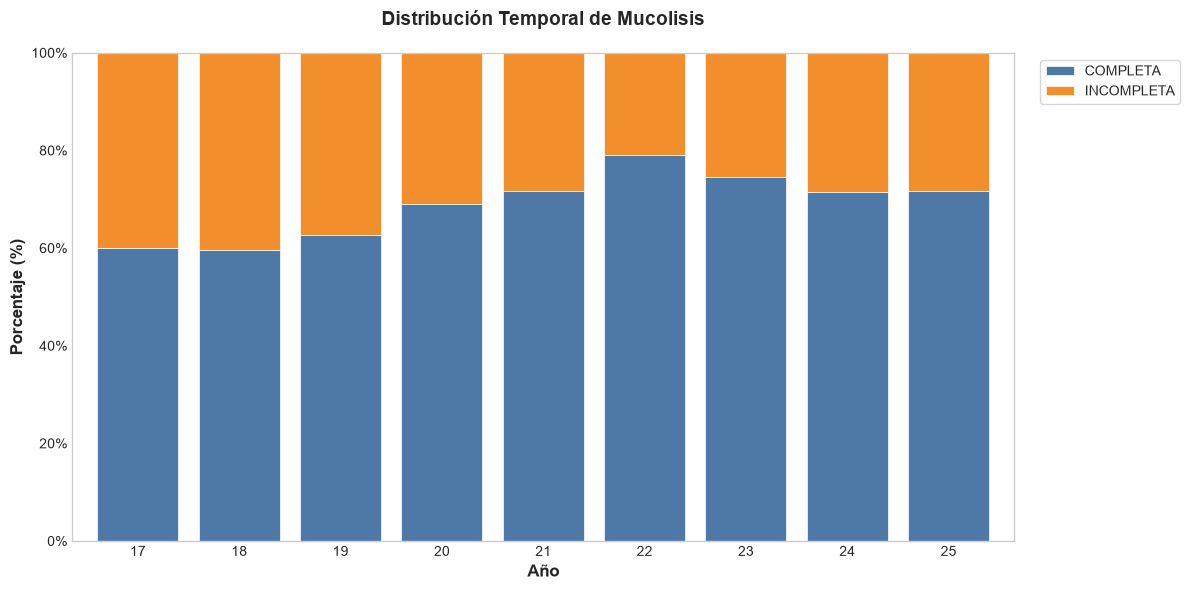

In [13]:
grafica_temporal('mucolisis','Mucolisis')

### **Viscosidad**

#### **Análisis de Bondad de Ajuste para la Variable Viscosidad**

Para evaluar si la distribución de frecuencias de la variable Viscosidad se ajusta a una distribución uniforme entre sus categorías, se aplica la prueba de chi-cuadrado de bondad de ajuste. Esta prueba permitirá determinar si existe una proporción significativamente diferente entre los niveles de viscosidad presentes en las muestras seminales, o si por el contrario se distribuyen de manera equitativa. Los resultados incluirán la tabla de frecuencias con porcentajes, el estadístico chi-cuadrado, los grados de libertad y el valor p asociado, así como pruebas post-hoc en caso de encontrar diferencias significativas entre las categorías.

In [14]:
chi_cuadrado_simple('viscosidad', 'Viscosidad')


Tabla de Frecuencias de Viscosidad


,Categoría,Frecuencia,Porcentaje
0,AUMENTADA,874,26.05
1,LIGERAMENTE AUMENTADA,322,9.60
2,MUY AUMENTADA,2,0.06
3,NORMAL,2157,64.29



Prueba de chi-cuadrado de bondad de ajuste:
- Chi² = 3196.29 | gl = 3 | p-value = <1e-10
Resultado significativo (p < 0.05)

Comparaciones significativas (p ajustado < 0.05):
- AUMENTADA vs LIGERAMENTE AUMENTADA: p-orig = <1e-10, p-ajust = <1e-10
- AUMENTADA vs MUY AUMENTADA: p-orig = <1e-10, p-ajust = <1e-10
- AUMENTADA vs NORMAL: p-orig = <1e-10, p-ajust = <1e-10
- LIGERAMENTE AUMENTADA vs MUY AUMENTADA: p-orig = <1e-10, p-ajust = <1e-10
- LIGERAMENTE AUMENTADA vs NORMAL: p-orig = <1e-10, p-ajust = <1e-10
- MUY AUMENTADA vs NORMAL: p-orig = <1e-10, p-ajust = <1e-10


**Resumen General**

La prueba de chi-cuadrado de bondad de ajuste evalúa si la distribución de la variable Viscosidad entre sus cuatro categorías se ajusta a una distribución uniforme (25% en cada categoría). Los resultados muestran una diferencia altamente significativa entre las proporciones observadas y las esperadas, con un desequilibrio extremadamente marcado en la distribución.

**Observaciones clave:**

- Casi 2 de cada 3 muestras (64.29%) presentan viscosidad normal
- 1 de cada 4 muestras (26.05%) presenta viscosidad aumentada
- Solo 1 de cada 10 muestras (9.60%) presenta viscosidad ligeramente aumentada
- Prácticamente inexistente la categoría "muy aumentada" (solo 2 casos, 0.06%)

**Interpretación del Resultado Significativo**

El resultado es extremadamente significativo (p < 1e-10), lo que indica que:

- **1. Las proporciones no son uniformes**: La distribución observada difiere drásticamente de lo que se esperaría si las cuatro categorías fueran igualmente probables (25% cada una)

- **2. Desequilibrio extremo**: 
   - **NORMAL** está muy sobrerrepresentada (64.29% vs 25% esperado)
   - **MUY AUMENTADA** está prácticamente ausente (0.06% vs 25% esperado)
   - **AUMENTADA** está ligeramente sobrerrepresentada (26.05% vs 25% esperado)
   - **LIGERAMENTE AUMENTADA** está subrepresentada (9.60% vs 25% esperado)

- **3. Evidencia abrumadora**: El valor p extremadamente bajo indica que la probabilidad de observar estas diferencias por azar es prácticamente nula

**Análisis de Pruebas Post-hoc**

Cada categoría de viscosidad tiene una frecuencia significativamente diferente de todas las demás categorías, confirmando que no hay dos categorías que se comporten de manera similar.

#### **Análisis de Asociación entre Año de Estudio y Viscosidad**

Para evaluar si la distribución de la viscosidad seminal (normal, ligeramente aumentada, aumentada o muy aumentada) ha variado a lo largo de los años de estudio, se aplica la prueba de chi-cuadrado de independencia. Este análisis permitirá determinar si existe una asociación significativa entre el año de realización del espermograma y el nivel de viscosidad observado, lo que podría reflejar cambios temporales en los patrones de viscosidad seminal, posibles modificaciones en los criterios de evaluación del laboratorio, o variaciones en las características de la población atendida a lo largo del tiempo.

In [15]:
chi_cuadrado_con_anios('viscosidad', 'Viscosidad')


Tabla de Contingencia: Año vs Viscosidad


viscosidad,AUMENTADA,LIGERAMENTE AUMENTADA,MUY AUMENTADA,NORMAL
año,,,,
17,123,43,0,201
18,133,55,0,253
19,145,47,0,255
20,75,33,0,198
21,93,30,2,249
22,62,28,0,273
23,77,20,0,266
24,73,25,0,232
25,93,41,0,230



Prueba de chi-cuadrado de independencia

Sugiriendo agrupación de categorías...
Categorías con pocas observaciones: ['MUY AUMENTADA']
Creando categoría 'Otros'...

Aún no se cumplen supuestos. Usando Monte Carlo en datos agrupados...
- Prueba usada: Chi-cuadrado con Monte Carlo (datos agrupados)
- Estadístico = 93.67 | p-value = <1e-10
Resultado significativo (p < 0.05)


Residuos Estandarizados


viscosidad,AUMENTADA,LIGERAMENTE AUMENTADA,NORMAL,Otros
año,,,,
17,2.80,1.31,-2.28,-0.47
18,1.69,1.95,-1.81,-0.51
19,2.65,0.63,-1.91,-0.52
20,-0.53,0.67,0.09,-0.43
21,-0.45,-0.98,0.55,3.76
22,-3.35,-1.16,2.59,-0.47
23,-1.81,-2.51,2.14,-0.47
24,-1.40,-1.19,1.36,-0.44
25,-0.19,1.03,-0.26,-0.47



Residuos Ajustados (> 1.96 o < -1.96 indican desviaciones de H0)


viscosidad,AUMENTADA,LIGERAMENTE AUMENTADA,NORMAL,Otros
año,,,,
17,3.45,1.46,-4.03,-0.50
18,2.11,2.20,-3.26,-0.55
19,3.31,0.71,-3.43,-0.55
20,-0.64,0.74,0.16,-0.45
21,-0.55,-1.10,0.98,3.99
22,-4.12,-1.29,4.60,-0.49
23,-2.22,-2.80,3.78,-0.49
24,-1.71,-1.31,2.40,-0.47
25,-0.23,1.14,-0.47,-0.49



Hallazgos Significativos en Residuos Ajustados
Celdas con |residuo ajustado| > 1.96:

17 × AUMENTADA
Residuo ajustado = 3.45
Frecuencia observada = 123
Frecuencia esperada = 95.61
La frecuencia observada es significativamente mayor a la esperada

17 × NORMAL
Residuo ajustado = -4.03
Frecuencia observada = 201
Frecuencia esperada = 235.95
La frecuencia observada es significativamente menor a la esperada

18 × AUMENTADA
Residuo ajustado = 2.11
Frecuencia observada = 133
Frecuencia esperada = 114.88
La frecuencia observada es significativamente mayor a la esperada

18 × LIGERAMENTE AUMENTADA
Residuo ajustado = 2.20
Frecuencia observada = 55
Frecuencia esperada = 42.33
La frecuencia observada es significativamente mayor a la esperada

18 × NORMAL
Residuo ajustado = -3.26
Frecuencia observada = 253
Frecuencia esperada = 283.53
La frecuencia observada es significativamente menor a la esperada

19 × AUMENTADA
Residuo ajustado = 3.31
Frecuencia observada = 145
Frecuencia esperada = 116.45
La 

**Resumen General**

El análisis de chi-cuadrado de independencia revela una asociación significativa entre el año de estudio y el nivel de viscosidad (p < 1e-10). Esto indica que la distribución de la viscosidad seminal ha variado a lo largo de los años. Sin embargo, debido al bajo número de casos en la categoría "MUY AUMENTADA", fue necesario agrupar categorías y utilizar una prueba de Monte Carlo para obtener resultados robustos.

**Resultados de la Prueba Estadística**

A pesar de las limitaciones en los datos (categoría "MUY AUMENTADA" prácticamente vacía), existe evidencia sólida de asociación entre el año y la viscosidad (p < 1e-10).

**Años con Mayor Proporción de Viscosidad NORMAL**

| Año | Residuo Ajustado (NORMAL) | Interpretación |
|-----|---------------------------|----------------|
| 2022 | 4.60 | Aportación muy significativa - Mayor viscosidad normal de lo esperado |
| 2023 | 3.78 | Aportación significativa - Mayor viscosidad normal de lo esperado |
| 2024 | 2.40 | Aportación significativa - Mayor viscosidad normal de lo esperado |

**Años con Menor Proporción de Viscosidad NORMAL**

| Año | Residuo Ajustado (NORMAL) | Interpretación |
|-----|---------------------------|----------------|
| 2017 | -4.03 | Aportación muy significativa - Menor viscosidad normal de lo esperado |
| 2019 | -3.43 | Aportación significativa - Menor viscosidad normal de lo esperado |
| 2018 | -3.26 | Aportación significativa - Menor viscosidad normal de lo esperado |

**Años con Mayor Proporción de Viscosidad AUMENTADA**

| Año | Residuo Ajustado (AUMENTADA) | Interpretación |
|-----|------------------------------|----------------|
| 2017 | 3.45 | Aportación significativa - Más viscosidad aumentada de lo esperado |
| 2019 | 3.31 | Aportación significativa - Más viscosidad aumentada de lo esperado |
| 2018 | 2.11 | Aportación significativa - Más viscosidad aumentada de lo esperado |

**Años con Menor Proporción de Viscosidad AUMENTADA**

| Año | Residuo Ajustado (AUMENTADA) | Interpretación |
|-----|------------------------------|----------------|
| 2022 | -4.12 | Aportación muy significativa - Menos viscosidad aumentada de lo esperado |
| 2023 | -2.22 | Aportación significativa - Menos viscosidad aumentada de lo esperado |

**Años con Mayor Proporción de Viscosidad LIGERAMENTE AUMENTADA**

| Año | Residuo Ajustado (LIG. AUMENTADA) | Interpretación |
|-----|-----------------------------------|----------------|
| 2018 | 2.20 | Aportación significativa - Más viscosidad ligeramente aumentada de lo esperado |

**Años con Menor Proporción de Viscosidad LIGERAMENTE AUMENTADA**

| Año | Residuo Ajustado (LIG. AUMENTADA) | Interpretación |
|-----|-----------------------------------|----------------|
| 2023 | -2.80 | Aportación significativa - Menos viscosidad ligeramente aumentada de lo esperado |

**Año Destacado en la Categoría "Otros" (MUY AUMENTADA)**

| Año | Residuo Ajustado (Otros) | Interpretación |
|-----|--------------------------|----------------|
| 2021 | 3.99 | Aportación muy significativa - Este año concentra los 2 únicos casos de viscosidad muy aumentada |

**Patrón Temporal Identificado**

- **Período 2017-2019 (Años iniciales)**
    - Menor proporción de viscosidad normal
    - Mayor proporción de viscosidad aumentada en 2017, 2018 y 2019
    - Mayor proporción de viscosidad ligeramente aumentada en 2018
    - Los tres años tienen menos viscosidad normal de lo esperado

- **Período 2020-2021 (Transición)**
    - Aumento de viscosidad normal
    - Disminución de viscosidad aumentada
    - 2021 destaca por los 2 casos de viscosidad muy aumentada (residuo 3.99 en "Otros")

- **Período 2022-2024 (Años intermedios)**
    - Alta proporción de viscosidad normal
    - Baja proporción de viscosidad aumentada
    - 2022 destaca como el año con mayor proporción de normal y residuo más alto (4.60)
    - 2023 y 2024 también muestran contribución significativa en normal

- **Período 2025 (Años recientes)**
    - Comportamiento cercano a lo esperado (sin contribución significativa)

#### **Visualización de la Evolución Temporal de la Viscosidad**

Para complementar el análisis de asociación entre el año de estudio y la viscosidad seminal, se genera una representación gráfica que permite visualizar de manera intuitiva la evolución temporal de la distribución de esta variable. El gráfico de barras apiladas muestra el porcentaje de muestras en cada categoría de viscosidad (normal, ligeramente aumentada, aumentada y muy aumentada) para cada año, facilitando la identificación de tendencias, puntos de cambio y patrones a lo largo del período estudiado.

Distribución de Viscosidad según Año de Estudio


viscosidad,AUMENTADA,LIGERAMENTE AUMENTADA,MUY AUMENTADA,NORMAL
año,,,,
17,33.51,11.72,0.00,54.77
18,30.16,12.47,0.00,57.37
19,32.44,10.51,0.00,57.05
20,24.51,10.78,0.00,64.71
21,24.87,8.02,0.53,66.58
22,17.08,7.71,0.00,75.21
23,21.21,5.51,0.00,73.28
24,22.12,7.58,0.00,70.30
25,25.55,11.26,0.00,63.19


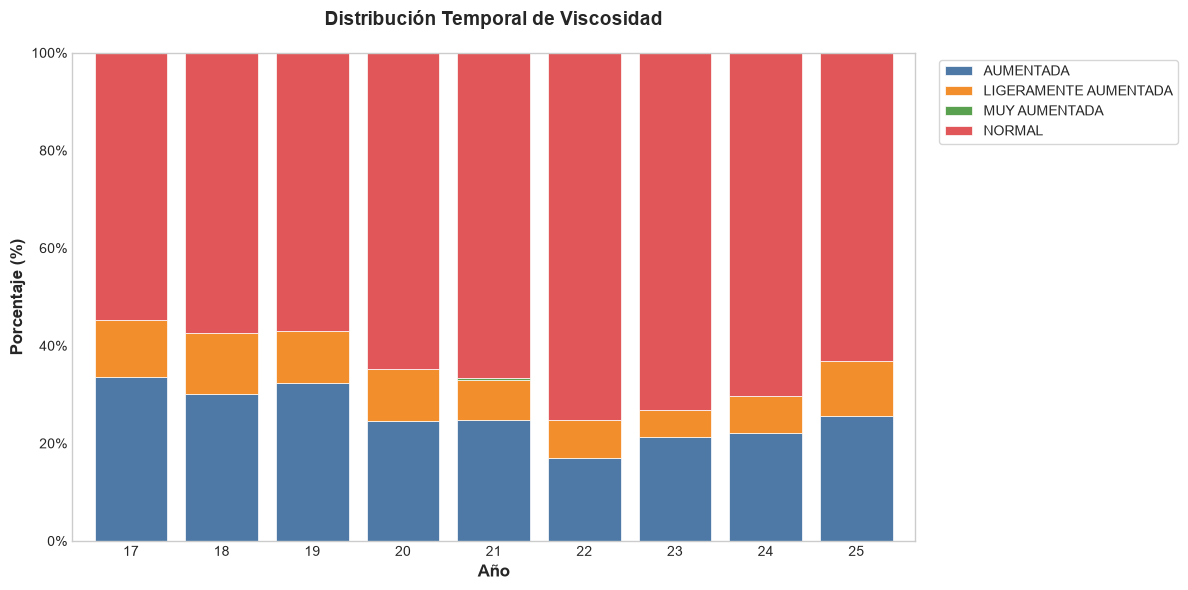

In [16]:
grafica_temporal('viscosidad','Viscosidad')

### **Trazas de Gel**

#### **Análisis de Bondad de Ajuste para la Variable Trazas de Gel**

Para evaluar si la distribución de frecuencias de la variable Trazas de Gel se ajusta a una distribución uniforme entre sus categorías, se aplica la prueba de chi-cuadrado de bondad de ajuste. Esta prueba permitirá determinar si existe una proporción significativamente diferente entre las categorías de esta variable (presencia o ausencia de trazas de gel en las muestras seminales), o si por el contrario se distribuyen de manera equitativa. Los resultados incluirán la tabla de frecuencias con porcentajes, el estadístico chi-cuadrado, los grados de libertad y el valor p asociado, así como pruebas post-hoc en caso de encontrar diferencias significativas entre las categorías.

In [17]:
chi_cuadrado_simple('trazas_gel', 'Trazas de Gel')


Tabla de Frecuencias de Trazas de Gel


,Categoría,Frecuencia,Porcentaje
0,NO,3300,97.43
1,SI,87,2.57



Prueba de chi-cuadrado de bondad de ajuste:
- Chi² = 3047.94 | gl = 1 | p-value = <1e-10
Resultado significativo (p < 0.05)



**Resumen General**

La prueba de chi-cuadrado de bondad de ajuste evalúa si la distribución de la variable Trazas de Gel entre sus dos categorías (SI y NO) se ajusta a una distribución uniforme (50% en cada categoría). Los resultados muestran una diferencia extremadamente significativa entre las proporciones observadas y las esperadas, con un desequilibrio abrumador en la distribución.

**Análisis de la Distribución de Frecuencias**

- La gran mayoría de las muestras (97.43%) no presentan trazas de gel
- Solo una minoría muy pequeña (2.57%) presenta trazas de gel
- La proporción observada es de aproximadamente 38:1 (NO:SI), frente a la esperada 1:1 (50% cada una)

**Interpretación del Resultado Significativo**

El resultado es extremadamente significativo (p < 1e-10), lo que indica que:

- **1. Las proporciones no son uniformes**: La distribución observada difiere drásticamente de lo que se esperaría si ambas categorías fueran igualmente probables

- **2. Desequilibrio extremo**: La categoría NO está muy sobrerrepresentada (97.43% vs 50% esperado), mientras que SI está muy subrepresentada (2.57% vs 50% esperado)

- **3. Evidencia abrumadora**: El valor p extremadamente bajo indica que la probabilidad de observar estas diferencias por azar es prácticamente nula

#### **Análisis de Asociación entre Año de Estudio y Trazas de Gel**

Para evaluar si la presencia de trazas de gel en las muestras seminales ha variado a lo largo de los años de estudio, se aplica la prueba de chi-cuadrado de independencia. Este análisis permitirá determinar si existe una asociación significativa entre el año de realización del espermograma y la presencia o ausencia de trazas de gel, lo que podría reflejar cambios temporales en la calidad del procesamiento de muestras, modificaciones en los protocolos de licuefacción, o variaciones en las características de la población atendida a lo largo del tiempo.

In [18]:
chi_cuadrado_con_anios('trazas_gel', 'Trazas de Gel')


Tabla de Contingencia: Año vs Trazas de Gel


trazas_gel,NO,SI
año,,
17,362,5
18,430,13
19,435,16
20,304,6
21,371,7
22,364,6
23,361,5
24,328,8
25,345,21



Prueba de chi-cuadrado de independencia
- Chi² = 23.55 | gl = 8 | p-value = 2.73e-03
Resultado significativo (p < 0.05)


Residuos Estandarizados


trazas_gel,NO,SI
año,,
17,0.23,-1.44
18,-0.08,0.48
19,-0.21,1.30
20,0.11,-0.70
21,0.14,-0.87
22,0.18,-1.14
23,0.23,-1.44
24,0.03,-0.21
25,-0.61,3.78



Residuos Ajustados (> 1.96 o < -1.96 indican desviaciones de H0)


trazas_gel,NO,SI
año,,
17,1.55,-1.55
18,-0.52,0.52
19,-1.41,1.41
20,0.74,-0.74
21,0.93,-0.93
22,1.22,-1.22
23,1.54,-1.54
24,0.23,-0.23
25,-4.06,4.06



Hallazgos Significativos en Residuos Ajustados
Celdas con |residuo ajustado| > 1.96:

25 × NO
Residuo ajustado = -4.06
Frecuencia observada = 345
Frecuencia esperada = 356.60
La frecuencia observada es significativamente menor a la esperada

25 × SI
Residuo ajustado = 4.06
Frecuencia observada = 21
Frecuencia esperada = 9.40
La frecuencia observada es significativamente mayor a la esperada



**Resumen General**

El análisis de chi-cuadrado de independencia revela una asociación significativa entre el año de estudio y la presencia de trazas de gel (p = 0.00273). Esto indica que la proporción de muestras con trazas de gel ha variado a lo largo de los años. Sin embargo, el análisis de residuos ajustados señala que esta asociación está impulsada principalmente por un año atípico: 2025.

**Resultados de la Prueba Estadística**

Existe evidencia significativa de asociación entre el año y la presencia de trazas de gel (p = 0.00273), aunque el nivel de significación es moderado en comparación con otras variables analizadas.

**Año con Mayor Proporción de Trazas de Gel**

| Año | Residuo Ajustado (SI) | Interpretación |
|-----|-----------------------|----------------|
| 2025 | 4.06 | Aportación muy significativa - Muchas más trazas de gel de lo esperado |

**Interpretación Detallada del Año 2025**

El año 2025 presenta un comportamiento claramente diferenciado:

- 21 casos con trazas de gel (5.74% de las muestras de ese año)
- Residuo ajustado de 4.06, muy por encima del umbral de significación (1.96)
- Es el año con mayor número absoluto y porcentual de trazas de gel en toda la serie

#### **Visualización de la Evolución Temporal de Trazas de Gel**

Para complementar el análisis de asociación entre el año de estudio y la presencia de trazas de gel, se genera una representación gráfica que permite visualizar de manera intuitiva la evolución temporal de la distribución de esta variable. El gráfico de barras apiladas muestra el porcentaje de muestras con y sin trazas de gel para cada año, facilitando la identificación de tendencias, puntos de cambio y patrones a lo largo del período estudiado. Esta visualización permitirá observar de forma clara la estabilidad general de la variable a lo largo de los años, así como el pico atípico identificado en 2025, donde la proporción de muestras con trazas de gel alcanzó su valor más alto de toda la serie temporal.

Distribución de Trazas de Gel según Año de Estudio


trazas_gel,NO,SI
año,,
17,98.64,1.36
18,97.07,2.93
19,96.45,3.55
20,98.06,1.94
21,98.15,1.85
22,98.38,1.62
23,98.63,1.37
24,97.62,2.38
25,94.26,5.74


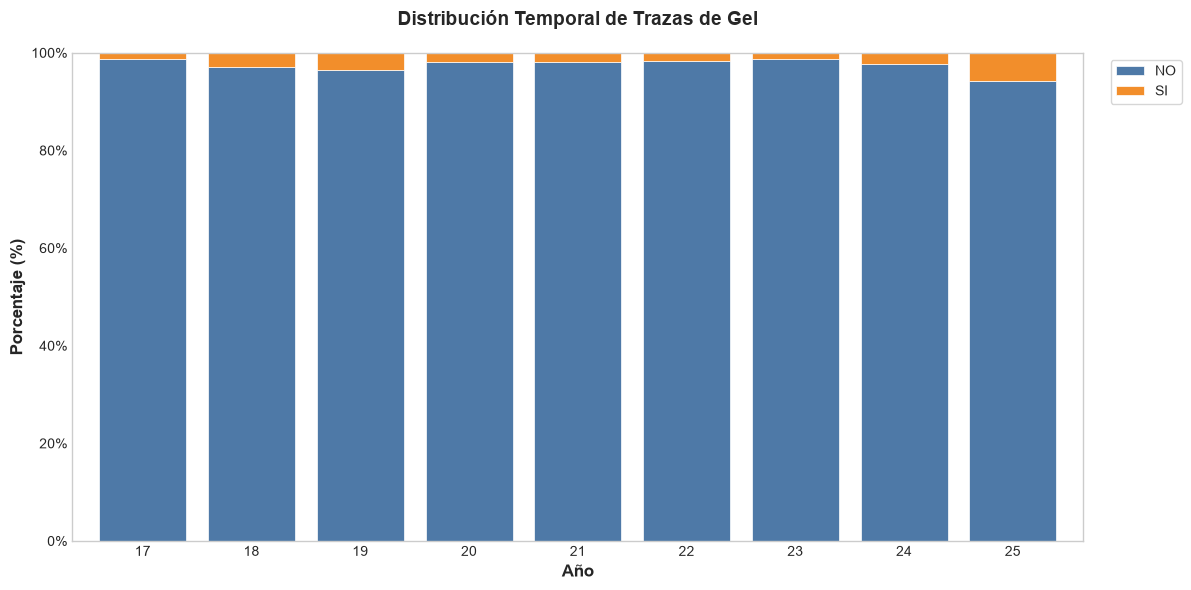

In [19]:
grafica_temporal('trazas_gel','Trazas de Gel')

### **Bacterias (Examen a la Hora)**

#### **Análisis de Bondad de Ajuste para la Variable Examen Hora**

Para evaluar si la distribución de frecuencias de la variable Bacterias se ajusta a una distribución uniforme entre sus categorías, se aplica la prueba de chi-cuadrado de bondad de ajuste. Esta prueba permitirá determinar si existe una proporción significativamente diferente, o si por el contrario se distribuyen de manera equitativa. Los resultados incluirán la tabla de frecuencias con porcentajes, el estadístico chi-cuadrado, los grados de libertad y el valor p asociado, así como pruebas post-hoc en caso de encontrar diferencias significativas entre las categorías.

In [20]:
chi_cuadrado_simple('examen_hora', 'Bacterias')


Tabla de Frecuencias de Bacterias


,Categoría,Frecuencia,Porcentaje
0,BACTERIAS,4,0.16
1,BACTERIAS +,897,36.11
2,BACTERIAS ++,683,27.50
3,BACTERIAS +++,149,6.00
4,BACTERIAS ++++,9,0.36
5,BACTERIAS = 2000000,1,0.04
6,ESCASAS,741,29.83



Prueba de chi-cuadrado de bondad de ajuste:
- Chi² = 2226.90 | gl = 6 | p-value = <1e-10
Resultado significativo (p < 0.05)

Comparaciones significativas (p ajustado < 0.05):
- BACTERIAS vs BACTERIAS +: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS vs BACTERIAS ++: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS vs BACTERIAS +++: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS vs ESCASAS: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS + vs BACTERIAS ++: p-orig = 7.29e-08, p-ajust = 1.53e-06
- BACTERIAS + vs BACTERIAS +++: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS + vs BACTERIAS ++++: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS + vs BACTERIAS = 2000000: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS + vs ESCASAS: p-orig = 1.16e-04, p-ajust = 2.44e-03
- BACTERIAS ++ vs BACTERIAS +++: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS ++ vs BACTERIAS ++++: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS ++ vs BACTERIAS = 2000000: p-orig = <1e-10, p-ajust = <1e-10
- BACTERIAS +++ vs BACTERIAS ++

**Resumen General**

La prueba de chi-cuadrado de bondad de ajuste evalúa si la distribución de la variable Bacterias entre sus siete categorías se ajusta a una distribución uniforme (aproximadamente 14.3% en cada categoría). Los resultados muestran una diferencia extremadamente significativa entre las proporciones observadas y las esperadas, con un desequilibrio muy marcado en la distribución.

**Análisis de la Distribución de Frecuencias**

- Las tres categorías principales (BACTERIAS +, ESCASAS, BACTERIAS ++) concentran el 93.44% de las muestras
- Las categorías de mayor severidad (BACTERIAS +++, ++++, = 2000000) son poco frecuentes (solo 159 casos, 6.40%)
- Existe una gradación que sugiere una escala semicuantitativa de presencia bacteriana (+, ++, +++, ++++)

**Resultados de la Prueba Estadística**

El resultado es extremadamente significativo (p < 1e-10), lo que indica que las proporciones observadas difieren drásticamente de lo que se esperaría si todas las categorías fueran igualmente probables.

**Comparaciones No Significativas (p ≥ 0.05)**

| Par de Categorías | Resultado | Interpretación |
|-------------------|-----------|----------------|
| BACTERIAS vs BACTERIAS ++++ | ✗ | No hay diferencia significativa |
| BACTERIAS vs BACTERIAS = 2000000 | ✗ | No hay diferencia significativa |
| BACTERIAS ++ vs ESCASAS | ✗ | No hay diferencia significativa |
| BACTERIAS ++++ vs BACTERIAS = 2000000 | ✗ | No hay diferencia significativa |

- **BACTERIAS vs BACTERIAS ++++**: Ambas categorías tienen frecuencias muy bajas (4 y 9 casos respectivamente)
- **BACTERIAS vs BACTERIAS = 2000000**: Frecuencias extremadamente bajas en ambas (4 y 1 caso)
- **BACTERIAS ++ vs ESCASAS**: Frecuencias similares (683 y 741 casos), lo que sugiere que estas dos categorías podrían ser consideradas equivalentes en términos de frecuencia
- **BACTERIAS ++++ vs BACTERIAS = 2000000**: Frecuencias extremadamente bajas en ambas (9 y 1 caso)

#### **Análisis de Asociación entre Año de Estudio y Presencia Bacteriana**

Para evaluar si la presencia y severidad de bacterias en las muestras seminales ha variado a lo largo de los años de estudio, se aplica la prueba de chi-cuadrado de independencia. Este análisis permitirá determinar si existe una asociación significativa entre el año de realización del espermograma y el nivel de presencia bacteriana (+, ++, +++, ++++, escasas, etc.), lo que podría reflejar cambios temporales en la prevalencia de infecciones o colonizaciones del tracto reproductivo, modificaciones en los criterios de evaluación del laboratorio, variaciones en las características de la población atendida, o posibles mejoras en las prácticas de recolección y procesamiento de muestras a lo largo del tiempo.

In [21]:
chi_cuadrado_con_anios('examen_hora', 'Bacterias')


Tabla de Contingencia: Año vs Bacterias


examen_hora,BACTERIAS,BACTERIAS +,BACTERIAS ++,BACTERIAS +++,BACTERIAS ++++,BACTERIAS = 2000000,ESCASAS
año,,,,,,,
17,1,110,105,34,3,0,84
18,0,155,95,14,0,0,119
19,1,145,70,30,3,0,121
20,0,93,57,16,2,0,76
21,0,96,74,16,1,0,102
22,1,82,92,14,0,1,76
23,1,79,87,12,0,0,49
24,0,96,63,10,0,0,75
25,0,41,40,3,0,0,39



Prueba de chi-cuadrado de independencia

Sugiriendo agrupación de categorías...
Categorías con pocas observaciones: ['BACTERIAS', 'BACTERIAS = 2000000']
Creando categoría 'Otros'...

Aún no se cumplen supuestos. Usando Monte Carlo en datos agrupados...
- Prueba usada: Chi-cuadrado con Monte Carlo (datos agrupados)
- Estadístico = 89.39 | p-value = 2.00e-04
Resultado significativo (p < 0.05)


Residuos Estandarizados


examen_hora,BACTERIAS +,BACTERIAS ++,BACTERIAS +++,BACTERIAS ++++,ESCASAS,Otros
año,,,,,,
17,-1.06,1.28,3.07,1.61,-1.65,0.39
18,1.42,-1.00,-1.87,-1.18,0.44,-0.88
19,0.99,-3.15,1.66,1.43,1.01,0.30
20,0.52,-1.23,0.36,1.19,0.38,-0.70
21,-0.82,-0.61,-0.32,-0.05,1.70,-0.76
22,-1.43,2.21,-0.49,-0.98,-0.38,2.00
23,-0.37,3.07,-0.45,-0.91,-2.31,0.80
24,0.84,-0.50,-1.21,-0.94,0.26,-0.70
25,-0.51,1.06,-1.61,-0.67,0.38,-0.50



Residuos Ajustados (> 1.96 o < -1.96 indican desviaciones de H0)


examen_hora,BACTERIAS +,BACTERIAS ++,BACTERIAS +++,BACTERIAS ++++,ESCASAS,Otros
año,,,,,,
17,-1.43,1.62,3.40,1.73,-2.12,0.42
18,1.93,-1.28,-2.10,-1.28,0.58,-0.96
19,1.34,-4.01,1.85,1.56,1.31,0.32
20,0.69,-1.52,0.39,1.25,0.47,-0.74
21,-1.09,-0.77,-0.35,-0.05,2.16,-0.81
22,-1.90,2.74,-0.53,-1.04,-0.48,2.12
23,-0.48,3.78,-0.49,-0.96,-2.89,0.84
24,1.11,-0.62,-1.32,-0.99,0.33,-0.74
25,-0.66,1.28,-1.71,-0.69,0.47,-0.51



Hallazgos Significativos en Residuos Ajustados
Celdas con |residuo ajustado| > 1.96:

17 × BACTERIAS +++
Residuo ajustado = 3.40
Frecuencia observada = 34
Frecuencia esperada = 20.21
La frecuencia observada es significativamente mayor a la esperada

17 × ESCASAS
Residuo ajustado = -2.12
Frecuencia observada = 84
Frecuencia esperada = 100.53
La frecuencia observada es significativamente menor a la esperada

18 × BACTERIAS +++
Residuo ajustado = -2.10
Frecuencia observada = 14
Frecuencia esperada = 22.97
La frecuencia observada es significativamente menor a la esperada

19 × BACTERIAS ++
Residuo ajustado = -4.01
Frecuencia observada = 70
Frecuencia esperada = 101.74
La frecuencia observada es significativamente menor a la esperada

21 × ESCASAS
Residuo ajustado = 2.16
Frecuencia observada = 102
Frecuencia esperada = 86.21
La frecuencia observada es significativamente mayor a la esperada

22 × BACTERIAS ++
Residuo ajustado = 2.74
Frecuencia observada = 92
Frecuencia esperada = 73.14
La f

**Resumen General**

El análisis de chi-cuadrado de independencia revela una asociación significativa entre el año de estudio y la presencia de bacterias (p = 0.0002). Esto indica que la distribución de la presencia bacteriana en las muestras seminales ha variado a lo largo de los años. Sin embargo, debido a la baja frecuencia en varias categorías, fue necesario agrupar categorías y utilizar una prueba de Monte Carlo para obtener resultados robustos.

**Resultados de la Prueba Estadística**

Existe evidencia significativa de asociación entre el año y la presencia bacteriana (p = 0.0002), aunque la fuerza de la asociación es moderada.

**Años con Mayor Proporción de BACTERIAS +++**

| Año | Residuo Ajustado (+++) | Interpretación |
|-----|------------------------|----------------|
| 2017 | 3.40 | Aportación significativa - Más bacterias +++ de lo esperado |

**Años con Menor Proporción de BACTERIAS +++**

| Año | Residuo Ajustado (+++) | Interpretación |
|-----|------------------------|----------------|
| 2018 | -2.10 | Aportación significativa - Menos bacterias +++ de lo esperado |

**Años con Mayor Proporción de BACTERIAS ++**

| Año | Residuo Ajustado (++) | Interpretación |
|-----|-----------------------|----------------|
| 2023 | 3.78 | Aportación muy significativa - Más bacterias ++ de lo esperado |
| 2022 | 2.74 | Aportación significativa - Más bacterias ++ de lo esperado |

**Años con Menor Proporción de BACTERIAS ++**

| Año | Residuo Ajustado (++) | Interpretación |
|-----|-----------------------|----------------|
| 2019 | -4.01 | Aportación muy significativa - Menos bacterias ++ de lo esperado |

**Años con Mayor Proporción de ESCASAS**

| Año | Residuo Ajustado (ESCASAS) | Interpretación |
|-----|----------------------------|----------------|
| 2021 | 2.16 | Aportación significativa - Más bacterias escasas de lo esperado |

**Años con Menor Proporción de ESCASAS**

| Año | Residuo Ajustado (ESCASAS) | Interpretación |
|-----|----------------------------|----------------|
| 2023 | -2.89 | Aportación significativa - Menos bacterias escasas de lo esperado |
| 2017 | -2.12 | Aportación significativa - Menos bacterias escasas de lo esperado |

**Año Destacado en la Categoría "Otros"**

| Año | Residuo Ajustado (Otros) | Interpretación |
|-----|--------------------------|----------------|
| 2022 | 2.12 | Aportación significativa - Este año concentra categorías atípicas (BACTERIAS y =2000000) |

**Patrón Temporal Identificado**

- **Período 2017-2019 (Años iniciales)**
    - Mayor variabilidad en la distribución bacteriana
    - 2017 presenta mayor proporción de BACTERIAS +++ (casos más severos) y menor de ESCASAS
    - 2018 presenta menor proporción de BACTERIAS +++
    - 2019 presenta menor proporción de BACTERIAS ++

- **Período 2020-2021 (Transición)**
    - Estabilización relativa
    - 2021 presenta mayor proporción de ESCASAS (categoría menos severa)

- **Período 2022-2023 (Cambios)**
    - Aumento de BACTERIAS ++ en ambos años
    - 2022 también destaca en la categoría "Otros" (casos atípicos)
    - 2023 presenta mayor BACTERIAS ++ y menor ESCASAS

- **Período 2024-2025 (Años recientes)**
    - Disminución del número total de observaciones (especialmente en 2025)
    - Menor presencia de casos severos (BACTERIAS +++ y ++++)
    - Distribución más homogénea, aunque con datos más limitados

#### **Visualización de la Evolución Temporal de la Presencia Bacteriana**

Para complementar el análisis de asociación entre el año de estudio y la presencia bacteriana en las muestras seminales, se genera una representación gráfica que permite visualizar de manera intuitiva la evolución temporal de la distribución de esta variable. El gráfico de barras apiladas muestra el porcentaje de muestras en cada categoría de presencia bacteriana (+, ++, +++, ++++, escasas, etc.) para cada año, facilitando la identificación de tendencias, puntos de cambio y patrones a lo largo del período estudiado. Esta visualización permitirá observar de forma clara la variación en la severidad de la presencia bacteriana a lo largo de los años, incluyendo la mayor proporción de casos severos en los años iniciales y los cambios en las categorías intermedias observados en años más recientes.

Distribución de Bacterias según Año de Estudio


examen_hora,BACTERIAS,BACTERIAS +,BACTERIAS ++,BACTERIAS +++,BACTERIAS ++++,BACTERIAS = 2000000,ESCASAS
año,,,,,,,
17,0.30,32.64,31.16,10.09,0.89,0.00,24.93
18,0.00,40.47,24.80,3.66,0.00,0.00,31.07
19,0.27,39.19,18.92,8.11,0.81,0.00,32.70
20,0.00,38.11,23.36,6.56,0.82,0.00,31.15
21,0.00,33.22,25.61,5.54,0.35,0.00,35.29
22,0.38,30.83,34.59,5.26,0.00,0.38,28.57
23,0.44,34.65,38.16,5.26,0.00,0.00,21.49
24,0.00,39.34,25.82,4.10,0.00,0.00,30.74
25,0.00,33.33,32.52,2.44,0.00,0.00,31.71


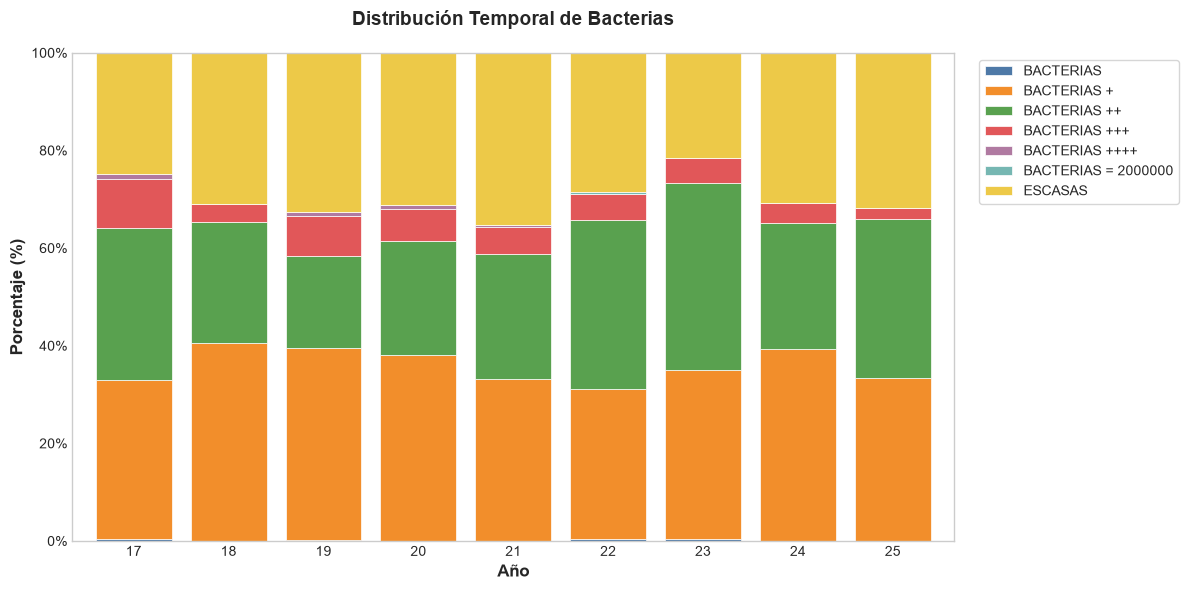

In [22]:
grafica_temporal('examen_hora','Bacterias')

## **Variables Cuantitativas**

### **Edad**

#### **Análisis Descriptivo y Visual de la Distribución de Edad a lo Largo del Tiempo**

Para caracterizar la evolución temporal de la edad de los pacientes que acuden al estudio seminal, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en la edad de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Edad según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,367,36.64,7.00,21.00,31.50,36.00,41.00,63.00,9.50,19.09,0.51,0.32
18,443,37.44,7.48,20.00,32.00,36.00,42.00,68.00,10.00,19.97,0.86,1.12
19,451,37.14,7.25,21.00,32.00,36.00,41.00,69.00,9.00,19.51,0.83,1.44
20,310,37.22,7.22,22.00,32.00,36.00,41.00,73.00,9.00,19.39,1.10,2.18
21,378,36.98,7.32,17.00,33.00,37.00,41.00,68.00,8.00,19.78,0.71,2.27
22,370,37.74,7.23,20.00,33.00,37.00,41.00,67.00,8.00,19.14,0.96,1.92
23,366,38.85,7.56,21.00,34.00,38.00,43.00,69.00,9.00,19.47,0.89,1.71
24,336,38.75,8.08,21.00,33.00,38.00,43.00,67.00,10.00,20.85,0.68,0.61
25,366,38.25,7.32,21.00,33.25,38.00,42.00,66.00,8.75,19.14,0.82,1.57


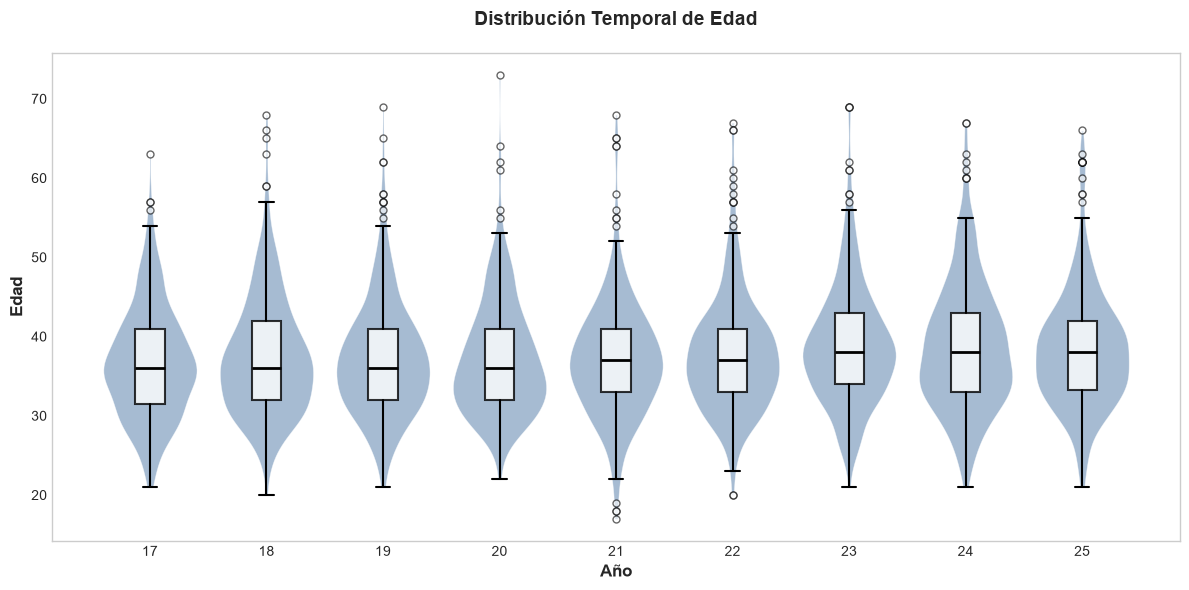

In [23]:
graficas_numericas(df,'edad', 'Edad', color='#4E79A7')

**Resumen General**

La tabla muestra los estadísticos descriptivos de la edad de los pacientes para cada año del estudio (2017-2025). Se observa una tendencia al aumento de la edad promedio a lo largo de los años, con una media que pasa de 36.64 años en 2017 a 38.25 años en 2025. La distribución de la edad muestra una variabilidad moderada y consistente en todos los años, con desviaciones estándar alrededor de 7-8 años.

**Análisis de Medidas de Tendencia Central**

| Año | Media | Mediana (Q2) | Diferencia | Interpretación |
|-----|-------|--------------|------------|----------------|
| 2017 | 36.64 | 36.0 | +0.64 | Distribución ligeramente sesgada a la derecha |
| 2018 | 37.44 | 36.0 | +1.44 | Sesgo positivo moderado |
| 2019 | 37.14 | 36.0 | +1.14 | Sesgo positivo moderado |
| 2020 | 37.22 | 36.0 | +1.22 | Sesgo positivo moderado |
| 2021 | 36.98 | 37.0 | -0.02 | Distribución prácticamente simétrica |
| 2022 | 37.74 | 37.0 | +0.74 | Sesgo positivo leve |
| 2023 | 38.85 | 38.0 | +0.85 | Sesgo positivo leve |
| 2024 | 38.75 | 38.0 | +0.75 | Sesgo positivo leve |
| 2025 | 38.25 | 38.0 | +0.25 | Distribución prácticamente simétrica |

- La media es ligeramente mayor que la mediana en la mayoría de los años, indicando un sesgo positivo (cola hacia edades mayores)
- 2021 y 2025 presentan la mayor simetría (media ≈ mediana)
- La edad más frecuente (mediana) ha aumentado de 36 a 38 años a lo largo del período

**Evolución de la Edad Promedio**

| Período | Media | Tendencia |
|---------|-------|-----------|
| 2017-2021 | 36.64 - 37.44 | Estable (~37 años) |
| 2022-2025 | 37.74 - 38.85 | Aumento progresivo |

- Hasta 2021 la edad promedio se mantiene relativamente estable alrededor de 37 años
- A partir de 2022 se observa un aumento sostenido, alcanzando casi 39 años en 2023-2024
- Aumento de aproximadamente 2 años en la edad promedio entre 2017 y 2024

**Análisis de Dispersión**

| Año | Std | IQR | CV (%) | Interpretación |
|-----|-----|-----|--------|----------------|
| 2017 | 7.00 | 9.50 | 19.09 | Variabilidad moderada |
| 2018 | 7.48 | 10.00 | 19.97 | Variabilidad moderada |
| 2019 | 7.25 | 9.00 | 19.51 | Variabilidad moderada |
| 2020 | 7.22 | 9.00 | 19.39 | Variabilidad moderada |
| 2021 | 7.32 | 8.00 | 19.78 | Variabilidad moderada |
| 2022 | 7.23 | 8.00 | 19.14 | Variabilidad moderada |
| 2023 | 7.56 | 9.00 | 19.47 | Variabilidad moderada |
| 2024 | 8.08 | 10.00 | 20.85 | Variabilidad moderada-alta |
| 2025 | 7.32 | 8.75 | 19.14 | Variabilidad moderada |

- Coeficiente de variación (CV) estable alrededor del 19-21%, indicando dispersión relativa consistente en todos los años
- Rango intercuartílico (IQR) varía entre 8 y 10 años, mostrando que el 50% central de los pacientes se concentra en un rango de aproximadamente 9 años
- El año 2024 presenta la mayor variabilidad (CV > 20%)

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | 0.51 | 0.32 | Sesgo positivo leve, distribución platicúrtica |
| 2018 | 0.86 | 1.12 | Sesgo positivo moderado |
| 2019 | 0.83 | 1.44 | Sesgo positivo moderado |
| 2020 | 1.10 | 2.18 | Sesgo positivo notable, más apuntada |
| 2021 | 0.71 | 2.27 | Sesgo positivo moderado, más apuntada |
| 2022 | 0.96 | 1.92 | Sesgo positivo moderado |
| 2023 | 0.89 | 1.71 | Sesgo positivo moderado |
| 2024 | 0.68 | 0.61 | Sesgo positivo leve |
| 2025 | 0.82 | 1.57 | Sesgo positivo moderado |

- Sesgo positivo en todos los años (Skew > 0): Hay más pacientes jóvenes que mayores, pero existen algunos pacientes de edad avanzada que "jalan" la media hacia la derecha
- La mayoría de los años presentan valores positivos, indicando distribuciones ligeramente más apuntadas que una distribución normal
- 2020 y 2021 presentan la mayor curtosis (2.18 y 2.27), sugiriendo distribuciones más concentradas alrededor de la media

**Rango de Edades**

| Año | Mínimo | Máximo | Rango | Interpretación |
|-----|--------|--------|-------|----------------|
| 2017 | 21 | 63 | 42 | Rango amplio |
| 2018 | 20 | 68 | 48 | Rango más amplio |
| 2019 | 21 | 69 | 48 | Rango más amplio |
| 2020 | 22 | 73 | 51 | Rango muy amplio |
| 2021 | 17 | 68 | 51 | Rango muy amplio |
| 2022 | 20 | 67 | 47 | Rango amplio |
| 2023 | 21 | 69 | 48 | Rango amplio |
| 2024 | 21 | 67 | 46 | Rango amplio |
| 2025 | 21 | 66 | 45 | Rango amplio |

- Edad mínima entre 17 y 22 años (el paciente más joven se registró en 2021)
- Edad máxima entre 63 y 73 años (el paciente más mayor se registró en 2020)
- El rango de edades es amplio en todos los años (42-51 años)

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación de Edad por Año**

Para evaluar si existe relación entre el año de estudio y la edad de los pacientes, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las edades medias entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en la edad de los pacientes.

In [24]:
funcion_numericas(df,'edad', 'Edad')


=== Edad ===

Prueba de Normalidad Global
- n = 3387, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 367, p-value = 1.33e-04 → No Normal
- Año 18: n = 443, p-value = 7.70e-10 → No Normal
- Año 19: n = 451, p-value = 3.67e-09 → No Normal
- Año 20: n = 310, p-value = 4.19e-10 → No Normal
- Año 21: n = 378, p-value = 3.37e-08 → No Normal
- Año 22: n = 370, p-value = 7.06e-10 → No Normal
- Año 23: n = 366, p-value = 5.93e-09 → No Normal
- Año 24: n = 336, p-value = 2.87e-06 → No Normal
- Año 25: n = 366, p-value = 1.01e-08 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.22, p-value = 2.85e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 32.81, p-value = 6.65e-05
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     17  

**Resumen General**

El análisis estadístico revela que existen diferencias significativas en la edad de los pacientes entre los años de estudio (p = 6.65e-05). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados. Las pruebas post-hoc con corrección de Bonferroni identifican que las diferencias se concentran principalmente entre los años iniciales (2017, 2019, 2020) y los años intermedios (2023, 2024).

**Evaluación de Supuestos**

- Todos los años presentan una distribución de edad que no sigue una distribución normal (p < 0.05 en todos los casos)
- El tamaño muestral es suficiente en todos los años (n ≥ 310, con la mayoría > 365)
- Esta falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p = 0.285)
- Las varianzas de edad son similares entre los años
- Aunque las varianzas son homogéneas, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- Existe evidencia sólida de que la edad de los pacientes varía entre los años (p < 0.001)
- El estadístico H = 32.81 indica una diferencia moderadamente fuerte
- La probabilidad de observar estas diferencias por azar es extremadamente baja (0.00665%)

**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value (Bonferroni) | Interpretación |
|-------------|---------------------|----------------|
| 2017 vs 2023 | 0.002 | Diferencia muy significativa |
| 2017 vs 2024 | 0.025 | Diferencia significativa |
| 2019 vs 2023 | 0.020 | Diferencia significativa |
| 2020 vs 2023 | 0.032 | Diferencia significativa |

### **Días de Abstinencia**

#### **Análisis Descriptivo y Visual de la Distribución de Días de Abstinencia a lo Largo del Tiempo**

Para caracterizar la evolución temporal de los días de abstinencia sexual previa al estudio seminal, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en los días de abstinencia de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Días de Abstinencia según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,367,3.89,1.09,1,3.00,4.00,5.00,10,2.00,28.13,1.04,2.74
18,443,4.08,3.38,1,3.00,4.00,5.00,45,2.00,82.75,9.68,106.57
19,451,3.94,1.36,0,3.00,4.00,5.00,20,2.00,34.42,3.92,43.64
20,310,3.97,1.85,1,3.00,4.00,4.00,30,1.00,46.57,9.35,127.59
21,378,4.12,2.27,1,3.00,4.00,5.00,40,2.00,55.18,10.90,166.76
22,370,4.15,1.61,1,3.00,4.00,5.00,15,2.00,38.79,3.44,21.29
23,366,4.10,1.33,0,3.00,4.00,5.00,10,2.00,32.37,0.74,2.67
24,336,4.16,3.73,1,3.00,4.00,5.00,60,2.00,89.54,11.44,159.05
25,366,4.06,2.02,1,3.00,4.00,5.00,30,2.00,49.71,6.40,75.16


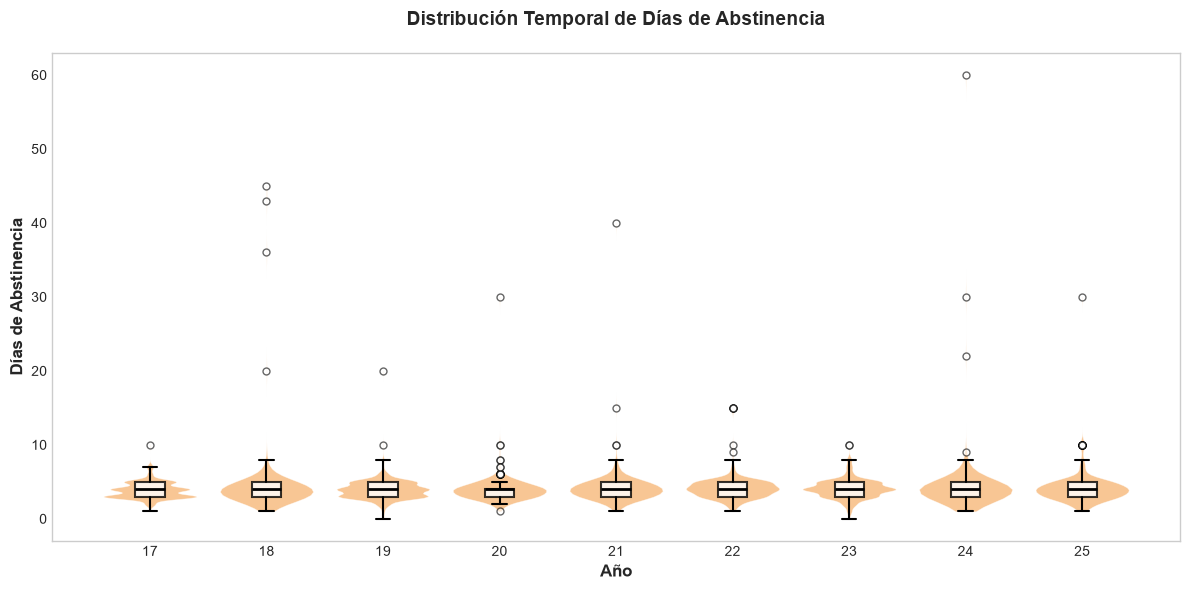

In [25]:
graficas_numericas(df, 'dias_abstinencia', 'Días de Abstinencia', color='#F28E2B')

**Resumen General**

La tabla muestra los estadísticos descriptivos de los días de abstinencia sexual previa al estudio seminal para cada año del período 2017-2025. Se observa que la mediana se mantiene estable en 4 días en todos los años, mientras que la media varía ligeramente entre 3.89 y 4.16 días. Sin embargo, la presencia de valores extremos (outliers) en algunos años genera una gran variabilidad y asimetría en la distribución, especialmente en 2018, 2021 y 2024, donde se registran abstinencias de hasta 60 días.

**Análisis de Medidas de Tendencia Central**

| Año | Media | Mediana (Q2) | Diferencia | Interpretación |
|-----|-------|--------------|------------|----------------|
| 2017 | 3.89 | 4.0 | -0.11 | Distribución ligeramente sesgada a la izquierda |
| 2018 | 4.08 | 4.0 | +0.08 | Sesgo positivo por outliers extremos |
| 2019 | 3.94 | 4.0 | -0.06 | Distribución ligeramente sesgada a la izquierda |
| 2020 | 3.97 | 4.0 | -0.03 | Distribución prácticamente simétrica |
| 2021 | 4.12 | 4.0 | +0.12 | Sesgo positivo por outliers extremos |
| 2022 | 4.15 | 4.0 | +0.15 | Sesgo positivo moderado |
| 2023 | 4.10 | 4.0 | +0.10 | Sesgo positivo leve |
| 2024 | 4.16 | 4.0 | +0.16 | Sesgo positivo por outliers extremos |
| 2025 | 4.06 | 4.0 | +0.06 | Sesgo positivo leve |

- La mediana es constante (4 días) en todos los años, indicando que el valor central es muy estable
- La media es ligeramente superior a la mediana en la mayoría de los años, indicando sesgo positivo
- La diferencia media-mediana es pequeña (< 0.2 días), lo que sugiere que la mayoría de los datos se concentran alrededor de 4 días

**Evolución de los Días de Abstinencia**

| Período | Media | Mediana | Interpretación |
|---------|-------|---------|----------------|
| 2017-2020 | 3.89 - 4.08 | 4.0 | Estable alrededor de 4 días |
| 2021-2024 | 4.10 - 4.16 | 4.0 | Leve aumento en la media |
| 2025 | 4.06 | 4.0 | Retorno a valores cercanos a 4 días |

- No hay una tendencia clara en los días de abstinencia a lo largo del tiempo
- La mediana se mantiene en 4 días en todos los años, lo que sugiere estabilidad
- Las pequeñas variaciones en la media se deben principalmente a la presencia de valores extremos

**Análisis de Dispersión**

| Año | Std | IQR | CV (%) | Interpretación |
|-----|-----|-----|--------|----------------|
| 2017 | 1.09 | 2.0 | 28.13 | Baja variabilidad |
| 2018 | 3.38 | 2.0 | 82.75 | Variabilidad muy alta (outliers extremos) |
| 2019 | 1.36 | 2.0 | 34.42 | Variabilidad moderada |
| 2020 | 1.85 | 1.0 | 46.57 | Variabilidad alta |
| 2021 | 2.27 | 2.0 | 55.18 | Variabilidad alta |
| 2022 | 1.61 | 2.0 | 38.79 | Variabilidad moderada |
| 2023 | 1.33 | 2.0 | 32.37 | Variabilidad moderada |
| 2024 | 3.73 | 2.0 | 89.54 | Variabilidad muy alta (outliers extremos) |
| 2025 | 2.02 | 2.0 | 49.71 | Variabilidad alta |

- El IQR es de 2 días en casi todos los años (excepto 2020 con 1 día), indicando que el 50% central de los pacientes tiene abstinencias entre 3 y 5 días
- El CV varía enormemente (28.13% a 89.54%), reflejando la presencia de valores extremos
- 2018, 2021 y 2024 presentan la mayor variabilidad debido a outliers extremos (abstinencias de hasta 60 días)

**Análisis de Valores Extremos (Outliers)**

| Año | Máximo | Interpretación |
|-----|--------|----------------|
| 2017 | 10 | Valor máximo razonable |
| 2018 | 45 | Outlier extremo (45 días) |
| 2019 | 20 | Outlier (20 días) |
| 2020 | 30 | Outlier extremo (30 días) |
| 2021 | 40 | Outlier extremo (40 días) |
| 2022 | 15 | Outlier (15 días) |
| 2023 | 10 | Valor máximo razonable |
| 2024 | 60 | Outlier extremo (60 días) |
| 2025 | 30 | Outlier extremo (30 días) |

- La mayoría de los pacientes (75%) tienen abstinencias de 5 días o menos (Q3 = 5)
- Los valores máximos extremos (> 20 días) aparecen en varios años (2018, 2020, 2021, 2024, 2025)
- 2017 y 2023 son los años con menor presencia de outliers (máximo de 10 días)

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | 1.04 | 2.74 | Sesgo positivo moderado |
| 2018 | 9.68 | 106.57 | Sesgo extremo (outliers) |
| 2019 | 3.92 | 43.64 | Sesgo extremo (outliers) |
| 2020 | 9.35 | 127.59 | Sesgo extremo (outliers) |
| 2021 | 10.90 | 166.76 | Sesgo extremo (outliers) |
| 2022 | 3.44 | 21.29 | Sesgo extremo (outliers) |
| 2023 | 0.74 | 2.67 | Sesgo positivo leve, distribución relativamente normal |
| 2024 | 11.44 | 159.05 | Sesgo extremo (outliers) |
| 2025 | 6.40 | 75.16 | Sesgo extremo (outliers) |

- La mayoría de los años presentan asimetría y curtosis extremadamente altas debido a outliers
- 2017 y 2023 son los únicos años con distribuciones relativamente normales (skew < 1.1, curtosis < 2.8)
- La distribución de días de abstinencia no es normal en la mayoría de los años

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación de Días de Abstinencia por Año**

Para evaluar si existe relación entre el año de estudio y los días de abstinencia sexual previa al espermograma, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los días de abstinencia entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en los días de abstinencia de los pacientes.

In [26]:
funcion_numericas(df, 'dias_abstinencia', 'Días de Abstinencia')


=== Días de Abstinencia ===

Prueba de Normalidad Global
- n = 3387, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 367, p-value = <1e-10 → No Normal
- Año 18: n = 443, p-value = <1e-10 → No Normal
- Año 19: n = 451, p-value = <1e-10 → No Normal
- Año 20: n = 310, p-value = <1e-10 → No Normal
- Año 21: n = 378, p-value = <1e-10 → No Normal
- Año 22: n = 370, p-value = <1e-10 → No Normal
- Año 23: n = 366, p-value = <1e-10 → No Normal
- Año 24: n = 336, p-value = <1e-10 → No Normal
- Año 25: n = 366, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.43, p-value = 1.78e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 22.20, p-value = 4.55e-03
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     17   18

**Resumen General**

El análisis estadístico revela que existen diferencias significativas en los días de abstinencia entre los años de estudio (p = 0.0045). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados. Las pruebas post-hoc con corrección de Bonferroni identifican que las diferencias se concentran principalmente entre 2018 vs 2022 y 2018 vs 2023.

**Prueba de Normalidad**

- Todos los años presentan una distribución de días de abstinencia que no sigue una distribución normal (p < 1e-10)
- Esto se debe a la presencia de outliers extremos (abstinencias de hasta 60 días) que generan asimetría positiva
- Esta falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p = 0.178)
- Las varianzas de días de abstinencia son similares entre los años a pesar de los outliers
- Sin embargo, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- Existe evidencia significativa de que los días de abstinencia varían entre los años (p < 0.01)
- El estadístico H = 22.20 indica una diferencia moderada
- La probabilidad de observar estas diferencias por azar es baja (0.455%)

**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value (Bonferroni) | Diferencia de Medias | Interpretación |
|-------------|---------------------|---------------------|----------------|
| 2018 vs 2022 | 0.029 | 4.08 vs 4.15 (+0.07) | Diferencia significativa |
| 2018 vs 2023 | 0.022 | 4.08 vs 4.10 (+0.02) | Diferencia significativa |

### **Volumen**

#### **Análisis Descriptivo y Visual de la Distribución del Volumen Seminal a lo Largo del Tiempo**

Para caracterizar la evolución temporal del volumen del eyaculado en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en el volumen seminal de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Volumen según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,367,2.82,1.51,0.20,2.00,2.50,4.00,8.50,2.00,53.42,0.87,0.81
18,443,2.85,1.46,0.10,2.00,2.50,3.50,9.00,1.50,51.29,0.82,1.01
19,450,3.00,1.43,0.30,2.00,3.00,4.00,9.50,2.00,47.51,1.13,2.25
20,310,2.79,1.41,0.40,2.00,2.50,3.58,8.50,1.58,50.69,0.98,1.33
21,378,2.94,1.54,0.30,2.00,2.80,4.00,9.50,2.00,52.47,0.90,1.50
22,370,2.94,1.57,0.25,2.00,2.70,3.92,14.00,1.92,53.35,1.48,6.57
23,364,2.83,1.53,0.20,2.00,2.50,3.50,11.50,1.50,53.99,1.35,3.68
24,336,2.75,1.37,0.30,2.00,2.50,3.50,9.50,1.50,49.85,1.08,2.24
25,366,3.00,1.48,0.10,2.00,2.80,4.00,8.00,2.00,49.42,0.61,0.05


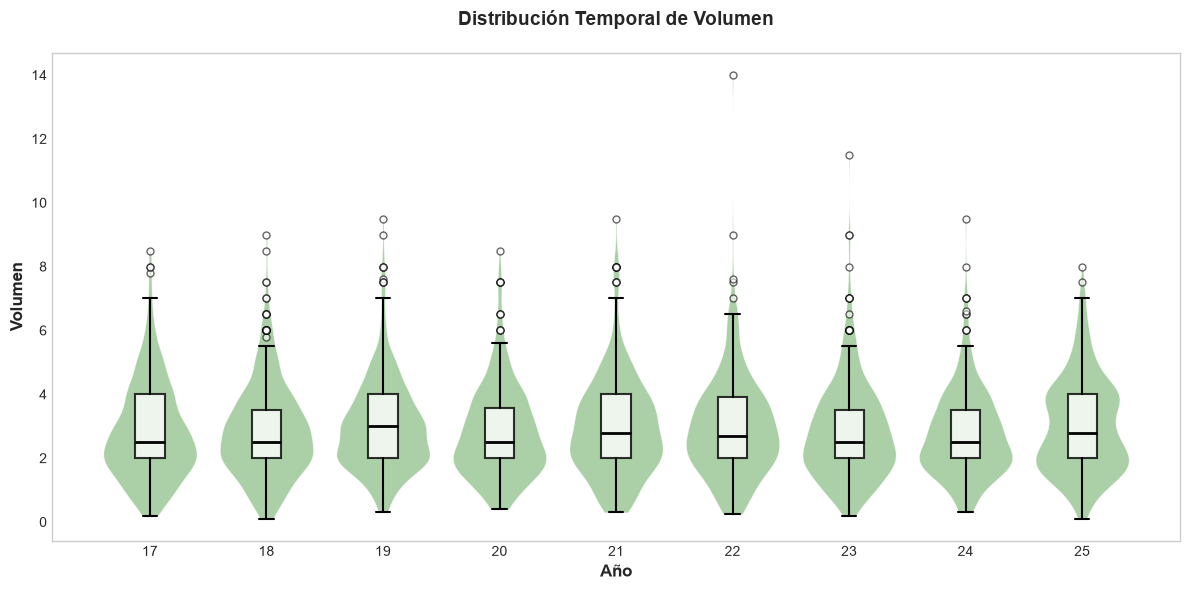

In [27]:
graficas_numericas(df, 'volumen_ml', 'Volumen', color='#59A14F')

**Resumen General**

La tabla muestra los estadísticos descriptivos del volumen del eyaculado (en ml) para cada año del período 2017-2025. Se observa que el volumen promedio se mantiene relativamente estable alrededor de 2.75-3.00 ml en todos los años, sin una tendencia clara de aumento o disminución. La mediana varía entre 2.50 y 3.00 ml, y la distribución muestra una variabilidad moderada con presencia de valores atípicos en algunos años.

**Análisis de Medidas de Tendencia Central**

| Año | Media | Mediana (Q2) | Diferencia | Interpretación |
|-----|-------|--------------|------------|----------------|
| 2017 | 2.82 | 2.50 | +0.32 | Sesgo positivo (media > mediana) |
| 2018 | 2.85 | 2.50 | +0.35 | Sesgo positivo |
| 2019 | 3.00 | 3.00 | 0.00 | Distribución simétrica |
| 2020 | 2.79 | 2.50 | +0.29 | Sesgo positivo |
| 2021 | 2.94 | 2.80 | +0.14 | Sesgo positivo leve |
| 2022 | 2.94 | 2.70 | +0.24 | Sesgo positivo |
| 2023 | 2.83 | 2.50 | +0.33 | Sesgo positivo |
| 2024 | 2.75 | 2.50 | +0.25 | Sesgo positivo |
| 2025 | 3.00 | 2.80 | +0.20 | Sesgo positivo leve |

- La media varía entre 2.75 y 3.00 ml, sin una tendencia clara
- La mediana varía entre 2.50 y 3.00 ml, con valores ligeramente superiores en años recientes
- En la mayoría de los años, la media es ligeramente superior a la mediana, indicando sesgo positivo
- 2019 y 2025 presentan los valores más altos (media = 3.0 ml)

**Evolución del Volumen Promedio**

| Período | Media | Mediana | Tendencia |
|---------|-------|---------|-----------|
| 2017-2018 | 2.82-2.85 | 2.50 | Estable |
| 2019 | 3.00 | 3.00 | Pico |
| 2020-2021 | 2.79-2.94 | 2.50-2.80 | Estable |
| 2022-2023 | 2.83-2.94 | 2.50-2.70 | Estable |
| 2024 | 2.75 | 2.50 | Valor más bajo |
| 2025 | 3.00 | 2.80 | Valor más alto |

- No hay una tendencia clara de aumento o disminución a lo largo del tiempo
- 2019 y 2025 muestran los valores más altos (~3.0 ml)
- 2024 presenta el valor más bajo (2.75 ml)

**Análisis de Dispersión**

| Año | Std | IQR | CV (%) | Interpretación |
|-----|-----|-----|--------|----------------|
| 2017 | 1.51 | 2.00 | 53.42 | Variabilidad alta |
| 2018 | 1.46 | 1.50 | 51.29 | Variabilidad alta |
| 2019 | 1.43 | 2.00 | 47.51 | Variabilidad moderada-alta |
| 2020 | 1.41 | 1.58 | 50.69 | Variabilidad alta |
| 2021 | 1.54 | 2.00 | 52.47 | Variabilidad alta |
| 2022 | 1.57 | 1.92 | 53.35 | Variabilidad alta |
| 2023 | 1.53 | 1.50 | 53.99 | Variabilidad alta |
| 2024 | 1.37 | 1.50 | 49.85 | Variabilidad moderada-alta |
| 2025 | 1.48 | 2.00 | 49.42 | Variabilidad moderada-alta |

- El coeficiente de variación (CV) es alto (47.5-54.0%), indicando una variabilidad relativa considerable
- El IQR es de 1.5-2.0 ml, mostrando que el 50% central de los pacientes tiene volúmenes entre 2.0 y 3.5-4.0 ml
- La variabilidad es consistente en todos los años
- 2017, 2022 y 2023 presentan la mayor variabilidad (CV ~53-54%)

**Análisis de Valores Extremos**

| Año | Mínimo | Máximo | Rango | Interpretación |
|-----|--------|--------|-------|----------------|
| 2017 | 0.20 | 8.50 | 8.30 | Rango amplio |
| 2018 | 0.10 | 9.00 | 8.90 | Rango amplio |
| 2019 | 0.30 | 9.50 | 9.20 | Rango amplio |
| 2020 | 0.40 | 8.50 | 8.10 | Rango amplio |
| 2021 | 0.30 | 9.50 | 9.20 | Rango amplio |
| 2022 | 0.25 | 14.00 | 13.75 | Rango muy amplio (outlier extremo) |
| 2023 | 0.20 | 11.50 | 11.30 | Rango muy amplio |
| 2024 | 0.30 | 9.50 | 9.20 | Rango amplio |
| 2025 | 0.10 | 8.00 | 7.90 | Rango amplio |

- 2022 presenta el valor máximo más alto (14.0 ml), un outlier extremo
- 2023 también presenta un valor máximo alto (11.5 ml)
- El valor mínimo es muy bajo en todos los años (0.10-0.40 ml)

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | 0.87 | 0.81 | Sesgo positivo moderado |
| 2018 | 0.82 | 1.01 | Sesgo positivo moderado |
| 2019 | 1.13 | 2.25 | Sesgo positivo notable |
| 2020 | 0.98 | 1.33 | Sesgo positivo moderado |
| 2021 | 0.90 | 1.50 | Sesgo positivo moderado |
| 2022 | 1.48 | 6.57 | Sesgo extremo (outlier de 14 ml) |
| 2023 | 1.35 | 3.68 | Sesgo positivo notable |
| 2024 | 1.08 | 2.24 | Sesgo positivo moderado |
| 2025 | 0.61 | 0.05 | Sesgo positivo leve, distribución normal |

- Todos los años presentan sesgo positivo (skew > 0), indicando una cola hacia valores altos
- 2022 muestra el sesgo más extremo (1.48) debido al outlier de 14 ml
- 2025 presenta la distribución más cercana a la normalidad
- La curtosis es positiva en la mayoría de los años, indicando distribuciones más apuntadas

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Volumen Seminal por Año**

Para evaluar si existe relación entre el año de estudio y el volumen del eyaculado, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los volúmenes medios entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en el volumen seminal de los pacientes.

In [28]:
funcion_numericas(df, 'volumen_ml', 'Volumen')


=== Volumen ===

Prueba de Normalidad Global
- n = 3384, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 367, p-value = 2.28e-10 → No Normal
- Año 18: n = 443, p-value = 2.12e-10 → No Normal
- Año 19: n = 450, p-value = <1e-10 → No Normal
- Año 20: n = 310, p-value = 3.79e-10 → No Normal
- Año 21: n = 378, p-value = 2.23e-10 → No Normal
- Año 22: n = 370, p-value = <1e-10 → No Normal
- Año 23: n = 364, p-value = <1e-10 → No Normal
- Año 24: n = 336, p-value = <1e-10 → No Normal
- Año 25: n = 366, p-value = 1.50e-08 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.31, p-value = 2.36e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 13.36, p-value = 1.00e-01
- No hay diferencias significativas (p >= 0.05)


**Resumen General**

El análisis estadístico revela que no existen diferencias significativas en el volumen seminal entre los años de estudio (p = 0.100). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados. El resultado no significativo indica que el volumen del eyaculado se ha mantenido estable a lo largo del tiempo.

**Prueba de Normalidad**

- Todos los años presentan una distribución de volumen que no sigue una distribución normal (p < 0.01 en todos los casos)
- Esto se debe a la presencia de sesgo positivo (colas hacia valores altos) y outliers en algunos años
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p = 0.236)
- Las varianzas de volumen son similares entre los años
- Sin embargo, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- No hay evidencia de que el volumen seminal varíe entre los años
- El estadístico H = 13.36 indica una diferencia pequeña
- La probabilidad de observar estas diferencias por azar es del 10.0%, muy por encima del umbral del 5%

### **pH**

#### **Análisis Descriptivo y Visual de la Distribución del pH Seminal a lo Largo del Tiempo**

Para caracterizar la evolución temporal del pH de las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en el pH seminal de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de pH según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,364,7.85,0.25,6.80,7.80,7.90,8.00,8.50,0.20,3.24,-0.84,1.83
18,408,7.91,0.26,6.50,7.80,7.90,8.00,9.00,0.20,3.24,-0.62,5.95
19,402,7.89,0.25,6.50,7.80,7.90,8.00,8.50,0.20,3.22,-1.26,5.04
20,274,7.86,0.29,6.50,7.70,7.90,8.10,8.50,0.40,3.68,-1.38,4.48
21,321,7.88,0.26,6.50,7.70,7.90,8.00,9.00,0.30,3.33,-0.53,4.77
22,300,7.87,0.26,6.80,7.80,7.90,8.00,8.90,0.20,3.25,-0.75,3.39
23,274,7.90,0.22,6.80,7.80,7.90,8.00,8.50,0.20,2.75,-0.43,2.73
24,266,7.85,0.25,6.50,7.70,7.90,8.00,8.70,0.30,3.17,-1.01,4.66
25,287,7.92,0.27,6.70,7.80,7.90,8.10,9.00,0.30,3.40,-0.61,3.54


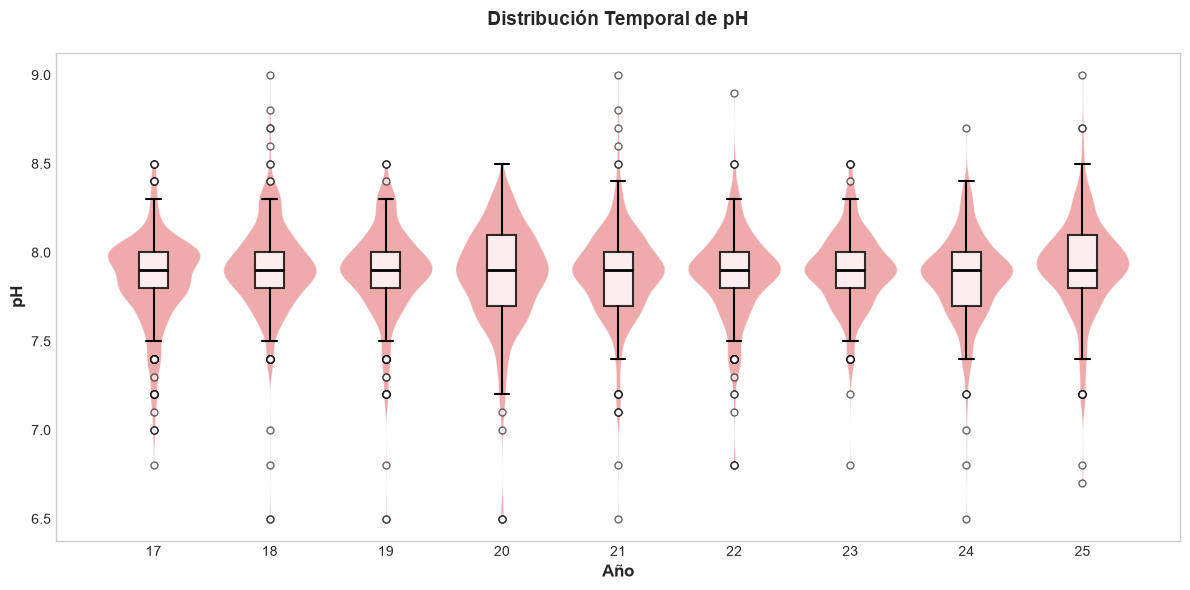

In [29]:
graficas_numericas(df,'ph', 'pH', color='#E15759')

**Resumen General**

La tabla muestra los estadísticos descriptivos del pH de las muestras seminales para cada año del período 2017-2025. Se observa que el pH se mantiene estable alrededor de 7.85-7.92 en todos los años. La variabilidad es muy baja, indicando que el pH es un parámetro muy estable.

**Análisis de Medidas de Tendencia Central**

| Año | Media | Mediana (Q2) | Diferencia | Interpretación |
|-----|-------|--------------|------------|----------------|
| 2017 | 7.85 | 7.90 | -0.05 | Sesgo negativo (media < mediana) |
| 2018 | 7.91 | 7.90 | +0.01 | Distribución prácticamente simétrica |
| 2019 | 7.89 | 7.90 | -0.01 | Distribución prácticamente simétrica |
| 2020 | 7.86 | 7.90 | -0.04 | Sesgo negativo leve |
| 2021 | 7.88 | 7.90 | -0.02 | Distribución prácticamente simétrica |
| 2022 | 7.87 | 7.90 | -0.03 | Sesgo negativo leve |
| 2023 | 7.90 | 7.90 | 0.00 | Distribución perfectamente simétrica |
| 2024 | 7.85 | 7.90 | -0.05 | Sesgo negativo leve |
| 2025 | 7.92 | 7.90 | +0.02 | Distribución prácticamente simétrica |

- La mediana es 7.90 en todos los años, indicando una estabilidad perfecta
- La media varía entre 7.85 y 7.92, una variación muy pequeña (0.07 unidades de pH)
- 2018 y 2025 presentan las medias más altas (7.91-7.92)
- 2017 y 2024 presentan la media más baja (7.85)

**Evolución del pH Promedio**

| Período | Media | Mediana | Tendencia |
|---------|-------|---------|-----------|
| 2017 | 7.85 | 7.90 | Valor más bajo  |
| 2018-2021 | 7.86-7.91 | 7.90 | Estable |
| 2022-2024 | 7.85-7.90 | 7.90 | Estable |
| 2025 | 7.92 | 7.90 | Valor más alto |

- El pH es extremadamente estable a lo largo de todo el período
- La variación es clínicamente irrelevante (0.05 unidades)
- No hay una tendencia clara de aumento o disminución
- La estabilidad del pH sugiere que el equilibrio ácido-base de las muestras se ha mantenido constante

**Análisis de Dispersión**

| Año | Std | IQR | CV (%) | Interpretación |
|-----|-----|-----|--------|----------------|
| 2017 | 0.25 | 0.20 | 3.24 | Variabilidad muy baja |
| 2018 | 0.26 | 0.20 | 3.24 | Variabilidad muy baja |
| 2019 | 0.25 | 0.20 | 3.22 | Variabilidad muy baja |
| 2020 | 0.29 | 0.40 | 3.68 | Variabilidad muy baja |
| 2021 | 0.26 | 0.30 | 3.33 | Variabilidad muy baja |
| 2022 | 0.26 | 0.20 | 3.25 | Variabilidad moderada |
| 2023 | 0.22 | 0.20 | 2.75 | Variabilidad más baja |
| 2024 | 0.25 | 0.30 | 3.17 | Variabilidad muy baja |
| 2025 | 0.27 | 0.30 | 3.40 | Variabilidad muy baja |

- El IQR es de solo 0.20-0.40 unidades de pH, indicando una concentración muy estrecha de los datos
- El CV es muy bajo (2.75-3.68%), confirmando la baja variabilidad
- 2023 presenta la menor variabilidad (CV 2.75%)
- 2020 presenta la mayor variabilidad (CV 3.68%), aunque sigue siendo clínicamente irrelevante

**Análisis de Valores Extremos (Outliers)**

| Año | Mínimo | Máximo | Rango | Interpretación |
|-----|--------|--------|-------|----------------|
| 2017 | 6.80 | 8.50 | 1.70 | Rango normal |
| 2018 | 6.50 | 9.00 | 2.50 | Rango normal |
| 2019 | 6.50 | 8.50 | 2.00 | Rango normal |
| 2020 | 6.50 | 8.50 | 2.00 | Rango normal |
| 2021 | 6.50 | 9.00 | 2.50 | Rango normal |
| 2022 | 6.80 | 8.90 | 2.10 | Rango normal |
| 2023 | 6.80 | 8.50 | 1.70 | Rango normal |
| 2024 | 6.50 | 8.70 | 2.20 | Rango normal |
| 2025 | 6.70 | 9.00 | 2.30 | Rango normal |

- Los valores mínimos (6.5-6.8) son consistentes en todos los años
- Los valores máximos (8.5-9.0) son consistentes en todos los años

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | -0.84 | 1.83 | Sesgo negativo leve |
| 2018 | -0.62 | 5.95 | Sesgo negativo leve |
| 2019 | -1.26 | 5.04 | Sesgo negativo moderado |
| 2020 | -1.38 | 4.48 | Sesgo negativo moderado |
| 2021 | -0.53 | 4.77 | Sesgo negativo leve |
| 2022 | -0.75 | 3.39 | Sesgo negativo leve |
| 2023 | -0.43 | 2.73 | Sesgo negativo leve, distribución normal |
| 2024 | -1.01 | 4.66 | Sesgo negativo moderado |
| 2025 | -0.61 | 3.54 | Sesgo negativo leve |

- Todos los años presentan sesgo negativo (skew < 0), indicando cola hacia valores bajos
- 2023 presenta la distribución más cercana a la normalidad
- La curtosis es positiva en todos los años, indicando distribuciones apuntadas

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del pH Seminal por Año**

Para evaluar si existe relación entre el año de estudio y el pH de las muestras seminales, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los pH medios entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en el pH seminal de los pacientes.

In [30]:
funcion_numericas(df, 'ph', 'pH')


=== pH ===

Prueba de Normalidad Global
- n = 2896, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 364, p-value = <1e-10 → No Normal
- Año 18: n = 408, p-value = <1e-10 → No Normal
- Año 19: n = 402, p-value = <1e-10 → No Normal
- Año 20: n = 274, p-value = <1e-10 → No Normal
- Año 21: n = 321, p-value = <1e-10 → No Normal
- Año 22: n = 300, p-value = <1e-10 → No Normal
- Año 23: n = 274, p-value = 5.45e-09 → No Normal
- Año 24: n = 266, p-value = <1e-10 → No Normal
- Año 25: n = 287, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.72, p-value = 8.96e-02

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 26.21, p-value = 9.67e-04
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     17   18   19   20   21

**Resumen General**

El análisis estadístico revela que existen diferencias significativas en el pH seminal entre los años de estudio (p = 0.00097). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados. Las pruebas post-hoc con corrección de Bonferroni identifican que las diferencias se concentran principalmente entre 2017 vs 2025 y 2024 vs 2025.

**Prueba de Normalidad**

- Todos los años presentan una distribución de pH que no sigue una distribución normal (p < 0.001 en todos los casos)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p = 8.96e-02)
- Las varianzas de pH son similares entre los años (CV 2.75-3.68%)
- Sin embargo, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- Existe evidencia sólida de que el pH varía entre los años (p < 0.001)
- El estadístico H = 26.21 indica una diferencia moderada
- La probabilidad de observar estas diferencias por azar es baja (0.096%)

**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value (Bonferroni) | pH Medio | Diferencia | Interpretación |
|-------------|---------------------|----------|------------|----------------|
| 2017 vs 2025 | 0.004 | 7.85 vs 7.92 | +0.07 | Diferencia significativa |
| 2024 vs 2025 | 0.003 | 7.85 vs 7.92 | +0.07 | Diferencia significativa |

### **Número Total de Espermatozoides Eyaculados**

#### **Análisis Descriptivo y Visual de la Distribución del Número Total de Espermatozoides por Eyaculado a lo Largo del Tiempo**

Para caracterizar la evolución temporal del número total de espermatozoides por eyaculado en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en el recuento total de espermatozoides de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Número Total de Espermatozoides Eyaculados según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,367,"96,064,087.19","99,251,200.64",0.00,"20,000,000.00","70,400,000.00","145,000,000.00","704,000,000.00","125,000,000.00",103.32,1.79,4.82
18,443,"124,262,618.51","131,463,130.34",0.00,"26,300,000.00","86,000,000.00","175,500,000.00","972,000,000.00","149,200,000.00",105.79,1.87,5.17
19,451,"126,628,736.14","128,933,155.39",0.00,"23,700,000.00","84,000,000.00","199,000,000.00","612,000,000.00","175,300,000.00",101.82,1.27,1.27
20,309,"115,808,317.15","130,268,585.70",0.00,"22,000,000.00","70,000,000.00","164,000,000.00","799,500,000.00","142,000,000.00",112.49,1.95,4.97
21,378,"144,475,211.64","149,551,793.40",0.00,"30,000,000.00","98,250,000.00","207,875,000.00","896,000,000.00","177,875,000.00",103.51,1.56,2.75
22,370,"133,987,621.62","149,746,425.78",0.00,"28,250,000.00","92,000,000.00","196,000,000.00","1,599,000,000.00","167,750,000.00",111.76,3.43,25.21
23,365,"125,262,575.34","128,600,673.47",0.00,"28,000,000.00","93,000,000.00","175,000,000.00","700,000,000.00","147,000,000.00",102.66,1.71,3.61
24,336,"132,354,032.74","125,106,837.73",0.00,"36,600,000.00","93,800,000.00","211,500,000.00","647,500,000.00","174,900,000.00",94.52,1.28,1.46
25,366,"156,012,909.84","159,267,460.89",0.00,"32,425,000.00","104,000,000.00","220,875,000.00","886,500,000.00","188,450,000.00",102.09,1.61,3.09


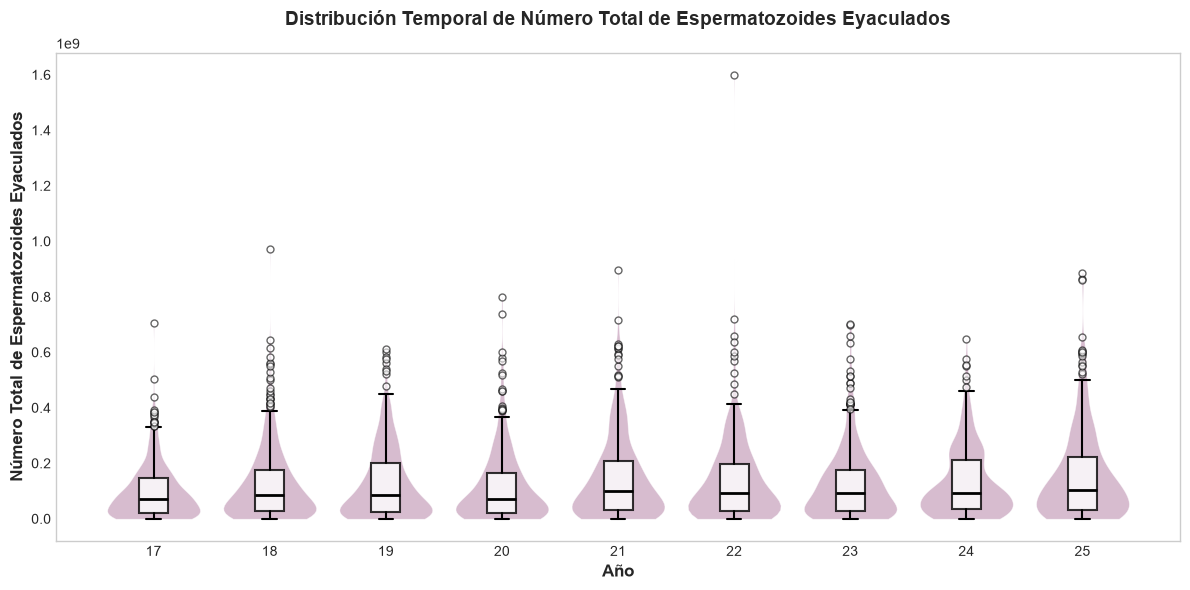

In [31]:
graficas_numericas(df,'espermatozoides_por_eyaculado', 'Número Total de Espermatozoides Eyaculados', color='#B07AA1')

**Resumen General**

La tabla muestra los estadísticos descriptivos del número total de espermatozoides por eyaculado para cada año del período 2017-2025. Se observa que el recuento total promedio varía entre 96 y 156 millones a lo largo de los años. Sin embargo, la variabilidad es extremadamente alta (CV 94.52-112.49%), indicando una gran heterogeneidad entre los pacientes. La presencia de valores extremos (hasta 1,599 millones en 2022) genera una distribución con fuerte sesgo positivo.

**Análisis de Medidas de Tendencia Central**

| Año | Media | Mediana (Q2) | Diferencia | Interpretación |
|-----|-------|--------------|------------|----------------|
| 2017 | 96.1M | 70.4M | +25.7M | Sesgo positivo fuerte |
| 2018 | 124.3M | 86.0M | +38.3M | Sesgo positivo fuerte |
| 2019 | 126.6M | 84.0M | +42.6M | Sesgo positivo fuerte |
| 2020 | 115.8M | 70.0M | +45.8M | Sesgo positivo fuerte |
| 2021 | 144.5M | 98.3M | +46.2M | Sesgo positivo fuerte |
| 2022 | 134.0M | 92.0M | +42.0M | Sesgo positivo fuerte |
| 2023 | 125.3M | 93.0M | +32.3M | Sesgo positivo fuerte |
| 2024 | 132.4M | 93.8M | +38.6M | Sesgo positivo fuerte |
| 2025 | 156.0M | 104.0M | +52.0M | Valor más alto |

- En todos los años, la media es considerablemente mayor que la mediana, indicando un fuerte sesgo positivo
- La mediana (valor central) varía entre 70.4M (2017) y 104.0M (2025)
- 2025 destaca como el año con mayor recuento total (media 156M, mediana 104M)
- 2017 presenta los valores más bajos (media 96M, mediana 70M)

**Evolución del Recuento Total de Espermatozoides**

| Período | Media (Millones) | Mediana (Millones) | Tendencia |
|---------|------------------|-------------------|-----------|
| 2017 | 96.1 | 70.4 | Valor más bajo |
| 2018-2020 | 115.8 - 126.6 | 70.0 - 86.0 | Aumento respecto a 2017 |
| 2021-2024 | 125.3 - 144.5 | 92.0 - 98.3 | Estable en nivel alto |
| 2025 | 156.0 | 104.0 | Pico máximo |

- Tendencia general de aumento, el recuento total ha aumentado desde 2017
- 2025 representa un punto máximo que podría ser atípico

**Análisis de Dispersión**

| Año | Std (Millones) | IQR (Millones) | CV (%) | Interpretación |
|-----|----------------|----------------|--------|----------------|
| 2017 | 99.3 | 125.0 | 103.32 | Variabilidad extremadamente alta |
| 2018 | 131.5 | 149.2 | 105.79 | Variabilidad extremadamente alta |
| 2019 | 128.9 | 175.3 | 101.82 | Variabilidad extremadamente alta |
| 2020 | 130.3 | 142.0 | 112.49 | Variabilidad extremadamente alta |
| 2021 | 149.6 | 177.9 | 103.51 | Variabilidad extremadamente alta |
| 2022 | 149.7 | 167.8 | 111.76 | Variabilidad extremadamente alta |
| 2023 | 128.6 | 147.0 | 102.66 | Variabilidad extremadamente alta |
| 2024 | 125.1 | 174.9 | 94.52 | Variabilidad extremadamente alta |
| 2025 | 159.3 | 188.5 | 102.09 | Variabilidad extremadamente alta |

- El coeficiente de variación (CV) es extremadamente alto (94.52-112.49%)
- La desviación estándar es mayor que la media en muchos años, indicando una distribución muy dispersa
- El IQR es muy amplio (125-188 millones), mostrando que el 50% central de los pacientes tiene una gran variabilidad
- 2024 presenta la menor variabilidad relativa (CV 94.52%)
- 2020 y 2022 presentan la mayor variabilidad (CV > 111%)

**Análisis de Valores Extremos**

| Año | Mínimo | Máximo (Millones) | Rango | Interpretación |
|-----|--------|-------------------|-------|----------------|
| 2017 | 0 | 704 | 704 | Rango muy amplio |
| 2018 | 0 | 972 | 972 | Rango muy amplio |
| 2019 | 0 | 612 | 612 | Rango muy amplio |
| 2020 | 0 | 800 | 800 | Rango muy amplio |
| 2021 | 0 | 896 | 896 | Rango muy amplio |
| 2022 | 0 | 1,599 | 1,599 | Outlier extremo |
| 2023 | 0 | 700 | 700 | Rango muy amplio |
| 2024 | 0 | 648 | 648 | Rango muy amplio |
| 2025 | 0 | 887 | 887 | Rango muy amplio |

- 2022 presenta un outlier extremo (1,599 millones) que afecta significativamente la media y la asimetría
- El valor mínimo es 0 en todos los años (casos de azoospermia)

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | 1.79 | 4.82 | Sesgo positivo fuerte |
| 2018 | 1.87 | 5.17 | Sesgo positivo fuerte |
| 2019 | 1.27 | 1.27 | Sesgo positivo moderado |
| 2020 | 1.95 | 4.97 | Sesgo positivo fuerte |
| 2021 | 1.56 | 2.75 | Sesgo positivo fuerte |
| 2022 | 3.43 | 25.21 | Sesgo extremo (outlier) |
| 2023 | 1.71 | 3.61 | Sesgo positivo fuerte |
| 2024 | 1.28 | 1.46 | Sesgo positivo moderado |
| 2025 | 1.61 | 3.09 | Sesgo positivo fuerte |

- Todos los años presentan sesgo positivo (skew > 0), indicando una cola larga hacia valores altos
- 2022 muestra el sesgo más extremo (3.43) debido al outlier de 1,599 millones
- 2019 y 2024 presentan las distribuciones más cercanas a la normalidad

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Recuento Total de Espermatozoides por Año**

Para evaluar si existe relación entre el año de estudio y el número total de espermatozoides por eyaculado, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los recuentos totales medios entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en el número total de espermatozoides por eyaculado de los pacientes.

In [32]:
funcion_numericas(df,'espermatozoides_por_eyaculado', 'Númeto Total de Espermatozoides Eyaculados')


=== Númeto Total de Espermatozoides Eyaculados ===

Prueba de Normalidad Global
- n = 3385, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 367, p-value = <1e-10 → No Normal
- Año 18: n = 443, p-value = <1e-10 → No Normal
- Año 19: n = 451, p-value = <1e-10 → No Normal
- Año 20: n = 309, p-value = <1e-10 → No Normal
- Año 21: n = 378, p-value = <1e-10 → No Normal
- Año 22: n = 370, p-value = <1e-10 → No Normal
- Año 23: n = 365, p-value = <1e-10 → No Normal
- Año 24: n = 336, p-value = <1e-10 → No Normal
- Año 25: n = 366, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 5.30, p-value = 1.27e-06

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 34.59, p-value = 3.17e-05
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (B

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en el número total de espermatozoides por eyaculado entre los años de estudio (p = 3.17e-05). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años y a la falta de homogeneidad de varianzas (p < 0.001). Las pruebas post-hoc con corrección de Bonferroni identifican que 2017 es el año que difiere de varios años posteriores (2021, 2022, 2024, 2025), y 2025 difiere de 2017 y 2020.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- Esto se debe a la presencia de azoospermia (valor 0) y outliers extremos (valores > 500M)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- Las varianzas son significativamente diferentes entre los años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- Existe evidencia muy sólida de que el recuento total varía entre los años (p < 0.001)
- El estadístico H = 34.59 indica una diferencia moderada-fuerte
- La probabilidad de observar estas diferencias por azar es extremadamente baja (0.00317%)

**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value (Bonferroni) | Media (Millones) | Diferencia | Interpretación |
|-------------|---------------------|------------------|------------|----------------|
| 2017 vs 2021 | 0.002 | 96.1 vs 144.5 | +48.4M | Diferencia muy significativa |
| 2017 vs 2022 | 0.040 | 96.1 vs 134.0 | +37.9M | Diferencia significativa |
| 2017 vs 2024 | 0.007 | 96.1 vs 132.4 | +36.3M | Diferencia significativa |
| 2017 vs 2025 | < 0.001 | 96.1 vs 156.0 | +59.9M | Diferencia muy significativa |
| 2020 vs 2025 | 0.014 | 115.8 vs 156.0 | +40.2M | Diferencia significativa |

### **Concentración de Espermatozoides por ml**

#### **Análisis Descriptivo y Visual de la Distribución de la Concentración Espermática por ml a lo Largo del Tiempo**

Para caracterizar la evolución temporal de la concentración de espermatozoides por mililitro en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en la concentración espermática de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Concentración de Espermatozoides por ml según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,367,"35,812,602.18","32,475,358.98",0.00,"9,500,000.00","29,000,000.00","51,000,000.00","190,000,000.00","41,500,000.00",90.68,1.15,1.38
18,443,"45,463,566.59","41,784,716.04",0.00,"12,000,000.00","32,400,000.00","68,000,000.00","238,000,000.00","56,000,000.00",91.91,1.16,1.17
19,451,"43,899,113.08","40,164,793.29",0.00,"9,200,000.00","33,000,000.00","70,500,000.00","181,000,000.00","61,300,000.00",91.49,0.93,0.30
20,309,"41,924,595.47","41,572,653.23",0.00,"9,600,000.00","31,000,000.00","61,000,000.00","280,000,000.00","51,400,000.00",99.16,1.69,4.63
21,378,"49,454,232.80","42,710,359.36",0.00,"16,250,000.00","40,000,000.00","77,750,000.00","220,000,000.00","61,500,000.00",86.36,1.01,0.76
22,370,"48,186,216.22","44,830,397.63",0.00,"13,000,000.00","40,000,000.00","74,500,000.00","293,000,000.00","61,500,000.00",93.04,1.59,4.21
23,365,"47,083,287.67","42,439,631.11",0.00,"12,000,000.00","38,000,000.00","71,000,000.00","210,000,000.00","59,000,000.00",90.14,1.16,1.28
24,336,"50,211,160.71","42,188,640.00",0.00,"17,750,000.00","41,000,000.00","75,250,000.00","214,000,000.00","57,500,000.00",84.02,1.03,0.85
25,366,"54,360,928.96","49,000,985.91",0.00,"14,000,000.00","42,000,000.00","82,000,000.00","300,400,000.00","68,000,000.00",90.14,1.25,1.96


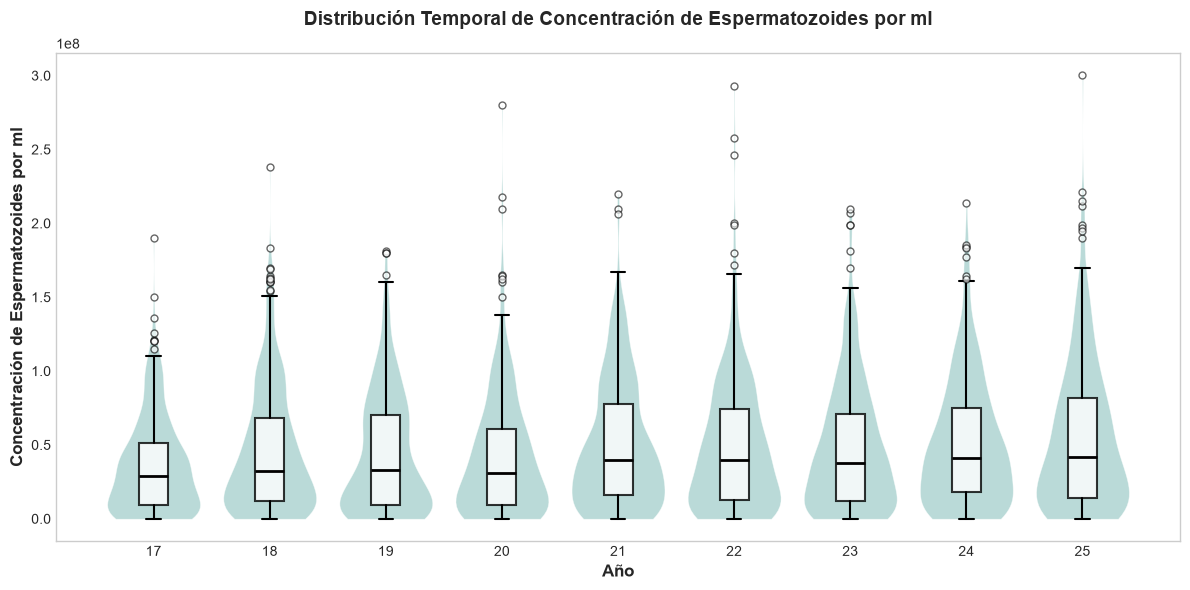

In [33]:
graficas_numericas(df, 'concentracion_por_ml', 'Concentración de Espermatozoides por ml', color='#76B7B2')

**Resumen General**

La tabla muestra los estadísticos descriptivos de la concentración de espermatozoides por mililitro para cada año del período 2017-2025. Se observa una tendencia general al aumento en la concentración media, que pasa de 35.8 M/ml en 2017 a 54.4 M/ml en 2025, con una variabilidad alta y consistente (CV 84.02-99.16%). La mediana también muestra un aumento de 29 M/ml en 2017 a 42 M/ml en 2025, confirmando una mejora en el valor central de la distribución.

**Análisis de Medidas de Tendencia Central**

| Año | Media (M/ml) | Mediana (M/ml) | Diferencia | Interpretación |
|-----|--------------|----------------|------------|----------------|
| 2017 | 35.8 | 29.0 | +6.8 | Sesgo positivo |
| 2018 | 45.5 | 32.4 | +13.1 | Sesgo positivo |
| 2019 | 43.9 | 33.0 | +10.9 | Sesgo positivo |
| 2020 | 41.9 | 31.0 | +10.9 | Sesgo positivo |
| 2021 | 49.5 | 40.0 | +9.5 | Sesgo positivo |
| 2022 | 48.2 | 40.0 | +8.2 | Sesgo positivo |
| 2023 | 47.1 | 38.0 | +9.1 | Sesgo positivo |
| 2024 | 50.2 | 41.0 | +9.2 | Sesgo positivo |
| 2025 | 54.4 | 42.0 | +12.4 | Valor más alto |

- En todos los años, la media es mayor que la mediana, indicando sesgo positivo
- La mediana ha aumentado de 29M (2017) a 42M (2025), un incremento del 45%
- La media ha aumentado de 35.8M (2017) a 54.4M (2025), un incremento del 52%
- 2025 destaca como el año con mayor concentración (media 54.4M, mediana 42M)

**Evolución de la Concentración Promedio**

| Período | Media (M/ml) | Mediana (M/ml) | Tendencia |
|---------|--------------|----------------|-----------|
| 2017 | 35.8 | 29.0 | Valor más bajo |
| 2018-2020 | 41.9 - 45.5 | 31.0 - 33.0 | Aumento respecto a 2017 |
| 2021-2024 | 47.1 - 50.2 | 38.0 - 41.0 | Nivel alto y estable |
| 2025 | 54.4 | 42.0 | Pico máximo |

- Tendencia general de aumento desde 2017
- Incremento total +18.6 M/ml (52%) en la media entre 2017 y 2025
- Incremento en la mediana +13 M/ml (45%) en el valor central
- Periodo 2021-2024: Concentración estable en niveles altos (~47-50 M/ml)
- 2025 presenta pico máximo que podría ser atípico

**Análisis de Dispersión**

| Año | Std (M/ml) | IQR (M/ml) | CV (%) | Interpretación |
|-----|------------|------------|--------|----------------|
| 2017 | 32.5 | 41.5 | 90.68 | Variabilidad muy alta |
| 2018 | 41.8 | 56.0 | 91.91 | Variabilidad muy alta |
| 2019 | 40.2 | 61.3 | 91.49 | Variabilidad muy alta |
| 2020 | 41.6 | 51.4 | 99.16 | Variabilidad más alta |
| 2021 | 42.7 | 61.5 | 86.36 | Variabilidad alta |
| 2022 | 44.8 | 61.5 | 93.04 | Variabilidad muy alta |
| 2023 | 42.4 | 59.0 | 90.14 | Variabilidad muy alta |
| 2024 | 42.2 | 57.5 | 84.02 | Variabilidad más baja |
| 2025 | 49.0 | 68.0 | 90.14 | Variabilidad muy alta |

- El CV es muy alto (84.02-99.16%), indicando una variabilidad relativa considerable
- El IQR es amplio (41-68 M/ml), mostrando que el 50% central de los pacientes tiene gran variabilidad
- 2020 presenta la mayor variabilidad (CV 99.16%)
- 2024 presenta la menor variabilidad (CV 84.02%)
- La variabilidad es consistente a lo largo de los años

**Análisis de Valores Extremos**

| Año | Mínimo | Máximo (M/ml) | Rango | Interpretación |
|-----|--------|---------------|-------|----------------|
| 2017 | 0 | 190 | 190 | Rango amplio |
| 2018 | 0 | 238 | 238 | Rango amplio |
| 2019 | 0 | 181 | 181 | Rango amplio |
| 2020 | 0 | 280 | 280 | Rango amplio |
| 2021 | 0 | 220 | 220 | Rango amplio |
| 2022 | 0 | 293 | 293 | Rango amplio |
| 2023 | 0 | 210 | 210 | Rango amplio |
| 2024 | 0 | 214 | 214 | Rango amplio |
| 2025 | 0 | 300 | 300 | Rango más amplio |

- El valor mínimo es 0 en todos los años (casos de azoospermia)
- 2025 presenta el valor máximo más alto (300 M/ml)
- Los valores máximos son muy superiores a la media, confirmando la presencia de outliers

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | 1.15 | 1.38 | Sesgo positivo moderado |
| 2018 | 1.16 | 1.17 | Sesgo positivo moderado |
| 2019 | 0.93 | 0.30 | Sesgo positivo moderado |
| 2020 | 1.69 | 4.63 | Sesgo positivo fuerte |
| 2021 | 1.01 | 0.76 | Sesgo positivo moderado |
| 2022 | 1.59 | 4.21 | Sesgo positivo fuerte |
| 2023 | 1.16 | 1.28 | Sesgo positivo moderado |
| 2024 | 1.03 | 0.85 | Sesgo positivo moderado |
| 2025 | 1.25 | 1.96 | Sesgo positivo moderado |

- Todos los años presentan sesgo positivo (skew > 0)
- 2020 y 2022 muestran el sesgo más fuerte (skew > 1.6)
- La curtosis es positiva en la mayoría de los años, indicando distribuciones apuntadas

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación de la Concentración Espermática por Año**

Para evaluar si existe relación entre el año de estudio y la concentración de espermatozoides por mililitro, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las concentraciones medias entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en la concentración espermática de los pacientes.

In [34]:
funcion_numericas(df, 'concentracion_por_ml', 'Concentración de Espermatozoides por ml')


=== Concentración de Espermatozoides por ml ===

Prueba de Normalidad Global
- n = 3385, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 367, p-value = <1e-10 → No Normal
- Año 18: n = 443, p-value = <1e-10 → No Normal
- Año 19: n = 451, p-value = <1e-10 → No Normal
- Año 20: n = 309, p-value = <1e-10 → No Normal
- Año 21: n = 378, p-value = <1e-10 → No Normal
- Año 22: n = 370, p-value = <1e-10 → No Normal
- Año 23: n = 365, p-value = <1e-10 → No Normal
- Año 24: n = 336, p-value = <1e-10 → No Normal
- Año 25: n = 366, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 4.85, p-value = 5.82e-06

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 38.13, p-value = 7.13e-06
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonf

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en la concentración de espermatozoides por mililitro entre los años de estudio (p = 7.13e-06). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años y a la falta de homogeneidad de varianzas (p < 0.001). Las pruebas post-hoc con corrección de Bonferroni identifican que 2017 es el año que difiere de varios años posteriores (2021, 2022, 2023, 2024, 2025), y 2025 difiere de 2017 y 2020.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- Esto se debe a la presencia de azoospermia (valor 0) y outliers (valores > 200M/ml)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- Las varianzas son significativamente diferentes entre los años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- Existe evidencia muy sólida de que la concentración varía entre los años (p < 0.001)
- El estadístico H = 38.13 indica una diferencia moderada-fuerte
- La probabilidad de observar estas diferencias por azar es extremadamente baja (0.000713%)

**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value (Bonferroni) | Media (M/ml) | Diferencia | Interpretación |
|-------------|---------------------|--------------|------------|----------------|
| 2017 vs 2021 | 0.002 | 35.8 vs 49.5 | +13.7M | Diferencia muy significativa |
| 2017 vs 2022 | 0.025 | 35.8 vs 48.2 | +12.4M | Diferencia significativa |
| 2017 vs 2023 | 0.049 | 35.8 vs 47.1 | +11.3M | Diferencia significativa |
| 2017 vs 2024 | < 0.001 | 35.8 vs 50.2 | +14.4M | Diferencia muy significativa |
| 2017 vs 2025 | < 0.001 | 35.8 vs 54.4 | +18.6M | Diferencia muy significativa |
| 2020 vs 2025 | 0.027 | 41.9 vs 54.4 | +12.5M | Diferencia significativa |

### **Test de Eosina**

#### **Análisis Descriptivo y Visual de la Distribución del Test de Eosina (Viabilidad Espermática) a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de espermatozoides viables evaluado mediante el test de eosina en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en la viabilidad espermática de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Test de Eosina según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,356,68.78,21.68,0.00,65.00,75.00,81.00,98.00,16.00,31.52,-2.03,3.80
18,405,72.98,22.70,0.00,66.00,79.00,89.00,98.00,23.00,31.10,-1.78,3.15
19,384,70.65,25.89,0.00,65.00,80.00,86.00,98.00,21.00,36.64,-1.74,2.19
20,257,70.32,24.86,0.00,65.00,79.00,87.00,97.00,22.00,35.36,-1.73,2.34
21,315,71.05,23.71,0.00,65.00,79.00,86.00,96.00,21.00,33.37,-1.69,2.37
22,292,71.99,24.01,0.00,68.75,80.00,86.00,98.00,17.25,33.36,-2.03,3.45
23,269,73.58,22.37,0.00,72.00,80.00,86.00,98.00,14.00,30.41,-2.18,4.33
24,257,71.26,22.24,0.00,70.00,80.00,84.00,96.00,14.00,31.21,-1.94,3.33
25,280,65.49,23.66,0.00,57.00,73.00,81.00,97.00,24.00,36.12,-1.42,1.45


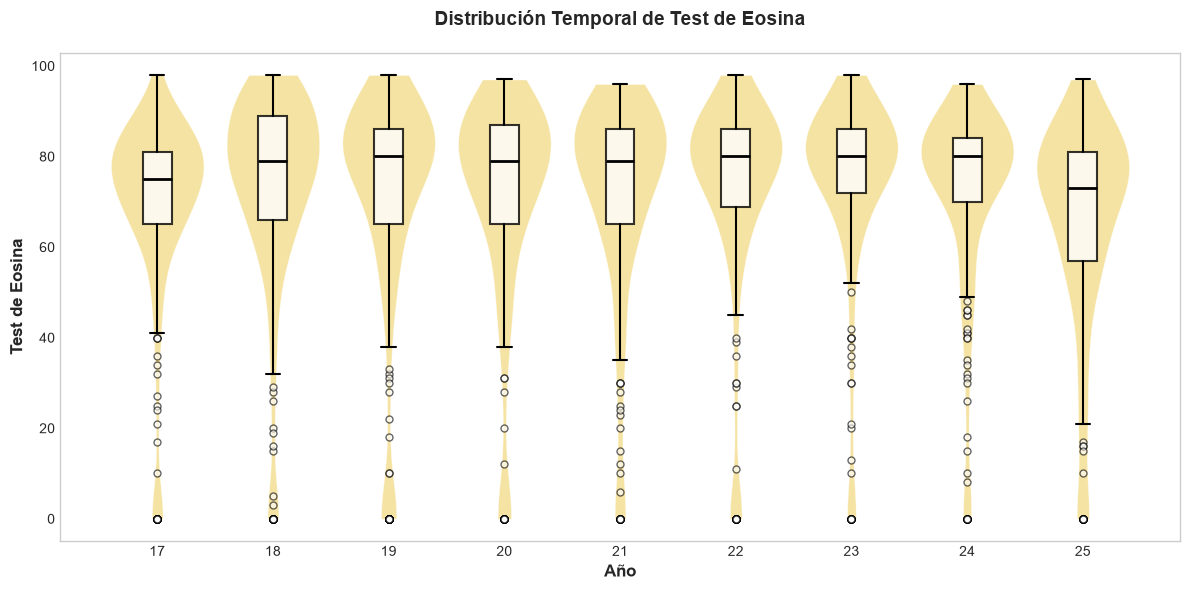

In [35]:
graficas_numericas(df,'test_eosina_pct', 'Test de Eosina', color='#EDC948')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de espermatozoides viables (test de eosina) para cada año del período 2017-2025. Se observa que la viabilidad espermática se mantiene estable alrededor del 68.78-73.58% durante el período estudiado. La variabilidad es moderada (CV 30.41-36.64%) y la distribución presenta un fuerte sesgo negativo, indicando que la mayoría de los pacientes tienen viabilidades altas, con algunos casos de viabilidad muy baja (0%).

**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 68.78 | 75.0 | -6.22 | Sesgo negativo (media < mediana) |
| 2018 | 72.98 | 79.0 | -6.02 | Sesgo negativo |
| 2019 | 70.65 | 80.0 | -9.35 | Sesgo negativo |
| 2020 | 70.32 | 79.0 | -8.68 | Sesgo negativo |
| 2021 | 71.05 | 79.0 | -7.95 | Sesgo negativo |
| 2022 | 71.99 | 80.0 | -8.01 | Sesgo negativo |
| 2023 | 73.58 | 80.0 | -6.42 | Valor más alto |
| 2024 | 71.26 | 80.0 | -8.74 | Sesgo negativo |
| 2025 | 65.49 | 73.0 | -7.51 | Valor más bajo |

- En todos los años, la media es considerablemente menor que la mediana, indicando un fuerte sesgo negativo
- La mediana (valor central) varía entre 73% (2025) y 80% en varios años
- 2023 destaca como el año con mayor viabilidad (media 73.58%, mediana 80%)
- 2025 presenta el valor más bajo (media 65.49%, mediana 73%), una caída notable respecto a años anteriores

**Evolución de la Viabilidad Promedio**

| Período | Media (%) | Mediana (%) | Tendencia |
|---------|-----------|-------------|-----------|
| 2017 | 68.78 | 75.0 | Valor bajo |
| 2018-2024 | 70.32 - 73.58 | 79.0 - 80.0 | Estable en nivel alto |
| 2025 | 65.49 | 73.0 | Caída significativa |

- Tendencia general estable desde 2018 hasta 2024
- Caída significativa en 2025 (65.49%), una disminución de 6 puntos porcentuales
- 2023 representa el mejor año (73.58%)

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 21.68 | 16.0 | 31.52 | Variabilidad moderada |
| 2018 | 22.70 | 23.0 | 31.10 | Variabilidad moderada |
| 2019 | 25.89 | 21.0 | 36.64 | Variabilidad más alta |
| 2020 | 24.86 | 22.0 | 35.36 | Variabilidad alta |
| 2021 | 23.71 | 21.0 | 33.37 | Variabilidad moderada |
| 2022 | 24.01 | 17.3 | 33.36 | Variabilidad moderada |
| 2023 | 22.37 | 14.0 | 30.41 | Variabilidad más baja |
| 2024 | 22.24 | 14.0 | 31.21 | Variabilidad moderada |
| 2025 | 23.66 | 24.0 | 36.12 | Variabilidad alta |

- El CV varía entre 30.41% y 36.64%, indicando una variabilidad moderada-alta
- 2023 presenta la menor variabilidad (CV 30.41%, IQR 14%)
- 2019 y 2025 presentan la mayor variabilidad (CV > 36%)
- El IQR es amplio (14-24 puntos porcentuales), mostrando diversidad en la viabilidad

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 98 | 98 | Rango muy amplio |
| 2018 | 0 | 98 | 98 | Rango muy amplio |
| 2019 | 0 | 98 | 98 | Rango muy amplio |
| 2020 | 0 | 97 | 97 | Rango muy amplio |
| 2021 | 0 | 96 | 96 | Rango muy amplio |
| 2022 | 0 | 98 | 98 | Rango muy amplio |
| 2023 | 0 | 98 | 98 | Rango muy amplio |
| 2024 | 0 | 96 | 96 | Rango muy amplio |
| 2025 | 0 | 97 | 97 | Rango muy amplio |

- El valor mínimo es 0% en todos los años (casos sin espermatozoides viables)
- El valor máximo es 96-98% en todos los años, indicando que algunos pacientes tienen viabilidad casi perfecta
- El rango es muy amplio (96-98 puntos porcentuales) en todos los años

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | -2.03 | 3.80 | Sesgo negativo fuerte |
| 2018 | -1.78 | 3.15 | Sesgo negativo fuerte |
| 2019 | -1.74 | 2.19 | Sesgo negativo fuerte |
| 2020 | -1.73 | 2.34 | Sesgo negativo fuerte |
| 2021 | -1.69 | 2.37 | Sesgo negativo fuerte |
| 2022 | -2.03 | 3.45 | Sesgo negativo fuerte |
| 2023 | -2.18 | 4.33 | Sesgo negativo más fuerte |
| 2024 | -1.94 | 3.33 | Sesgo negativo fuerte |
| 2025 | -1.42 | 1.45 | Sesgo negativo moderado |

- Todos los años presentan sesgo negativo (skew < 0), indicando una cola larga hacia valores bajos
- 2023 muestra el sesgo más negativo (-2.18) y la mayor curtosis (4.33)
- 2025 presenta el sesgo menos negativo (-1.42), indicando una distribución ligeramente más simétrica
- La mayoría de los pacientes tienen viabilidades altas, con unos pocos casos con viabilidad muy baja

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación de la Viabilidad Espermática (Test de Eosina) por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de espermatozoides viables evaluado mediante el test de eosina, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las viabilidades medias entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en la viabilidad espermática de los pacientes.

In [36]:
funcion_numericas(df,'test_eosina_pct', 'Test de Eosina')


=== Test de Eosina ===

Prueba de Normalidad Global
- n = 2815, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 356, p-value = <1e-10 → No Normal
- Año 18: n = 405, p-value = <1e-10 → No Normal
- Año 19: n = 384, p-value = <1e-10 → No Normal
- Año 20: n = 257, p-value = <1e-10 → No Normal
- Año 21: n = 315, p-value = <1e-10 → No Normal
- Año 22: n = 292, p-value = <1e-10 → No Normal
- Año 23: n = 269, p-value = <1e-10 → No Normal
- Año 24: n = 257, p-value = <1e-10 → No Normal
- Año 25: n = 280, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.51, p-value = 1.48e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 66.14, p-value = <1e-10
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     17   18   19  

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en la viabilidad espermática entre los años de estudio (p < 1e-10). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años. Las pruebas post-hoc con corrección de Bonferroni identifican un patrón claro de diferencias entre los años, con dos años que se destacan como atípicos: 2017 (baja viabilidad) y 2025 (baja viabilidad). Los años 2018-2024 forman un grupo con viabilidad significativamente mayor.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- Esto se debe al fuerte sesgo negativo (mayoría de pacientes con viabilidad alta, algunos con viabilidad 0%)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p = 0.148)
- Las varianzas son similares entre los años (CV 30.41-36.64%)
- Sin embargo, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- Existe evidencia abrumadora de que la viabilidad varía entre los años (p < 0.001)
- El estadístico H = 66.14 indica una diferencia fuerte
- La probabilidad de observar estas diferencias por azar es prácticamente nula

**Año 2017 vs Años Posteriores (excepto 2025)**

| Par de Años | p-value | Media 2017 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2018 | < 0.001 | 68.78 | 72.98 | +4.2 |
| 2017 vs 2019 | < 0.001 | 68.78 | 70.65 | +1.87 |
| 2017 vs 2021 | 0.016 | 68.78 | 71.05 | +2.27 |
| 2017 vs 2022 | 0.002 | 68.78 | 71.99 | +3.21 |
| 2017 vs 2023 | < 0.001 | 68.78 | 73.58 | +4.8 |

**Año 2025 vs Años 2018-2024:**

| Par de Años | p-value | Media 2025 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2018 vs 2025 | < 0.001 | 65.49 | 72.98 | -7.49 |
| 2019 vs 2025 | < 0.001 | 65.49 | 70.65 | -5.16 |
| 2020 vs 2025 | 0.002 | 65.49 | 70.32 | -4.83 |
| 2021 vs 2025 | < 0.001 | 65.49 | 71.05 | -5.56 |
| 2022 vs 2025 | < 0.001 | 65.49 | 71.99 | -6.50 |
| 2023 vs 2025 | < 0.001 | 65.49 | 73.58 | -8.09 |
| 2024 vs 2025 | 0.004 | 65.49 | 71.26 | -5.77 |

### **Motilidad Progresiva**

#### **Análisis Descriptivo y Visual de la Distribución de la Motilidad Progresiva a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de espermatozoides con motilidad progresiva en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en la motilidad progresiva de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Motilidad Progresiva según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,366,41.32,21.21,0.00,24.00,50.00,58.00,82.00,34.00,51.33,-0.61,-0.81
18,443,37.31,20.45,0.00,22.50,40.00,53.00,84.00,30.50,54.81,-0.36,-0.81
19,451,38.82,20.89,0.00,22.00,45.00,55.00,84.00,33.00,53.81,-0.48,-0.84
20,310,39.06,20.02,0.00,26.25,43.00,54.00,78.00,27.75,51.25,-0.50,-0.73
21,377,38.15,19.63,0.00,22.00,43.00,53.00,82.00,31.00,51.45,-0.47,-0.83
22,370,39.59,19.49,0.00,28.00,45.00,54.00,84.00,26.00,49.22,-0.56,-0.52
23,365,40.01,20.11,0.00,27.00,45.00,56.00,80.00,29.00,50.27,-0.55,-0.69
24,336,40.50,19.25,0.00,26.75,45.00,55.00,78.00,28.25,47.52,-0.54,-0.61
25,366,40.39,21.15,0.00,26.00,43.00,56.00,84.00,30.00,52.37,-0.34,-0.74


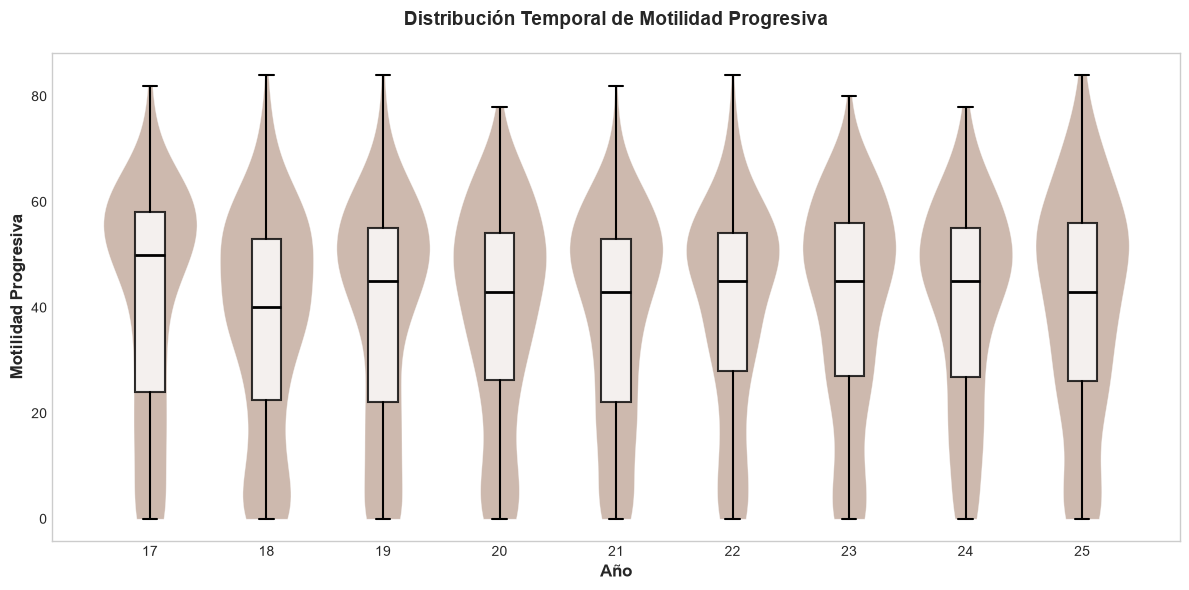

In [37]:
graficas_numericas(df,'motilidad_progresiva_pct', 'Motilidad Progresiva', color='#9C755F')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de espermatozoides con motilidad progresiva para cada año del período 2017-2025. Se observa que la motilidad progresiva se mantiene estable alrededor del 38.15-41.32% en todos los años, sin una tendencia clara de aumento o disminución. La variabilidad es alta (CV 47.52-54.81%) y la distribución presenta un ligero sesgo negativo, indicando que la mayoría de los pacientes tienen motilidades en el rango medio-alto, con algunos casos de motilidad nula (0%).

**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 41.3 | 50.0 | -8.7 | Valor más alto |
| 2018 | 37.3 | 40.0 | -2.7 | Valor más bajo |
| 2019 | 38.8 | 45.0 | -6.1 | Recuperación |
| 2020 | 39.1 | 43.0 | -3.9 | Estable |
| 2021 | 38.2 | 43.0 | -4.8 | Estable |
| 2022 | 39.6 | 45.0 | -5.4 | Estable |
| 2023 | 40.0 | 45.0 | -5.0 | Estable |
| 2024 | 40.5 | 45.0 | -4.5 | Estable |
| 2025 | 40.4 | 43.0 | -2.6 | Estable |

- En todos los años, la media es menor que la mediana, indicando sesgo negativo
- La media varía entre 37.31% (2018) y 41.32% (2017), una diferencia de solo 4 puntos porcentuales
- 2017 destaca como el año con mayor motilidad (media 41.32%, mediana 50%)
- 2018 presenta el valor más bajo (media 37.31%, mediana 40%)
- A partir de 2019, la motilidad se estabiliza alrededor del 38.91-40.50%

**Evolución de la Motilidad Progresiva**

| Período | Media (%) | Mediana (%) | Tendencia |
|---------|-----------|-------------|-----------|
| 2017 | 41.3 | 50.0 | Valor más alto |
| 2018 | 37.3 | 40.0 | Caída significativa (-4.0%) |
| 2019-2021 | 38.2 - 39.1 | 43.0 - 45.0 | Recuperación y estabilidad |
| 2022-2025 | 39.6 - 40.5 | 43.0 - 45.0 | Estabilización |

- Caída entre 2017 y 2018, disminución de 4 puntos porcentuales
- Recuperación gradual desde 2019
- Estabilización en niveles de 39-41% desde 2020
- No hay una tendencia clara de mejora o deterioro a largo plazo

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 21.2 | 34.0 | 51.3 | Variabilidad alta |
| 2018 | 20.5 | 30.5 | 54.8 | Variabilidad más alta |
| 2019 | 20.9 | 33.0 | 53.8 | Variabilidad alta |
| 2020 | 20.0 | 27.8 | 51.3 | Variabilidad alta |
| 2021 | 19.6 | 31.0 | 51.5 | Variabilidad alta |
| 2022 | 19.5 | 26.0 | 49.2 | Variabilidad más baja |
| 2023 | 20.1 | 29.0 | 50.3 | Variabilidad alta |
| 2024 | 19.3 | 28.3 | 47.5 | Variabilidad más baja |
| 2025 | 21.2 | 30.0 | 52.4 | Variabilidad alta |

- El CV es alto (47.52-54.81%), indicando una variabilidad relativa considerable
- 2024 presenta la menor variabilidad (CV 47.52%, IQR 28.25)
- 2018 presenta la mayor variabilidad (CV 54.81%)
- El IQR es amplio (26-34 puntos porcentuales), mostrando diversidad en la motilidad

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 82 | 82 | Rango muy amplio |
| 2018 | 0 | 84 | 84 | Rango muy amplio |
| 2019 | 0 | 84 | 84 | Rango muy amplio |
| 2020 | 0 | 78 | 78 | Rango muy amplio |
| 2021 | 0 | 82 | 82 | Rango muy amplio |
| 2022 | 0 | 84 | 84 | Rango muy amplio |
| 2023 | 0 | 80 | 80 | Rango muy amplio |
| 2024 | 0 | 78 | 78 | Rango muy amplio |
| 2025 | 0 | 84 | 84 | Rango muy amplio |

- El valor mínimo es 0% en todos los años (casos sin motilidad progresiva)
- El valor máximo es 78-84% en todos los años
- El rango es muy amplio (78-84 puntos porcentuales) en todos los años

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | -0.61 | -0.81 | Sesgo negativo moderado, distribución platicúrtica |
| 2018 | -0.36 | -0.81 | Sesgo negativo leve, distribución platicúrtica |
| 2019 | -0.48 | -0.83 | Sesgo negativo leve, distribución platicúrtica |
| 2020 | -0.50 | -0.73 | Sesgo negativo leve, distribución platicúrtica |
| 2021 | -0.47 | -0.83 | Sesgo negativo leve, distribución platicúrtica |
| 2022 | -0.56 | -0.52 | Sesgo negativo moderado |
| 2023 | -0.55 | -0.69 | Sesgo negativo moderado |
| 2024 | -0.54 | -0.61 | Sesgo negativo moderado |
| 2025 | -0.34 | -0.74 | Sesgo negativo leve |

- Todos los años presentan sesgo negativo (skew < 0), indicando cola hacia valores bajos
- La curtosis es negativa en todos los años, indicando distribuciones platicúrticas (más aplanadas que una distribución normal)
- 2017 muestra el sesgo más negativo (-0.61)
- 2025 muestra el sesgo menos negativo (-0.34), distribución más simétrica

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación de la Motilidad Progresiva por Año**
|
Para evaluar si existe relación entre el año de estudio y el porcentaje de espermatozoides con motilidad progresiva, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las motilidades progresivas medias entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en la motilidad progresiva de los pacientes.

In [38]:
funcion_numericas(df,'motilidad_progresiva_pct', 'Motilidad Progresiva')


=== Motilidad Progresiva ===

Prueba de Normalidad Global
- n = 3384, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 366, p-value = <1e-10 → No Normal
- Año 18: n = 443, p-value = 1.05e-10 → No Normal
- Año 19: n = 451, p-value = <1e-10 → No Normal
- Año 20: n = 310, p-value = 1.95e-09 → No Normal
- Año 21: n = 377, p-value = <1e-10 → No Normal
- Año 22: n = 370, p-value = <1e-10 → No Normal
- Año 23: n = 365, p-value = <1e-10 → No Normal
- Año 24: n = 336, p-value = 1.59e-09 → No Normal
- Año 25: n = 366, p-value = 8.56e-08 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.05, p-value = 3.99e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 16.40, p-value = 3.70e-02
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
   

**Resumen General**

El análisis estadístico revela que existen diferencias significativas en la motilidad progresiva entre los años de estudio (p = 0.0370). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados. Las pruebas post-hoc con corrección de Bonferroni identifican que la única diferencia significativa se encuentra entre 2017 y 2018 (p = 0.0127). El resto de los años no presentan diferencias estadísticamente significativas entre sí.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal (p < 0.001 en todos los casos)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre los años (CV ~47.52-54.81%)
- Sin embargo, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- Existe evidencia significativa de que la motilidad progresiva varía entre los años (p < 0.05)
- El estadístico H = 16.40 indica una diferencia moderada
- La probabilidad de observar estas diferencias por azar es del 3.70%, justo por debajo del umbral del 5%


**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value (Bonferroni) | Media (%) | Diferencia | Interpretación |
|-------------|---------------------|-----------|------------|----------------|
| 2017 vs 2018 | 0.013 | 41.3 vs 37.3 | -4.0 | Diferencia significativa |

### **Motilidad No Progresiva**

#### **Análisis Descriptivo y Visual de la Distribución de la Motilidad No Progresiva a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de espermatozoides con motilidad no progresiva en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en la motilidad no progresiva de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Motilidad No Progresiva según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,366,12.99,8.07,0.00,6.00,13.00,19.00,58.00,13.00,62.08,0.49,1.50
18,443,13.02,8.80,0.00,5.00,13.00,20.00,44.00,15.00,67.57,0.30,-0.80
19,451,13.05,8.66,0.00,5.00,14.00,20.00,40.00,15.00,66.37,0.14,-0.99
20,310,13.42,8.80,0.00,5.00,13.50,20.00,45.00,15.00,65.54,0.27,-0.72
21,377,11.75,8.23,0.00,5.00,10.00,18.00,38.00,13.00,70.07,0.50,-0.62
22,370,11.57,7.88,0.00,5.00,10.00,17.00,54.00,12.00,68.14,0.76,1.26
23,365,11.96,7.67,0.00,6.00,12.00,17.00,57.00,11.00,64.09,0.84,2.41
24,336,10.82,7.83,0.00,5.00,9.00,14.00,43.00,9.00,72.35,1.06,0.66
25,366,7.87,7.27,0.00,3.00,5.00,10.00,37.00,7.00,92.36,1.41,1.53


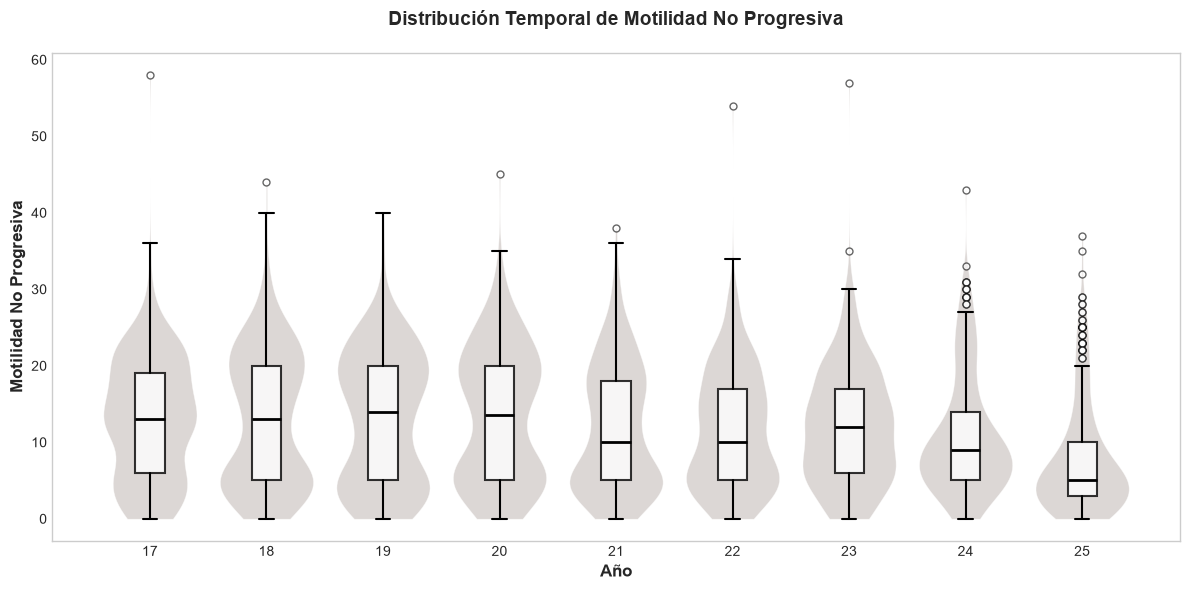

In [39]:
graficas_numericas(df,'motilidad_no_progresiva_pct', 'Motilidad No Progresiva', color='#BAB0AC')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de espermatozoides con motilidad no progresiva para cada año del período 2017-2025. Se observa una tendencia clara a la disminución en los años más recientes, con una caída significativa en 2025 (media 7.87%, mediana 5.0%) en comparación con años anteriores (media 10.82-13.42%). La variabilidad es muy alta (CV 62.08-92.36%) y la distribución presenta un sesgo positivo, indicando que la mayoría de los pacientes tienen valores bajos, con algunos casos de motilidad no progresiva elevada.


**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 13.0 | 13.0 | 0.0 | Distribución simétrica |
| 2018 | 13.0 | 13.0 | 0.0 | Distribución simétrica |
| 2019 | 13.1 | 14.0 | -0.9 | Sesgo negativo leve |
| 2020 | 13.4 | 13.5 | -0.1 | Distribución simétrica |
| 2021 | 11.8 | 10.0 | +1.8 | Sesgo positivo |
| 2022 | 11.6 | 10.0 | +1.6 | Sesgo positivo |
| 2023 | 12.0 | 12.0 | 0.0 | Distribución simétrica |
| 2024 | 10.8 | 9.0 | +1.8 | Sesgo positivo |
| 2025 | 7.9 | 5.0 | +2.9 | Sesgo positivo |

- La media varía entre 7.87% (2025) y 13.42% (2020)
- La mediana varía entre 5.0% (2025) y 14.0% (2019)
- 2025 destaca con los valores más bajos (media 7.87%, mediana 5.0%)
- 2024 también muestra una disminución (media 10.82%, mediana 9.0%)
- Los años 2017-2020 tienen valores más altos y estables (~13%)

**Evolución de la Motilidad No Progresiva**

| Período | Media (%) | Mediana (%) | Tendencia |
|---------|-----------|-------------|-----------|
| 2017-2020 | 13.0 - 13.4 | 13.0 - 14.0 | Estable (nivel alto) |
| 2021-2023 | 11.6 - 12.0 | 10.0 - 12.0 | Descenso gradual |
| 2024 | 10.8 | 9.0 | Descenso |
| 2025 | 7.9 | 5.0 | Caída significativa |

- Tendencia clara de disminución desde 2020
- Caída total, -5.5 puntos porcentuales entre 2020 y 2025
- Reducción en la mediana, -9.0 puntos porcentuales entre 2019 y 2025
- Los valores más bajos se registran en 2025

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 8.1 | 13.0 | 62.1 | Variabilidad alta |
| 2018 | 8.8 | 15.0 | 67.6 | Variabilidad alta |
| 2019 | 8.7 | 15.0 | 66.4 | Variabilidad alta |
| 2020 | 8.8 | 15.0 | 65.5 | Variabilidad alta |
| 2021 | 8.2 | 13.0 | 70.1 | Variabilidad alta |
| 2022 | 7.9 | 12.0 | 68.1 | Variabilidad alta |
| 2023 | 7.7 | 11.0 | 64.1 | Variabilidad alta |
| 2024 | 7.8 | 9.0 | 72.4 | Variabilidad alta |
| 2025 | 7.3 | 7.0 | 92.4 | Variabilidad extremadamente alta |

- El CV es muy alto en todos los años (62.08-92.36%)
- 2025 presenta la mayor variabilidad (CV 92.36%, el más alto de toda la serie)
- El IQR se ha reducido de 13-15% (2017-2020) a 7% (2025)
- La reducción del IQR indica que los valores se están concentrando en niveles más bajos

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 58 | 58 | Rango amplio |
| 2018 | 0 | 44 | 44 | Rango amplio |
| 2019 | 0 | 40 | 40 | Rango amplio |
| 2020 | 0 | 45 | 45 | Rango amplio |
| 2021 | 0 | 38 | 38 | Rango amplio |
| 2022 | 0 | 54 | 54 | Rango amplio |
| 2023 | 0 | 57 | 57 | Rango amplio |
| 2024 | 0 | 43 | 43 | Rango amplio |
| 2025 | 0 | 37 | 37 | Rango más reducido |

- El valor mínimo es 0% en todos los años (casos sin motilidad no progresiva)
- El valor máximo ha disminuido de 58% (2017) a 37% (2025)
- El rango se ha reducido de 58 puntos (2017) a 37 puntos (2025)
- La reducción del máximo sugiere que los casos con motilidad no progresiva muy alta son cada vez menos frecuentes

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | 0.49 | 1.50 | Sesgo positivo leve |
| 2018 | 0.30 | -0.80 | Sesgo positivo leve, distribución platicúrtica |
| 2019 | 0.14 | -0.99 | Distribución casi simétrica |
| 2020 | 0.27 | -0.72 | Sesgo positivo leve |
| 2021 | 0.50 | -0.62 | Sesgo positivo leve |
| 2022 | 0.76 | 1.26 | Sesgo positivo moderado |
| 2023 | 0.84 | 2.41 | Sesgo positivo moderado |
| 2024 | 1.06 | 0.66 | Sesgo positivo notable |
| 2025 | 1.41 | 1.53 | Sesgo positivo fuerte |

- El sesgo ha aumentado de 0.14 (2019) a 1.41 (2025)
- La curtosis es variable, pero tiende a ser más positiva en años recientes
- La distribución se está volviendo más asimétrica con el tiempo, con una cola más larga hacia valores altos

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación de la Motilidad No Progresiva por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de espermatozoides con motilidad no progresiva, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las motilidades no progresivas medias entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en la motilidad no progresiva de los pacientes.

In [40]:
funcion_numericas(df,'motilidad_no_progresiva_pct', 'Motilidad No Progresiva')


=== Motilidad No Progresiva ===

Prueba de Normalidad Global
- n = 3384, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 366, p-value = 3.97e-09 → No Normal
- Año 18: n = 443, p-value = <1e-10 → No Normal
- Año 19: n = 451, p-value = <1e-10 → No Normal
- Año 20: n = 310, p-value = 1.61e-08 → No Normal
- Año 21: n = 377, p-value = <1e-10 → No Normal
- Año 22: n = 370, p-value = 2.03e-10 → No Normal
- Año 23: n = 365, p-value = 2.16e-09 → No Normal
- Año 24: n = 336, p-value = <1e-10 → No Normal
- Año 25: n = 366, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 13.48, p-value = <1e-10

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 133.80, p-value = <1e-10
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
  

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en la motilidad no progresiva entre los años de estudio (p < 1e-10). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años y a la falta de homogeneidad de varianzas (p < 0.001). Las pruebas post-hoc con corrección de Bonferroni identifican un patrón claro,  2025 se destaca como el año con la motilidad no progresiva significativamente más baja en comparación con todos los años anteriores, mientras que 2024 también muestra diferencias significativas con los años iniciales (2017-2020).

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal (p < 0.001)
- Esto se debe al sesgo positivo y la presencia de outliers
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- Las varianzas son significativamente diferentes entre los años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- Existe evidencia abrumadora de que la motilidad no progresiva varía entre los años (p < 0.001)
- El estadístico H = 133.80 indica una diferencia muy fuerte
- La probabilidad de observar estas diferencias por azar es prácticamente nula


**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media 2025 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2025 | < 0.001 | 7.9 | 13.0 | -5.1 |
| 2018 vs 2025 | < 0.001 | 7.9 | 13.0 | -5.1 |
| 2019 vs 2025 | < 0.001 | 7.9 | 13.1 | -5.2 |
| 2020 vs 2025 | < 0.001 | 7.9 | 13.4 | -5.5 |
| 2021 vs 2025 | < 0.001 | 7.9 | 11.8 | -3.9 |
| 2022 vs 2025 | < 0.001 | 7.9 | 11.6 | -3.7 |
| 2023 vs 2025 | < 0.001 | 7.9 | 12.0 | -4.1 |
| 2024 vs 2025 | < 0.001 | 7.9 | 10.8 | -2.9 |

**Año 2024 vs Años Iniciales (2017-2020)**

| Par de Años | p-value | Media 2024 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2024 | 0.025 | 10.8 | 13.0 | -2.2 |
| 2018 vs 2024 | 0.046 | 10.8 | 13.0 | -2.2 |
| 2019 vs 2024 | 0.030 | 10.8 | 13.1 | -2.3 |
| 2020 vs 2024 | 0.011 | 10.8 | 13.4 | -2.6 |

### **Espermatozoides Inmóviles**

#### **Análisis Descriptivo y Visual de la Distribución del Porcentaje de Espermatozoides Inmóviles a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de espermatozoides inmóviles en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en el porcentaje de espermatozoides inmóviles de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Inmóvil según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,366,39.94,24.26,0.00,22.00,33.00,58.50,100.00,36.50,60.75,0.62,-0.42
18,443,45.38,24.48,0.00,27.00,42.00,62.00,100.00,35.00,53.93,0.38,-0.59
19,451,41.25,23.99,0.00,25.00,36.00,57.00,100.00,32.00,58.16,0.55,-0.33
20,310,41.40,23.07,0.00,26.00,37.00,58.00,99.00,32.00,55.72,0.47,-0.30
21,377,46.12,23.90,0.00,28.00,40.00,63.00,100.00,35.00,51.83,0.37,-0.61
22,370,43.16,22.45,0.00,28.00,38.50,57.75,100.00,29.75,52.02,0.43,-0.18
23,365,44.48,23.51,0.00,28.00,39.00,59.00,100.00,31.00,52.84,0.65,-0.18
24,336,45.40,22.95,0.00,28.00,40.00,62.00,100.00,34.00,50.54,0.40,-0.53
25,366,47.11,22.72,0.00,31.25,46.00,63.75,100.00,32.50,48.23,0.16,-0.36


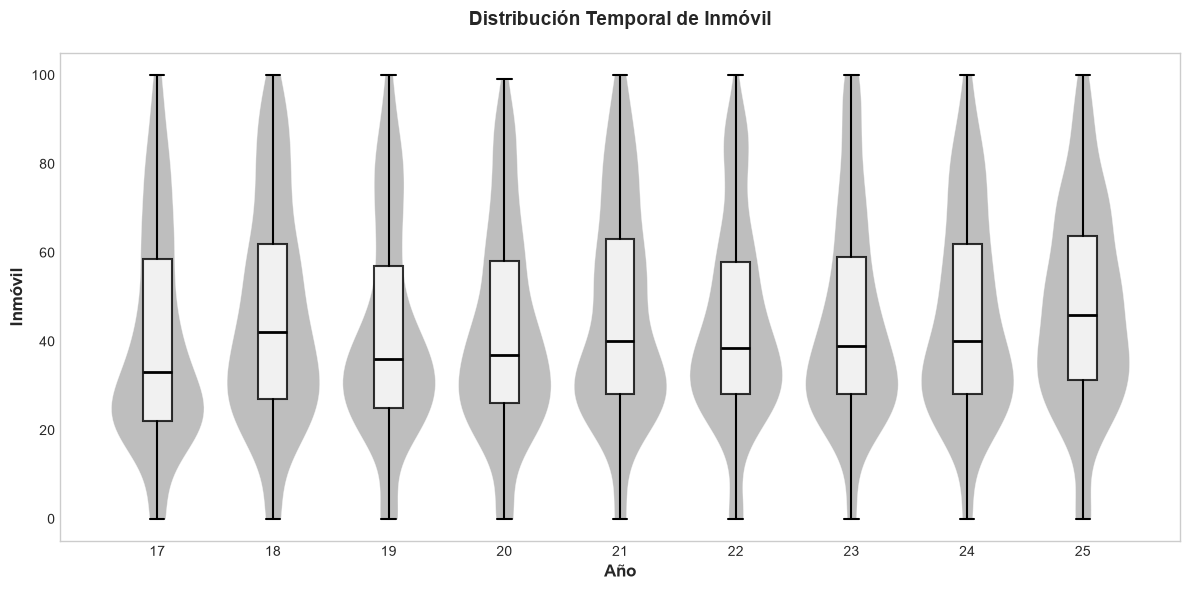

In [41]:
graficas_numericas(df,'inmovil_pct', 'Inmóvil', color='#7F7F7F')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de espermatozoides inmóviles para cada año del período 2017-2025. Se observa una tendencia general al aumento en el porcentaje de inmóviles, pasando de 39.9% en 2017 a 47.11% en 2025. La variabilidad es alta (CV 48.23-60.75%) y la distribución presenta un ligero sesgo positivo, indicando que la mayoría de los pacientes tienen porcentajes de inmóviles en el rango medio, con algunos casos de inmovilidad total (100%).

**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 39.9 | 33.0 | +6.9 | Sesgo positivo (media > mediana) |
| 2018 | 45.4 | 42.0 | +3.4 | Sesgo positivo |
| 2019 | 41.3 | 36.0 | +5.3 | Sesgo positivo |
| 2020 | 41.4 | 37.0 | +4.4 | Sesgo positivo |
| 2021 | 46.1 | 40.0 | +6.1 | Valor alto |
| 2022 | 43.2 | 38.5 | +4.7 | Sesgo positivo |
| 2023 | 44.5 | 39.0 | +5.5 | Sesgo positivo |
| 2024 | 45.4 | 40.0 | +5.4 | Sesgo positivo |
| 2025 | 47.1 | 46.0 | +1.1 | Valor más alto |

- En todos los años, la media es mayor que la mediana, indicando sesgo positivo
- La media varía entre 39.94% (2017) y 47.11% (2025), un incremento de 7.2 puntos porcentuales
- La mediana varía entre 33.0% (2017) y 46.0% (2025)**, un incremento de 13 puntos porcentuales
- 2021 y 2025 destacan como los años con mayor porcentaje de inmóviles

**Evolución de los Espermatozoides Inmóviles**

| Período | Media (%) | Mediana (%) | Tendencia |
|---------|-----------|-------------|-----------|
| 2017 | 39.9 | 33.0 | Valor más bajo |
| 2018-2020 | 41.3 - 45.4 | 36.0 - 42.0 | Aumento |
| 2021-2023 | 43.2 - 46.1 | 38.5 - 40.0 | Nivel alto |
| 2024-2025 | 45.4 - 47.1 | 40.0 - 46.0 | Nivel más alto |

- Tendencia general de aumento desde 2017
- Incremento total, +7.2 puntos porcentuales en la media entre 2017 y 2025
- Incremento en la mediana, +13 puntos porcentuales entre 2017 y 2025
- 2025 presenta el valor más alto de toda la serie (media 47.11%, mediana 46.0%)

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 24.3 | 36.5 | 60.8 | Variabilidad más alta |
| 2018 | 24.5 | 35.0 | 53.9 | Variabilidad alta |
| 2019 | 24.0 | 32.0 | 58.2 | Variabilidad alta |
| 2020 | 23.1 | 32.0 | 55.7 | Variabilidad alta |
| 2021 | 23.9 | 35.0 | 51.8 | Variabilidad alta |
| 2022 | 22.5 | 29.8 | 52.0 | Variabilidad alta |
| 2023 | 23.5 | 31.0 | 52.8 | Variabilidad alta |
| 2024 | 23.0 | 34.0 | 50.5 | Variabilidad más baja |
| 2025 | 22.7 | 32.5 | 48.2 | Variabilidad más baja |

- El CV es alto (48.23-60.75%), indicando una variabilidad relativa considerable
- La variabilidad ha disminuido desde 2017 (CV 60.75% → 48.23% en 2025)
- El IQR es amplio (29.75-36.50 puntos porcentuales), mostrando diversidad en la inmovilidad

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 100 | 100 | Rango completo |
| 2018 | 0 | 100 | 100 | Rango completo |
| 2019 | 0 | 100 | 100 | Rango completo |
| 2020 | 0 | 99 | 99 | Rango casi completo |
| 2021 | 0 | 100 | 100 | Rango completo |
| 2022 | 0 | 100 | 100 | Rango completo |
| 2023 | 0 | 100 | 100 | Rango completo |
| 2024 | 0 | 100 | 100 | Rango completo |
| 2025 | 0 | 100 | 100 | Rango completo |

- El valor mínimo es 0% en todos los años (casos sin inmóviles)
- El valor máximo es 100% en casi todos los años (casos de inmovilidad total)
- El rango es completo (0-100%) en todos los años

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | 0.62 | -0.42 | Sesgo positivo moderado |
| 2018 | 0.38 | -0.59 | Sesgo positivo leve |
| 2019 | 0.55 | -0.33 | Sesgo positivo moderado |
| 2020 | 0.47 | -0.30 | Sesgo positivo leve |
| 2021 | 0.37 | -0.61 | Sesgo positivo leve |
| 2022 | 0.43 | -0.18 | Sesgo positivo leve |
| 2023 | 0.65 | -0.18 | Sesgo positivo moderado |
| 2024 | 0.40 | -0.53 | Sesgo positivo leve |
| 2025 | 0.16 | -0.36 | Sesgo prácticamente nulo |

- Todos los años presentan sesgo positivo (skew > 0), indicando cola hacia valores altos
- La curtosis es negativa en todos los años, indicando distribuciones platicúrticas (más aplanadas)
- 2025 presenta el sesgo más bajo (0.16), indicando una distribución más simétrica

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Porcentaje de Espermatozoides Inmóviles por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de espermatozoides inmóviles, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los porcentajes de inmóviles entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en el porcentaje de espermatozoides inmóviles de los pacientes.

In [42]:
funcion_numericas(df,'inmovil_pct', 'Espermatozoides Inmóviles')


=== Espermatozoides Inmóviles ===

Prueba de Normalidad Global
- n = 3384, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 366, p-value = <1e-10 → No Normal
- Año 18: n = 443, p-value = 1.38e-08 → No Normal
- Año 19: n = 451, p-value = <1e-10 → No Normal
- Año 20: n = 310, p-value = 1.58e-07 → No Normal
- Año 21: n = 377, p-value = 1.82e-08 → No Normal
- Año 22: n = 370, p-value = 7.90e-09 → No Normal
- Año 23: n = 365, p-value = <1e-10 → No Normal
- Año 24: n = 336, p-value = 3.93e-07 → No Normal
- Año 25: n = 366, p-value = 3.74e-04 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.11, p-value = 3.51e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 45.23, p-value = 3.32e-07
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonfer

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en el porcentaje de espermatozoides inmóviles entre los años de estudio (p = 3.32e-07). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados. Las pruebas post-hoc con corrección de Bonferroni identifican un patrón claro, 2017 es el año con el porcentaje más bajo de inmóviles, difiriendo significativamente de 2018, 2021, 2024 y 2025; mientras que 2025 es el año con el porcentaje más alto, difiriendo de 2017, 2019 y 2020.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre los años (CV 48.23-60.75%)
- Sin embargo, la falta de normalidad impide usar ANOVA

**2. Análisis Principal**

- Existe evidencia muy sólida de que el porcentaje de inmóviles varía entre los años (p < 0.001)
- El estadístico H = 45.23 indica una diferencia fuerte
- La probabilidad de observar estas diferencias por azar es prácticamente nula

**Año 2017 vs Años Posteriores**

| Par de Años | p-value | Media 2017 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2018 | 0.003 | 39.9 | 45.4 | +5.5 |
| 2017 vs 2021 | < 0.001 | 39.9 | 46.1 | +6.2 |
| 2017 vs 2024 | 0.005 | 39.9 | 45.4 | +5.5 |
| 2017 vs 2025 | < 0.001 | 39.9 | 47.1 | +7.2 |

**Año 2025 vs Años Anteriores**

| Par de Años | p-value | Media 2025 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2019 vs 2025 | < 0.001 | 47.1 | 41.3 | +5.8 |
| 2020 vs 2025 | 0.011 | 47.1 | 41.4 | +5.7 |
| 2017 vs 2025 | < 0.001 | 47.1 | 39.9 | +7.2 |

### **Motilidad Total**

#### **Análisis Descriptivo y Visual de la Distribución de la Motilidad Total a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de motilidad total (progresiva + no progresiva) en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en la motilidad total de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Motilidad Total según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,366,54.31,25.91,0.00,36.00,63.00,76.00,90.00,40.00,47.71,-0.76,-0.65
18,443,50.32,24.91,0.00,32.00,56.00,71.00,89.00,39.00,49.51,-0.56,-0.80
19,451,51.88,25.47,0.00,32.00,62.00,72.00,86.00,40.00,49.11,-0.77,-0.69
20,310,52.47,24.51,0.00,38.25,60.00,72.75,89.00,34.50,46.70,-0.77,-0.51
21,377,49.90,24.22,0.00,32.00,56.00,70.00,90.00,38.00,48.54,-0.57,-0.82
22,370,51.16,23.44,0.00,38.00,59.00,70.00,86.00,32.00,45.82,-0.80,-0.45
23,365,51.98,24.10,0.00,36.00,60.00,71.00,90.00,35.00,46.37,-0.81,-0.45
24,336,51.32,23.36,0.00,34.00,57.00,71.00,88.00,37.00,45.52,-0.62,-0.65
25,366,48.26,22.84,0.00,32.00,51.50,66.75,91.00,34.75,47.32,-0.53,-0.59


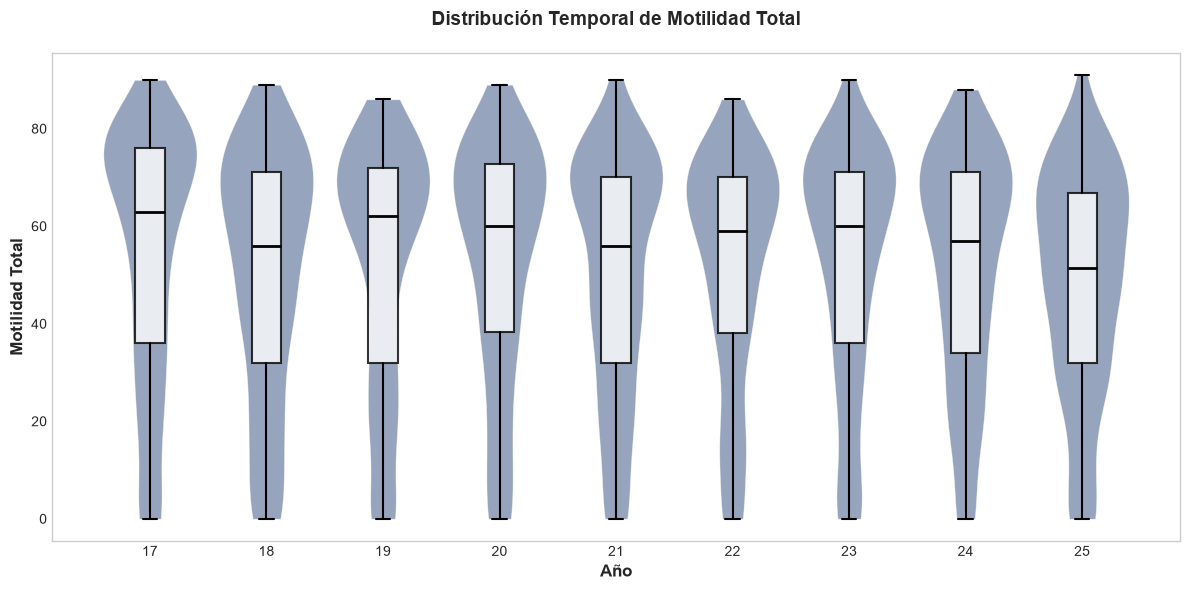

In [43]:
graficas_numericas(df,'motilidad_total_pct', 'Motilidad Total', color='#2F4B7C')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de motilidad total (progresiva + no progresiva) para cada año del período 2017-2025. Se observa que la motilidad total se mantiene relativamente estable alrededor del 48.26-54.31% en la mayoría de los años, con una tendencia a la disminución en los años más recientes, alcanzando su valor más bajo en 2025 (48.26%). La variabilidad es moderada-alta (CV 45.52-49.51%) y la distribución presenta un sesgo negativo, indicando que la mayoría de los pacientes tienen motilidades en el rango medio-alto, con algunos casos de motilidad nula (0%).

**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 54.3 | 63.0 | -8.7 | Valor más alto |
| 2018 | 50.3 | 56.0 | -5.7 | Caída |
| 2019 | 51.9 | 62.0 | -10.1 | Recuperación parcial |
| 2020 | 52.5 | 60.0 | -7.5 | Estable |
| 2021 | 49.9 | 56.0 | -6.1 | Descenso |
| 2022 | 51.2 | 59.0 | -7.8 | Estable |
| 2023 | 52.0 | 60.0 | -8.0 | Estable |
| 2024 | 51.3 | 57.0 | -5.7 | Estable |
| 2025 | 48.3 | 51.5 | -3.2 | Valor más bajo |

- En todos los años, la media es menor que la mediana, indicando sesgo negativo
- La media varía entre 48.26% (2025) y 54.31% (2017), una diferencia de 6 puntos porcentuales
- La mediana varía entre 51.5% (2025) y 63.0% (2017), una diferencia de 11.5 puntos
- 2017 destaca como el año con mayor motilidad total (media 54.31%, mediana 63%)
- 2025 presenta el valor más bajo (media 48.26%, mediana 51.5%)

**Evolución de la Motilidad Total**

| Período | Media (%) | Mediana (%) | Tendencia |
|---------|-----------|-------------|-----------|
| 2017 | 54.3 | 63.0 | Valor más alto |
| 2018-2024 | 49.9 - 52.5 | 56.0 - 62.0 | Estable (~51%) |
| 2025 | 48.3 | 51.5 | Caída significativa |

- Caída entre 2017 y 2018, disminución de 4 puntos porcentuales
- Estabilización entre 2018 y 2024 (49.90-52.47%)
- Nueva caída en 2025, 48.26%, el valor más bajo de la serie
- Reducción total, -6 puntos porcentuales entre 2017 y 2025

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 25.9 | 40.0 | 47.7 | Variabilidad moderada-alta |
| 2018 | 24.9 | 39.0 | 49.5 | Variabilidad moderada-alta |
| 2019 | 25.5 | 40.0 | 49.1 | Variabilidad moderada-alta |
| 2020 | 24.5 | 34.5 | 46.7 | Variabilidad más baja |
| 2021 | 24.2 | 38.0 | 48.5 | Variabilidad moderada-alta |
| 2022 | 23.4 | 32.0 | 45.8 | Variabilidad más baja |
| 2023 | 24.1 | 35.0 | 46.4 | Variabilidad moderada-alta |
| 2024 | 23.4 | 37.0 | 45.5 | Variabilidad más baja |
| 2025 | 22.8 | 34.8 | 47.3 | Variabilidad moderada-alta |

- El CV varía entre 45.52% y 49.51%, indicando una variabilidad moderada-alta
- La variabilidad ha disminuido desde 2017 (CV 47.71% → 45.52% en 2024)
- El IQR es amplio (32-40 puntos porcentuales), mostrando diversidad en la motilidad

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 90 | 90 | Rango muy amplio |
| 2018 | 0 | 89 | 89 | Rango muy amplio |
| 2019 | 0 | 86 | 86 | Rango muy amplio |
| 2020 | 0 | 89 | 89 | Rango muy amplio |
| 2021 | 0 | 90 | 90 | Rango muy amplio |
| 2022 | 0 | 86 | 86 | Rango muy amplio |
| 2023 | 0 | 90 | 90 | Rango muy amplio |
| 2024 | 0 | 88 | 88 | Rango muy amplio |
| 2025 | 0 | 91 | 91 | Rango muy amplio |

- El valor mínimo es 0% en todos los años (casos sin motilidad)
- El valor máximo es 86-91% en todos los años
- El rango es muy amplio (86-91 puntos porcentuales) en todos los años

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | -0.76 | -0.65 | Sesgo negativo moderado, distribución platicúrtica |
| 2018 | -0.56 | -0.80 | Sesgo negativo leve |
| 2019 | -0.77 | -0.69 | Sesgo negativo moderado |
| 2020 | -0.77 | -0.51 | Sesgo negativo moderado |
| 2021 | -0.57 | -0.82 | Sesgo negativo leve |
| 2022 | -0.80 | -0.45 | Sesgo negativo moderado |
| 2023 | -0.81 | -0.45 | Sesgo negativo moderado |
| 2024 | -0.62 | -0.65 | Sesgo negativo leve |
| 2025 | -0.53 | -0.59 | Sesgo negativo leve |

- Todos los años presentan sesgo negativo (skew < 0), indicando cola hacia valores bajos
- La curtosis es negativa en todos los años, indicando distribuciones platicúrticas
- El sesgo es consistente en todos los años (-0.53 a -0.81)

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación de la Motilidad Total por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de motilidad total (progresiva + no progresiva), se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las motilidades totales medias entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en la motilidad total de los pacientes.

In [44]:
funcion_numericas(df,'motilidad_total_pct', 'Motilidad Total')


=== Motilidad Total ===

Prueba de Normalidad Global
- n = 3384, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 366, p-value = <1e-10 → No Normal
- Año 18: n = 443, p-value = <1e-10 → No Normal
- Año 19: n = 451, p-value = <1e-10 → No Normal
- Año 20: n = 310, p-value = <1e-10 → No Normal
- Año 21: n = 377, p-value = <1e-10 → No Normal
- Año 22: n = 370, p-value = <1e-10 → No Normal
- Año 23: n = 365, p-value = <1e-10 → No Normal
- Año 24: n = 336, p-value = <1e-10 → No Normal
- Año 25: n = 366, p-value = 1.43e-09 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.15, p-value = 3.28e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 28.71, p-value = 3.56e-04
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     17   18  

**Resumen General**

El análisis estadístico revela que existen diferencias significativas en la motilidad total entre los años de estudio (p = 3.56e-04). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados. Las pruebas post-hoc con corrección de Bonferroni identifican que 2017 es el año con la motilidad total más alta, difiriendo significativamente de 2021 y 2025, siendo este último el año con la motilidad total más baja de toda la serie.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre los años (CV 45.52-49.51%)
- Sin embargo, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- Existe evidencia sólida de que la motilidad total varía entre los años (p < 0.001)
- El estadístico H = 28.71 indica una diferencia moderada-fuerte
- La probabilidad de observar estas diferencias por azar es del 0.0356%

**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media (%) | Diferencia | Interpretación |
|-------------|---------|-----------|------------|----------------|
| 2017 vs 2021 | 0.023 | 54.3 vs 49.9 | -4.4 | Diferencia significativa |
| 2017 vs 2025 | < 0.001 | 54.3 vs 48.3 | -6.0 | Diferencia muy significativa |

### **Espermatozoides Normales**

#### **Análisis Descriptivo y Visual de la Distribución del Porcentaje de Espermatozoides Normales a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de espermatozoides con morfología normal en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en la morfología espermática de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Espermatozoides Normales según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,356,2.44,2.25,0.00,1.00,2.00,3.25,12.00,2.25,92.09,1.70,3.90
18,399,3.08,2.89,0.00,1.00,2.00,4.00,20.00,3.00,94.11,1.67,4.27
19,382,2.97,2.64,0.00,1.00,2.00,5.00,15.00,4.00,89.04,0.98,0.84
20,257,3.08,2.98,0.00,1.00,2.00,5.00,19.00,4.00,96.80,1.55,3.59
21,305,3.02,2.36,0.00,1.00,2.00,5.00,13.00,4.00,78.23,0.83,0.68
22,288,4.16,10.27,0.00,1.00,2.00,5.00,98.00,4.00,246.98,8.08,69.19
23,263,3.45,6.24,0.00,1.00,2.00,5.00,96.00,4.00,180.88,12.60,186.29
24,256,3.09,2.31,0.00,1.00,2.00,5.00,10.00,4.00,74.78,0.75,-0.27
25,276,2.41,1.97,0.00,1.00,2.00,3.00,10.00,2.00,81.63,1.27,1.60


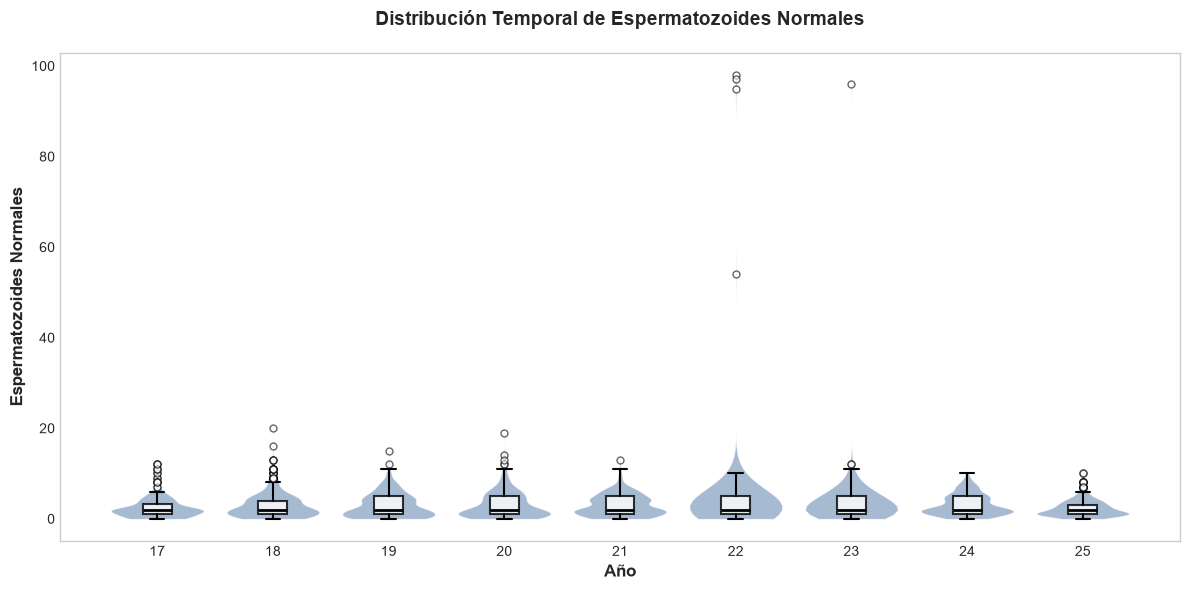

In [45]:
graficas_numericas(df,'espermatozoides_normales_pct', 'Espermatozoides Normales', color='#4E79A7')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de espermatozoides con morfología normal para cada año del período 2017-2025. Se observa que el porcentaje de formas normales es muy bajo en todos los años, con medias que oscilan entre 2.41% y 4.16%. La variabilidad es extremadamente alta (CV 74.78-246.98%), y la distribución presenta un fuerte sesgo positivo debido a la presencia de valores atípicos extremos en algunos años (hasta 98% de formas normales en 2022 y 96% en 2023). La mediana es de solo 2% en todos los años.

**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 2.44 | 2.00 | +0.44 | Sesgo positivo |
| 2018 | 3.08 | 2.00 | +1.08 | Sesgo positivo |
| 2019 | 2.97 | 2.00 | +0.97 | Sesgo positivo |
| 2020 | 3.08 | 2.00 | +1.08 | Sesgo positivo |
| 2021 | 3.02 | 2.00 | +1.02 | Sesgo positivo |
| 2022 | 4.16 | 2.00 | +2.16 | Sesgo extremo (outlier 98%) |
| 2023 | 3.45 | 2.00 | +1.45 | Sesgo extremo (outlier 96%) |
| 2024 | 3.09 | 2.00 | +1.09 | Sesgo positivo |
| 2025 | 2.41 | 2.00 | +0.41 | Sesgo positivo |

- La mediana es 2% en todos los años, indicando que la mayoría de los pacientes tienen muy pocas formas normales
- La media es muy baja (2.41-4.16%), muy por debajo del rango normal (>=4%)
- 2022 y 2023 muestran medias más altas debido a outliers extremos (98% y 96%)
- 2025 presenta el valor más bajo (media 2.41%, mediana 2%)

**Evolución de los Espermatozoides Normales**

| Período | Media (%) | Mediana (%) | Tendencia |
|---------|-----------|-------------|-----------|
| 2017 | 2.44 | 2.00 | Segundo valor más bajo |
| 2018-2024 | 2.97 - 4.16 | 2.00 | Estable (mediana 2%) |
| 2025 | 2.41 | 2.00 | Valor más bajo |

- No hay una tendencia clara de mejora o deterioro
- La mediana permanece constante en 2% en todos los años
- La media varía debido a outliers más que a cambios reales en la población

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 2.25 | 2.25 | 92.1 | Variabilidad extremadamente alta |
| 2018 | 2.89 | 3.00 | 94.1 | Variabilidad extremadamente alta |
| 2019 | 2.64 | 4.00 | 89.0 | Variabilidad extremadamente alta |
| 2020 | 2.98 | 4.00 | 96.8 | Variabilidad extremadamente alta |
| 2021 | 2.36 | 4.00 | 78.2 | Variabilidad extremadamente alta |
| 2022 | 10.27 | 4.00 | 247.0 | Variabilidad extrema (outlier 98%) |
| 2023 | 6.24 | 4.00 | 180.9 | Variabilidad extrema (outlier 96%) |
| 2024 | 2.31 | 4.00 | 74.8 | Variabilidad extremadamente alta |
| 2025 | 1.97 | 2.00 | 81.6 | Variabilidad extremadamente alta |

- El CV es extremadamente alto (74.78-246.98%), indicando una variabilidad enorme
- 2022 y 2023 presentan la mayor variabilidad debido a outliers extremos
- Sin outliers, la variabilidad sería alta pero menos extrema
- El IQR es de 2-4 puntos, mostrando que el 50% central de los pacientes tiene entre 1-5% de formas normales

**Análisis de Valores Extremos (Outliers)**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 12 | 12 | Rango moderado |
| 2018 | 0 | 20 | 20 | Rango moderado |
| 2019 | 0 | 15 | 15 | Rango moderado |
| 2020 | 0 | 19 | 19 | Rango moderado |
| 2021 | 0 | 13 | 13 | Rango moderado |
| 2022 | 0 | 98 | 98 | Outlier extremo |
| 2023 | 0 | 96 | 96 | Outlier extremo |
| 2024 | 0 | 10 | 10 | Rango moderado |
| 2025 | 0 | 10 | 10 | Rango moderado |

- El valor mínimo es 0% en todos los años
- 2022 y 2023 presentan outliers extremos (98% y 96% de formas normales)
- Estos outliers son muy poco probables
- Sin outliers, el rango máximo sería de 10-20%

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | 1.70 | 3.90 | Sesgo positivo fuerte |
| 2018 | 1.67 | 4.27 | Sesgo positivo fuerte |
| 2019 | 0.98 | 0.84 | Sesgo positivo moderado |
| 2020 | 1.55 | 3.59 | Sesgo positivo fuerte |
| 2021 | 0.83 | 0.68 | Sesgo positivo moderado |
| 2022 | 8.08 | 69.19 | Sesgo extremo (outlier 98%) |
| 2023 | 12.60 | 186.29 | Sesgo extremo (outlier 96%) |
| 2024 | 0.75 | -0.27 | Sesgo positivo moderado |
| 2025 | 1.27 | 1.60 | Sesgo positivo fuerte |

- Todos los años presentan sesgo positivo (skew > 0)
- 2022 y 2023 muestran sesgo extremo debido a outliers
- La curtosis es extremadamente alta en 2022 y 2023

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Porcentaje de Espermatozoides Normales por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de espermatozoides con morfología normal, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los porcentajes de morfología normal entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en la morfología espermática de los pacientes.

In [46]:
funcion_numericas(df,'espermatozoides_normales_pct', 'Espermatozoides Normales')


=== Espermatozoides Normales ===

Prueba de Normalidad Global
- n = 2782, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 356, p-value = <1e-10 → No Normal
- Año 18: n = 399, p-value = <1e-10 → No Normal
- Año 19: n = 382, p-value = <1e-10 → No Normal
- Año 20: n = 257, p-value = <1e-10 → No Normal
- Año 21: n = 305, p-value = <1e-10 → No Normal
- Año 22: n = 288, p-value = <1e-10 → No Normal
- Año 23: n = 263, p-value = <1e-10 → No Normal
- Año 24: n = 256, p-value = <1e-10 → No Normal
- Año 25: n = 276, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 4.20, p-value = 5.15e-05

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 28.06, p-value = 4.64e-04
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     17

**Resumen General**

El análisis estadístico revela que existen diferencias significativas en el porcentaje de espermatozoides con morfología normal entre los años de estudio (p = 4.64e-04). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años y a la falta de homogeneidad de varianzas (p < 0.001). Las pruebas post-hoc con corrección de Bonferroni identifican que 2017 es el año con menor morfología normal, difiriendo de 2021, 2023 y 2024, mientras que 2025 también muestra una caída significativa respecto a 2024.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- Esto se debe al fuerte sesgo positivo (mayoría de pacientes con =<4% y algunos outliers)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- Las varianzas son significativamente diferentes entre los años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- Existe evidencia sólida de que la morfología normal varía entre los años (p < 0.001)
- El estadístico H = 28.06 indica una diferencia moderada-fuerte
- La probabilidad de observar estas diferencias por azar es del 0.046%

**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media (%) | Diferencia | Interpretación |
|-------------|---------|-----------|------------|----------------|
| 2017 vs 2021 | 0.039 | 2.44 vs 3.02 | +0.58 | Diferencia significativa |
| 2017 vs 2023 | 0.029 | 2.44 vs 3.45 | +1.01 | Diferencia significativa |
| 2017 vs 2024 | 0.011 | 2.44 vs 3.09 | +0.65 | Diferencia significativa |
| 2024 vs 2025 | 0.039 | 3.09 vs 2.41 | -0.68 | Diferencia significativa |

### **Espermatozoides Anormales**

#### **Análisis Descriptivo y Visual de la Distribución del Porcentaje de Espermatozoides Anormales a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de espermatozoides con morfología anormal en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en la morfología anormal de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Espermatozoides Anormales según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,356,91.66,23.08,0.00,96.00,98.00,99.00,100.00,3.00,25.18,-3.70,11.94
18,399,92.41,20.31,0.00,95.00,98.00,99.00,100.00,4.00,21.98,-4.27,16.67
19,382,88.65,26.96,0.00,94.00,97.00,99.00,100.00,5.00,30.41,-2.97,6.97
20,257,89.53,25.51,0.00,94.00,97.00,99.00,100.00,5.00,28.49,-3.21,8.51
21,305,92.07,21.09,0.00,95.00,97.00,99.00,100.00,4.00,22.91,-4.11,15.24
22,288,88.55,26.89,0.00,95.00,97.00,98.00,100.00,3.00,30.37,-2.95,6.87
23,263,91.23,22.54,0.00,95.00,97.00,99.00,100.00,4.00,24.71,-3.77,12.52
24,256,92.23,20.61,0.00,95.00,97.00,98.00,100.00,3.00,22.35,-4.23,16.28
25,276,91.79,22.89,0.00,96.00,98.00,99.00,100.00,3.00,24.94,-3.76,12.35


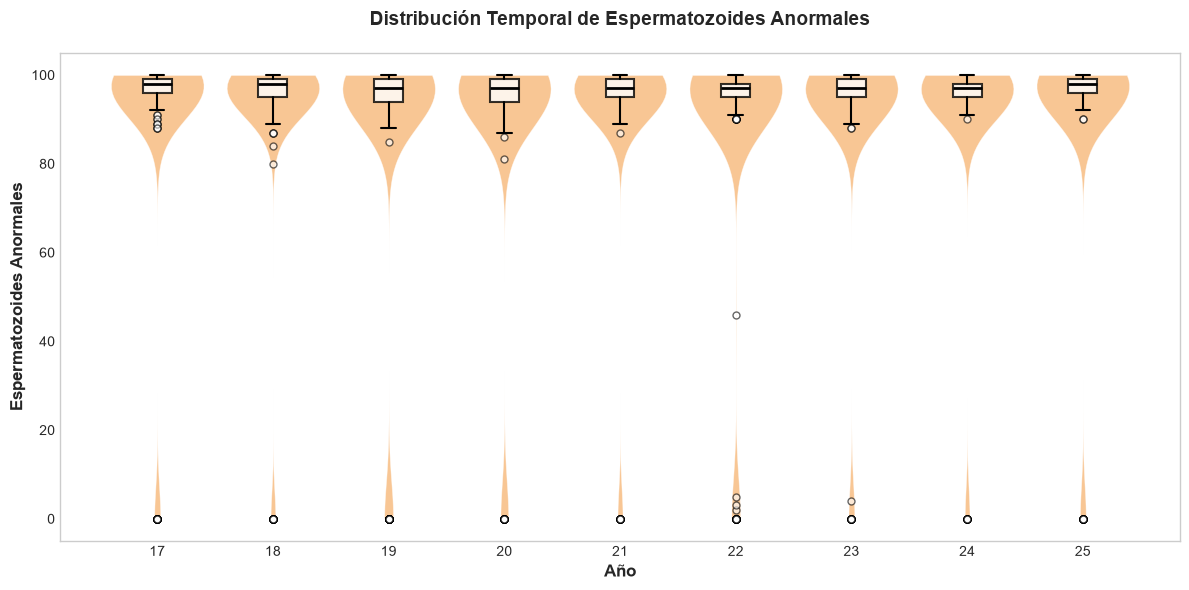

In [47]:
graficas_numericas(df,'espermatozoides_anormales_pct', 'Espermatozoides Anormales', color='#F28E2B')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de espermatozoides con morfología anormal para cada año del período 2017-2025. Se observa que el porcentaje de formas anormales es muy alto en todos los años, con medias que oscilan entre 88.55% y 92.41%, lo que refleja que la gran mayoría de los espermatozoides presentan alguna alteración morfológica. La variabilidad es moderada (CV 21.98-30.41%) y la distribución presenta un fuerte sesgo negativo, indicando que la mayoría de los pacientes tienen altos porcentajes de anormalidades, con algunos casos atípicos con valores muy bajos (0%).

**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 91.7 | 98.0 | -6.3 | Sesgo negativo (media < mediana) |
| 2018 | 92.4 | 98.0 | -5.6 | Sesgo negativo |
| 2019 | 88.7 | 97.0 | -8.4 | Sesgo negativo |
| 2020 | 89.5 | 97.0 | -7.5 | Sesgo negativo |
| 2021 | 92.0 | 97.0 | -5.0 | Sesgo negativo |
| 2022 | 88.6 | 97.0 | -8.5 | Valor más bajo |
| 2023 | 91.2 | 97.0 | -5.8 | Sesgo negativo |
| 2024 | 92.2 | 97.0 | -4.8 | Sesgo negativo |
| 2025 | 91.8 | 98.0 | -6.2 | Sesgo negativo |

- En todos los años, la media es considerablemente menor que la mediana, indicando un fuerte sesgo negativo
- La mediana (valor central) es muy alta: 97-98% de anormalidades
- El 50% de los pacientes tiene entre 95-99% de formas anormales (IQR)
- 2022 presenta el valor más bajo (media 88.55%), influenciado por casos con 0% de anormalidades

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 23.1 | 3.0 | 25.2 | Variabilidad moderada |
| 2018 | 20.3 | 4.0 | 22.0 | Variabilidad moderada |
| 2019 | 27.0 | 5.0 | 30.4 | Variabilidad más alta |
| 2020 | 25.5 | 5.0 | 28.5 | Variabilidad alta |
| 2021 | 21.1 | 4.0 | 23.0 | Variabilidad moderada |
| 2022 | 26.9 | 3.0 | 30.4 | Variabilidad más alta |
| 2023 | 22.5 | 4.0 | 24.7 | Variabilidad moderada |
| 2024 | 20.6 | 3.0 | 22.4 | Variabilidad moderada |
| 2025 | 22.9 | 3.0 | 24.9 | Variabilidad moderada |

- El CV varía entre 21.98% y 30.41%, indicando una variabilidad moderada
- La variabilidad es menor que en otras variables
- El IQR es muy estrecho (3-5 puntos), mostrando que el 50% central de los pacientes se concentra en un rango muy reducido
- 2019 y 2022 presentan la mayor variabilidad (CV > 30%)

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 100 | 100 | Rango completo |
| 2018 | 0 | 100 | 100 | Rango completo |
| 2019 | 0 | 100 | 100 | Rango completo |
| 2020 | 0 | 100 | 100 | Rango completo |
| 2021 | 0 | 100 | 100 | Rango completo |
| 2022 | 0 | 100 | 100 | Rango completo |
| 2023 | 0 | 100 | 100 | Rango completo |
| 2024 | 0 | 100 | 100 | Rango completo |
| 2025 | 0 | 100 | 100 | Rango completo |

- El valor mínimo es 0% en todos los años (casos con 0% de anormalidades)
- El valor máximo es 100% en todos los años (casos con 100% de anormalidades)
- El rango es completo (0-100%) en todos los años

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | -3.70 | 11.94 | Sesgo negativo extremo |
| 2018 | -4.27 | 16.67 | Sesgo negativo extremo |
| 2019 | -2.97 | 6.97 | Sesgo negativo fuerte |
| 2020 | -3.21 | 8.51 | Sesgo negativo extremo |
| 2021 | -4.10 | 15.18 | Sesgo negativo extremo |
| 2022 | -2.95 | 6.87 | Sesgo negativo fuerte |
| 2023 | -3.77 | 12.52 | Sesgo negativo extremo |
| 2024 | -4.23 | 16.28 | Sesgo negativo extremo |
| 2025 | -3.76 | 12.35 | Sesgo negativo extremo |

- Todos los años presentan sesgo negativo extremo (skew < -2.9)
- La curtosis es extremadamente alta en la mayoría de los años (> 6.9)
- La distribución está muy concentrada en valores altos (95-100%)
- La cola izquierda es larga hacia valores bajos (0%)

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Porcentaje de Espermatozoides Anormales por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de espermatozoides con morfología anormal, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los porcentajes de morfología anormal entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en la morfología anormal de los pacientes.

In [48]:
funcion_numericas(df,'espermatozoides_anormales_pct', 'Espermatozoides Anormales')


=== Espermatozoides Anormales ===

Prueba de Normalidad Global
- n = 2782, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 356, p-value = <1e-10 → No Normal
- Año 18: n = 399, p-value = <1e-10 → No Normal
- Año 19: n = 382, p-value = <1e-10 → No Normal
- Año 20: n = 257, p-value = <1e-10 → No Normal
- Año 21: n = 305, p-value = <1e-10 → No Normal
- Año 22: n = 288, p-value = <1e-10 → No Normal
- Año 23: n = 263, p-value = <1e-10 → No Normal
- Año 24: n = 256, p-value = <1e-10 → No Normal
- Año 25: n = 276, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.43, p-value = 1.79e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 29.52, p-value = 2.57e-04
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     1

**Resumen General**

El análisis estadístico revela que existen diferencias significativas en el porcentaje de espermatozoides con morfología anormal entre los años de estudio (p = 2.57e-04). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados. Las pruebas post-hoc con corrección de Bonferroni identifican que 2017 es el año con mayor morfología anormal, difiriendo de 2019 y 2022, mientras que 2025 muestra una caída significativa respecto a 2019 y 2022.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- Esto se debe al fuerte sesgo negativo y la presencia de valores extremos (0% y 100%)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre los años (CV 21.98-30.41%)
- Sin embargo, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- Existe evidencia sólida de que la morfología anormal varía entre los años (p < 0.001)
- El estadístico H = 29.52 indica una diferencia moderada-fuerte
- La probabilidad de observar estas diferencias por azar es del 0.0239%

**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media (%) | Diferencia | Interpretación |
|-------------|---------|-----------|------------|----------------|
| 2017 vs 2019 | 0.019 | 91.7 vs 88.7 | -3.0 | 2017 tiene mayor % anormal |
| 2017 vs 2022 | 0.009 | 91.7 vs 88.6 | -3.1 | 2017 tiene mayor % anormal |
| 2019 vs 2025 | 0.046 | 88.7 vs 91.8 | +3.1 | 2025 tiene mayor % anormal |
| 2022 vs 2025 | 0.021 | 88.6 vs 91.8 | +3.2 | 2025 tiene mayor % anormal |

### **Alteración de la Cabeza**

#### **Análisis Descriptivo y Visual de la Distribución del Porcentaje de Alteraciones de Cabeza a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de espermatozoides con alteraciones morfológicas en la cabeza, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en las alteraciones de cabeza de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Alteración de la cabeza según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,356,93.80,23.62,0.00,100.00,100.00,100.00,100.00,0.00,25.18,-3.72,11.96
18,399,93.08,20.86,0.00,96.77,100.00,100.00,100.00,3.23,22.41,-4.04,15.23
19,379,90.18,27.89,0.00,97.83,100.00,100.00,100.00,2.17,30.93,-2.91,6.58
20,256,91.61,26.07,0.00,97.91,100.00,100.00,100.00,2.09,28.45,-3.24,8.61
21,304,93.98,21.67,0.00,98.90,100.00,100.00,100.00,1.10,23.05,-4.07,14.88
22,287,91.26,25.92,0.00,97.86,100.00,100.00,100.00,2.14,28.40,-3.15,8.17
23,262,92.98,23.29,0.00,97.94,99.50,100.00,100.00,2.06,25.05,-3.69,11.93
24,256,94.67,21.06,0.00,98.92,100.00,100.00,100.00,1.08,22.25,-4.30,16.63
25,276,93.73,23.32,0.00,98.97,100.00,100.00,100.00,1.03,24.88,-3.79,12.49


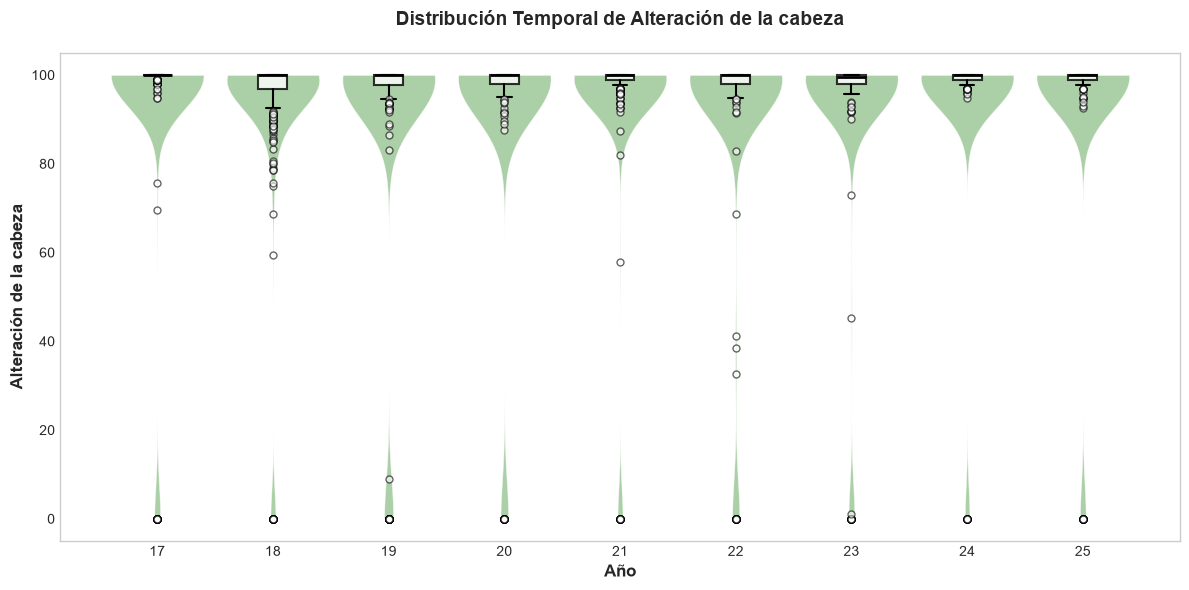

In [49]:
graficas_numericas(df,'alt_cabeza_pct', 'Alteración de la cabeza', color='#59A14F')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de espermatozoides con alteraciones morfológicas en la cabeza para cada año del período 2017-2025. Se observa que el porcentaje de alteraciones de cabeza es extremadamente alto en todos los años, con medias que oscilan entre 90.18% y 94.67%. La mediana es 100% en la mayoría de los años (excepto 2023: 99.5%), lo que indica que más del 50% de los pacientes tienen alteraciones en la cabeza de todos sus espermatozoides. La distribución presenta un sesgo negativo extremo y una variabilidad moderada (CV 22.25-30.93%), con algunos casos atípicos con 0% de alteraciones.

Análisis de Medidas de Tendencia Central

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 93.8 | 100.0 | -6.2 | Sesgo negativo extremo |
| 2018 | 93.1 | 100.0 | -6.9 | Sesgo negativo extremo |
| 2019 | 90.2 | 100.0 | -9.8 | Valor más bajo |
| 2020 | 91.6 | 100.0 | -8.4 | Sesgo negativo extremo |
| 2021 | 94.0 | 100.0 | -6.0 | Sesgo negativo extremo |
| 2022 | 91.3 | 100.0 | -8.7 | Sesgo negativo extremo |
| 2023 | 93.0 | 99.5 | -6.5 | Sesgo negativo extremo |
| 2024 | 94.7 | 100.0 | -5.3 | Valor más alto |
| 2025 | 93.7 | 100.0 | -6.3 | Sesgo negativo extremo |

- La mediana es 100% en 8 de 9 años (excepto 2023: 99.5%)
- Más del 50% de los pacientes tienen alteraciones en la cabeza en todos sus espermatozoides
- La media varía entre 90.18% (2019) y 94.67% (2024)
- 2019 presenta el valor más bajo (media 90.18%)
- 2024 presenta el valor más alto (media 94.67%)

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 23.6 | 0.0 | 25.2 | IQR = 0 (100% en Q1, Q2, Q3) |
| 2018 | 20.9 | 3.2 | 22.4 | Variabilidad moderada |
| 2019 | 27.9 | 2.2 | 30.9 | Variabilidad más alta |
| 2020 | 26.1 | 2.1 | 28.5 | Variabilidad alta |
| 2021 | 21.7 | 1.1 | 23.1 | Variabilidad moderada |
| 2022 | 25.9 | 2.1 | 28.4 | Variabilidad alta |
| 2023 | 23.3 | 2.1 | 25.1 | Variabilidad moderada |
| 2024 | 21.1 | 1.1 | 22.3 | Variabilidad más baja |
| 2025 | 23.3 | 1.0 | 24.9 | Variabilidad moderada |

- El IQR es extremadamente estrecho (0-3.23 puntos), indicando que la mayoría de los pacientes tienen valores muy cercanos al 100%
- 2017 tiene IQR = 0, lo que significa que el 50% central tiene exactamente 100% de alteraciones
- La variabilidad es moderada (CV 22.25-30.93%)
- 2019 presenta la mayor variabilidad (CV 30.93%)
- 2024 presenta la menor variabilidad (CV 22.25%)

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 100 | 100 | Rango completo |
| 2018 | 0 | 100 | 100 | Rango completo |
| 2019 | 0 | 100 | 100 | Rango completo |
| 2020 | 0 | 100 | 100 | Rango completo |
| 2021 | 0 | 100 | 100 | Rango completo |
| 2022 | 0 | 100 | 100 | Rango completo |
| 2023 | 0 | 100 | 100 | Rango completo |
| 2024 | 0 | 100 | 100 | Rango completo |
| 2025 | 0 | 100 | 100 | Rango completo |

- El valor mínimo es 0% en todos los años
- El valor máximo es 100% en todos los años
- El rango es completo (0-100%) en todos los años

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | -3.72 | 11.96 | Sesgo negativo extremo |
| 2018 | -4.04 | 15.23 | Sesgo negativo extremo |
| 2019 | -2.91 | 6.58 | Sesgo negativo fuerte |
| 2020 | -3.24 | 8.61 | Sesgo negativo extremo |
| 2021 | -4.07 | 14.88 | Sesgo negativo extremo |
| 2022 | -3.15 | 8.17 | Sesgo negativo extremo |
| 2023 | -3.69 | 11.93 | Sesgo negativo extremo |
| 2024 | -4.30 | 16.63 | Sesgo negativo extremo |
| 2025 | -3.79 | 12.49 | Sesgo negativo extremo |

- Todos los años presentan sesgo negativo extremo (skew < -2.9)
- La curtosis es extremadamente alta (> 6.5)
- La distribución está muy concentrada en 100% de alteraciones
- 2024 muestra el sesgo más negativo (-4.30) y la mayor curtosis (16.63)

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Porcentaje de Alteraciones de Cabeza por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de espermatozoides con alteraciones morfológicas en la cabeza, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los porcentajes de alteraciones de cabeza entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en las alteraciones de cabeza de los pacientes.

In [50]:
funcion_numericas(df,'alt_cabeza_pct', 'Alteración de la Cabeza')


=== Alteración de la Cabeza ===

Prueba de Normalidad Global
- n = 2775, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 356, p-value = <1e-10 → No Normal
- Año 18: n = 399, p-value = <1e-10 → No Normal
- Año 19: n = 379, p-value = <1e-10 → No Normal
- Año 20: n = 256, p-value = <1e-10 → No Normal
- Año 21: n = 304, p-value = <1e-10 → No Normal
- Año 22: n = 287, p-value = <1e-10 → No Normal
- Año 23: n = 262, p-value = <1e-10 → No Normal
- Año 24: n = 256, p-value = <1e-10 → No Normal
- Año 25: n = 276, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.23, p-value = 2.78e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 129.59, p-value = <1e-10
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     17  

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en el porcentaje de alteraciones de cabeza entre los años de estudio (p < 1e-10). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- Esto se debe al fuerte sesgo negativo (mayoría en 100%, algunos en 0%)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre los años (CV 22.25-30.93%)
- Sin embargo, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- Existe evidencia abrumadora de que las alteraciones de cabeza varían entre los años (p < 0.001)
- El estadístico H = 129.59 indica una diferencia muy fuerte
- La probabilidad de observar estas diferencias por azar es prácticamente nula

**Año 2017 vs Todos los Años 2018-2024**

| Par de Años | p-value | Media 2017 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2018 | < 0.001 | 93.8 | 93.1 | -0.7 |
| 2017 vs 2019 | < 0.001 | 93.8 | 90.2 | -3.6 |
| 2017 vs 2020 | < 0.001 | 93.8 | 91.6 | -2.2 |
| 2017 vs 2021 | < 0.001 | 93.8 | 94.0 | +0.2 |
| 2017 vs 2022 | < 0.001 | 93.8 | 91.3 | -2.5 |
| 2017 vs 2023 | < 0.001 | 93.8 | 93.0 | -0.8 |
| 2017 vs 2024 | < 0.001 | 93.8 | 94.7 | +0.9 |

**Año 2025 vs Años 2018, 2019, 2022, 2023**

| Par de Años | p-value | Media 2025 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2018 vs 2025 | < 0.001 | 93.7 | 93.1 | -0.6 |
| 2019 vs 2025 | < 0.001 | 93.7 | 90.2 | -3.5 |
| 2022 vs 2025 | < 0.001 | 93.7 | 91.3 | -2.4 |
| 2023 vs 2025 | < 0.001 | 93.7 | 93.0 | -0.7 |

### **Alteración de la Cola**

#### **Análisis Descriptivo y Visual de la Distribución del Porcentaje de Alteraciones de Cola a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de espermatozoides con alteraciones morfológicas en la cola, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en las alteraciones de cola de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Alteración de la Cola según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,351,60.30,25.73,0.00,45.17,66.00,81.63,92.00,36.45,42.68,-0.93,-0.08
18,400,55.58,23.18,0.00,39.32,59.79,72.77,100.00,33.45,41.71,-0.54,-0.38
19,376,54.82,24.93,0.00,38.50,61.30,73.73,97.89,35.23,45.47,-0.79,-0.22
20,255,50.50,23.03,0.00,36.33,53.53,68.48,95.91,32.15,45.59,-0.58,-0.34
21,304,50.18,21.99,0.00,34.18,51.02,65.07,100.00,30.89,43.82,-0.25,-0.33
22,287,45.02,21.94,0.00,29.95,45.26,62.31,100.00,32.37,48.73,-0.21,-0.56
23,262,47.14,21.13,0.00,32.80,48.37,63.82,97.84,31.01,44.84,-0.33,-0.42
24,256,44.92,21.14,0.00,28.99,45.41,62.94,89.13,33.95,47.06,-0.20,-0.72
25,276,33.29,21.87,0.00,16.16,28.14,46.80,84.00,30.64,65.68,0.59,-0.56


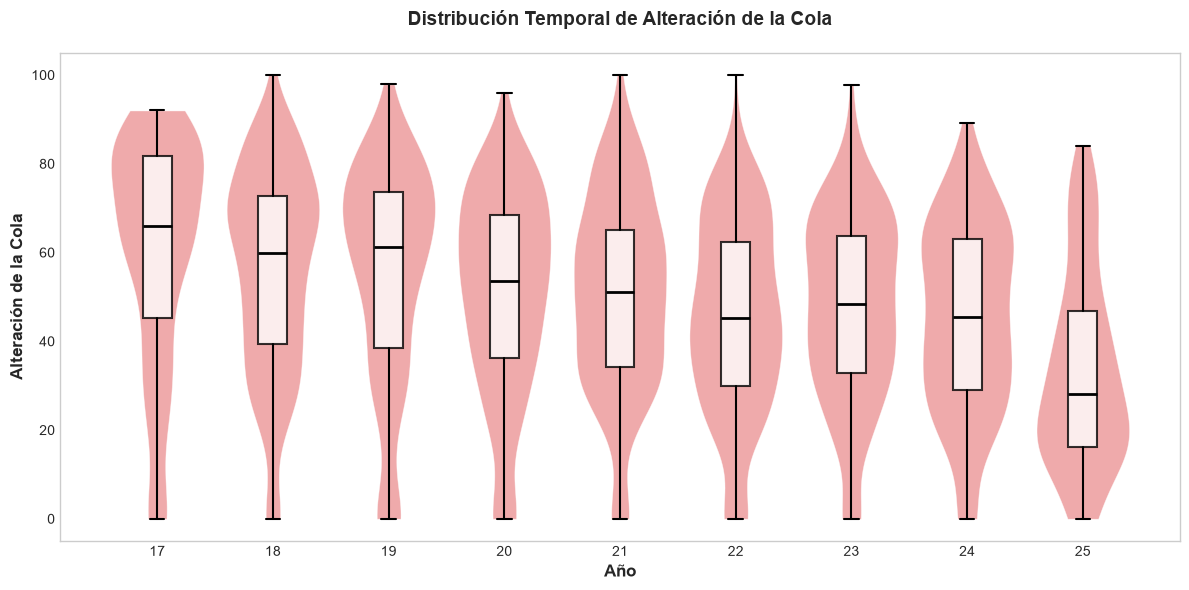

In [51]:
graficas_numericas(df,'alt_cola_pct', 'Alteración de la Cola', color='#E15759')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de espermatozoides con alteraciones morfológicas en la cola para cada año del período 2017-2025. Se observa una tendencia clara y sostenida a la disminución en el porcentaje de alteraciones de cola, pasando de 60.30% en 2017 a 33.29% en 2025. Esta es una tendencia favorable que sugiere una mejora significativa en la morfología de la cola a lo largo del tiempo. La variabilidad es moderada-alta (CV 41.71-65.68%) y la distribución pasa de tener sesgo negativo en los primeros años a sesgo positivo en 2025.

**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 60.3 | 66.0 | -5.7 | Valor más alto |
| 2018 | 55.6 | 59.8 | -4.2 | Descenso |
| 2019 | 54.8 | 61.3 | -6.5 | Descenso |
| 2020 | 50.5 | 53.5 | -3.0 | Descenso |
| 2021 | 50.2 | 51.0 | -0.8 | Descenso |
| 2022 | 45.0 | 45.3 | -0.3 | Descenso |
| 2023 | 47.1 | 48.4 | -1.3 | Descenso |
| 2024 | 44.9 | 45.4 | -0.5 | Descenso |
| 2025 | 33.3 | 28.1 | +5.2 | Valor más bajo |

- La media ha disminuido de 60.30% a 33.29% entre 2017 y 2025
- La mediana ha disminuido de 66.00% a 28.14% entre 2017 y 2025

**Evolución de las Alteraciones de Cola**

| Período | Media (%) | Mediana (%) | Cambio | Tendencia |
|---------|-----------|-------------|--------|-----------|
| 2017 | 60.3 | 66.0 | Valor inicial | Alto |
| 2018-2020 | 50.5 - 55.6 | 53.5 - 61.3 | -5 a -10% | Descenso |
| 2021-2024 | 44.9 - 50.2 | 45.4 - 51.0 | -10 a -15% | Descenso continuo |
| 2025 | 33.3 | 28.1 | -27% | Caída acelerada |

- Tendencia clara de disminución desde 2017
- Reducción total de -27 puntos porcentuales (45%) en la media entre 2017 y 2025
- Reducción en la mediana de -37.9 puntos porcentuales (57%) entre 2017 y 2025
- La caída se ha acelerado en 2025

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 25.7 | 36.5 | 42.7 | Variabilidad moderada |
| 2018 | 23.2 | 33.5 | 41.7 | Variabilidad más baja |
| 2019 | 24.9 | 35.2 | 45.5 | Variabilidad moderada |
| 2020 | 23.0 | 32.2 | 45.6 | Variabilidad moderada |
| 2021 | 22.0 | 30.9 | 43.8 | Variabilidad moderada |
| 2022 | 21.9 | 32.4 | 48.7 | Variabilidad moderada |
| 2023 | 21.1 | 31.0 | 44.8 | Variabilidad moderada |
| 2024 | 21.1 | 34.0 | 47.1 | Variabilidad moderada |
| 2025 | 21.9 | 30.6 | 65.7 | Variabilidad más alta |

- El CV ha aumentado de 42.68% (2017) a 65.68% (2025)
- El IQR ha disminuido ligeramente de 36.45 a 30.64 puntos
- La variabilidad relativa ha aumentado debido a la disminución de la media

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 92 | 92 | Rango amplio |
| 2018 | 0 | 100 | 100 | Rango completo |
| 2019 | 0 | 98 | 98 | Rango casi completo |
| 2020 | 0 | 96 | 96 | Rango casi completo |
| 2021 | 0 | 100 | 100 | Rango completo |
| 2022 | 0 | 100 | 100 | Rango completo |
| 2023 | 0 | 98 | 98 | Rango casi completo |
| 2024 | 0 | 89 | 89 | Rango amplio |
| 2025 | 0 | 84 | 84 | Rango más reducido |

- El valor mínimo es 0% en todos los años
- El rango se ha reducido en los últimos años

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | -0.93 | -0.08 | Sesgo negativo moderado |
| 2018 | -0.54 | -0.38 | Sesgo negativo leve |
| 2019 | -0.79 | -0.22 | Sesgo negativo moderado |
| 2020 | -0.58 | -0.34 | Sesgo negativo leve |
| 2021 | -0.25 | -0.33 | Sesgo negativo leve |
| 2022 | -0.21 | -0.56 | Sesgo negativo leve |
| 2023 | -0.33 | -0.42 | Sesgo negativo leve |
| 2024 | -0.20 | -0.72 | Sesgo negativo leve |
| 2025 | 0.59 | -0.56 | Sesgo positivo |

- Los primeros años (2017-2024) presentan sesgo negativo (skew < 0)
- 2025 es el único año con sesgo positivo (skew = 0.59)
- El cambio en la asimetría indica una transformación en la distribución
- La curtosis es negativa en todos los años (distribuciones platicúrticas)

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Porcentaje de Alteraciones de Cola por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de espermatozoides con alteraciones morfológicas en la cola, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los porcentajes de alteraciones de cola entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en las alteraciones de cola de los pacientes.

In [52]:
funcion_numericas(df,'alt_cola_pct', 'Alteración de la Cola')


=== Alteración de la Cola ===

Prueba de Normalidad Global
- n = 2767, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 351, p-value = <1e-10 → No Normal
- Año 18: n = 400, p-value = 3.27e-09 → No Normal
- Año 19: n = 376, p-value = <1e-10 → No Normal
- Año 20: n = 255, p-value = 1.95e-07 → No Normal
- Año 21: n = 304, p-value = 3.69e-04 → No Normal
- Año 22: n = 287, p-value = 9.17e-05 → No Normal
- Año 23: n = 262, p-value = 3.15e-04 → No Normal
- Año 24: n = 256, p-value = 4.31e-04 → No Normal
- Año 25: n = 276, p-value = 9.80e-09 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.40, p-value = 1.91e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 287.70, p-value = <1e-10
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferron

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en el porcentaje de alteraciones de cola entre los años de estudio (p < 1e-10). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años evaluados. Las pruebas post-hoc con corrección de Bonferroni identifican un patrón claro de disminución sostenida, 2017 es el año con el porcentaje más alto de alteraciones de cola (60.30%), difiriendo de prácticamente todos los años posteriores, mientras que 2025 es el año con el porcentaje más bajo (33.29%), difiriendo de todos los años anteriores.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- Las varianzas son similares entre los años (CV 41.71-65.68%)
- Sin embargo, la falta de normalidad impide usar ANOVA

**Análisis Principal**

- Existe evidencia abrumadora de que las alteraciones de cola varían entre los años (p < 0.001)
- El estadístico H = 287.70 indica una diferencia extremadamente fuerte
- La probabilidad de observar estas diferencias por azar es prácticamente nula

**Año 2017 vs Años Posteriores**

| Par de Años | p-value | Media 2017 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2018 | 0.045 | 60.3 | 55.6 | -4.7 |
| 2017 vs 2019 | 0.048 | 60.3 | 54.8 | -5.5 |
| 2017 vs 2020 | < 0.001 | 60.3 | 50.5 | -9.8 |
| 2017 vs 2021 | < 0.001 | 60.3 | 50.2 | -10.1 |
| 2017 vs 2022 | < 0.001 | 60.3 | 45.0 | -15.3 |
| 2017 vs 2023 | < 0.001 | 60.3 | 47.1 | -13.2 |
| 2017 vs 2024 | < 0.001 | 60.3 | 44.9 | -15.4 |
| 2017 vs 2025 | < 0.001 | 60.3 | 33.3 | -27.0 |

**Año 2025 vs Todos los Años Anteriores**

| Par de Años | p-value | Media 2025 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2018 vs 2025 | < 0.001 | 33.3 | 55.6 | -22.3 |
| 2019 vs 2025 | < 0.001 | 33.3 | 54.8 | -21.5 |
| 2020 vs 2025 | < 0.001 | 33.3 | 50.5 | -17.2 |
| 2021 vs 2025 | < 0.001 | 33.3 | 50.2 | -16.9 |
| 2022 vs 2025 | < 0.001 | 33.3 | 45.0 | -11.7 |
| 2023 vs 2025 | < 0.001 | 33.3 | 47.1 | -13.8 |
| 2024 vs 2025 | < 0.001 | 33.3 | 44.9 | -11.6 |

**Años 2018-2019 vs 2022-2025:**

| Par de Años | p-value | Diferencia |
|-------------|---------|------------|
| 2018 vs 2022 | < 0.001 | -10.6 |
| 2018 vs 2023 | < 0.001 | -8.5 |
| 2018 vs 2024 | < 0.001 | -10.7 |
| 2019 vs 2022 | < 0.001 | -9.8 |
| 2019 vs 2023 | < 0.001 | -7.7 |
| 2019 vs 2024 | < 0.001 | -9.9 |

### **Alteración de la Pieza Intermedia**

#### **Análisis Descriptivo y Visual de la Distribución del Porcentaje de Alteraciones de la Pieza Intermedia a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de espermatozoides con alteraciones morfológicas en la pieza intermedia, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en las alteraciones de la pieza intermedia de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Alteración de Pieza Intermedia según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,356,36.93,20.56,0.00,19.95,38.89,52.04,79.30,32.09,55.67,-0.01,-0.85
18,400,32.63,19.11,0.00,16.32,32.08,44.24,95.90,27.92,58.55,0.43,-0.27
19,380,32.07,18.25,0.00,19.77,32.12,44.71,84.00,24.93,56.90,0.13,-0.42
20,255,30.00,16.31,0.00,19.79,29.59,40.40,77.00,20.61,54.35,0.25,0.06
21,304,32.53,16.37,0.00,21.20,31.95,42.53,89.17,21.33,50.33,0.32,0.19
22,287,39.77,18.19,0.00,29.45,41.41,50.00,98.00,20.55,45.74,-0.27,0.28
23,262,39.29,16.15,0.00,30.05,41.32,50.00,85.26,19.95,41.10,-0.39,0.32
24,256,38.47,14.65,0.00,31.57,38.94,47.43,74.00,15.86,38.07,-0.49,0.80
25,276,40.69,16.72,0.00,32.64,40.93,49.10,88.88,16.46,41.09,-0.34,0.79


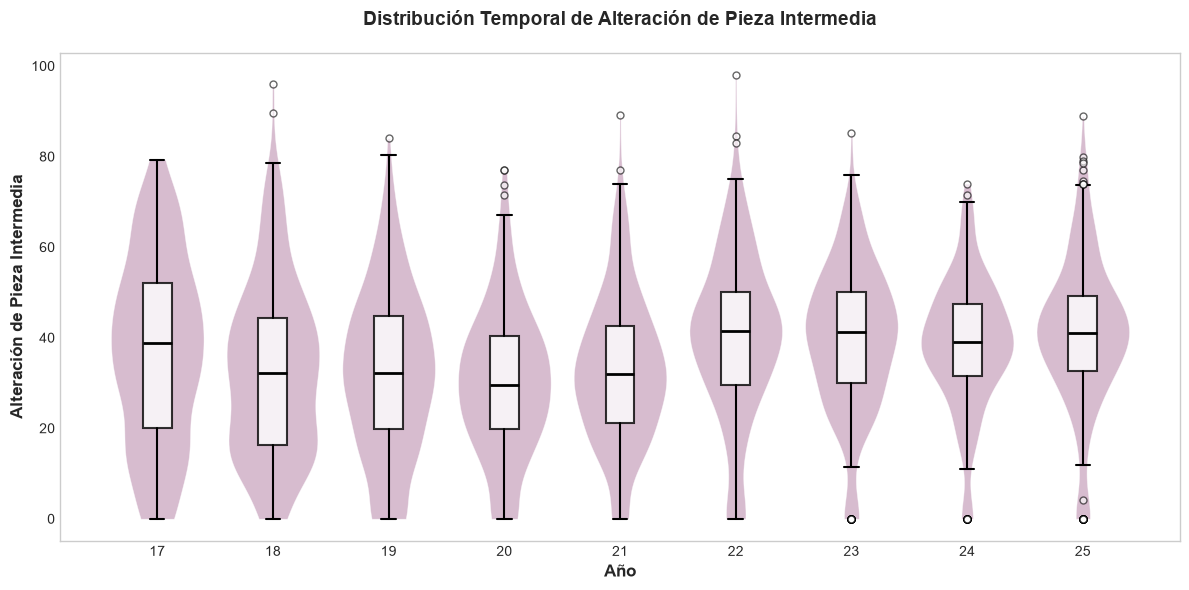

In [53]:
graficas_numericas(df,'alt_pieza_intermedia_pct', 'Alteración de Pieza Intermedia', color='#B07AA1')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de espermatozoides con alteraciones morfológicas en la pieza intermedia para cada año del período 2017-2025. Se observa que el porcentaje de alteraciones varía entre 30.00% y 40.69%, sin una tendencia clara de aumento o disminución. La variabilidad es moderada-alta (CV 38.07-58.55%) y la distribución es relativamente simétrica en la mayoría de los años.


**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 36.9 | 38.9 | -2.0 | Distribución ligeramente simétrica |
| 2018 | 32.6 | 32.1 | +0.5 | Distribución simétrica |
| 2019 | 32.1 | 32.1 | 0.0 | Distribución perfectamente simétrica |
| 2020 | 30.0 | 29.6 | +0.4 | Valor más bajo |
| 2021 | 32.5 | 32.0 | +0.5 | Distribución simétrica |
| 2022 | 39.8 | 41.4 | -1.6 | Distribución ligeramente simétrica |
| 2023 | 39.3 | 41.3 | -2.0 | Distribución ligeramente simétrica |
| 2024 | 38.5 | 38.9 | -0.4 | Distribución simétrica |
| 2025 | 40.7 | 40.9 | -0.2 | Valor más alto |

- La media varía entre 30.00% (2020) y 40.69% (2025)
- La mediana es muy cercana a la media en todos los años (distribución simétrica)
- 2019 tiene la distribución más simétrica (media ≈ mediana)
- 2020 presenta el valor más bajo (30.00%)
- 2025 presenta el valor más alto (40.69%)

**Evolución de las Alteraciones de la Pieza Intermedia**

| Período | Media (%) | Mediana (%) | Tendencia |
|---------|-----------|-------------|-----------|
| 2017 | 36.9 | 38.9 | Valor inicial |
| 2018-2021 | 30.0 - 32.6 | 29.6 - 32.1 | Descenso (-5 a -7%) |
| 2022-2025 | 38.5 - 40.7 | 38.9 - 41.4 | Aumento (+6 a +10%) |

- Tendencia en forma de U, descenso hasta 2020, luego aumento
- Valor más bajo, 2020 (30.00%)
- Valor más alto, 2025 (40.69%)
- Rango de variación, 10.7 puntos entre el mínimo y el máximo

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 20.6 | 32.1 | 55.7 | Variabilidad más alta |
| 2018 | 19.1 | 27.9 | 58.6 | Variabilidad más alta |
| 2019 | 18.3 | 24.9 | 56.9 | Variabilidad alta |
| 2020 | 16.3 | 20.6 | 54.4 | Variabilidad alta |
| 2021 | 16.4 | 21.3 | 50.3 | Variabilidad alta |
| 2022 | 18.2 | 20.6 | 45.7 | Variabilidad más baja |
| 2023 | 16.2 | 20.0 | 41.1 | Variabilidad más baja |
| 2024 | 14.7 | 15.9 | 38.1 | Variabilidad más baja |
| 2025 | 16.7 | 16.5 | 41.1 | Variabilidad más baja |

- La variabilidad ha disminuido desde 2017 (CV 55.67% → 38.07% en 2024)
- El IQR se ha reducido de 32.09 (2017) a 15.86 (2024)
- La reducción de la variabilidad sugiere una mayor homogeneidad en la población

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 79 | 79 | Rango amplio |
| 2018 | 0 | 96 | 96 | Rango muy amplio |
| 2019 | 0 | 84 | 84 | Rango amplio |
| 2020 | 0 | 77 | 77 | Rango amplio |
| 2021 | 0 | 89 | 89 | Rango amplio |
| 2022 | 0 | 98 | 98 | Rango muy amplio |
| 2023 | 0 | 85 | 85 | Rango amplio |
| 2024 | 0 | 74 | 74 | Rango moderado |
| 2025 | 0 | 89 | 89 | Rango amplio |

- El valor mínimo es 0% en todos los años
- El valor máximo es 74-98% en todos los años
- 2024 tiene el rango más reducido (74 puntos)

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | -0.01 | -0.85 | Distribución casi perfectamente simétrica |
| 2018 | 0.43 | -0.27 | Sesgo positivo leve |
| 2019 | 0.13 | -0.42 | Sesgo positivo leve |
| 2020 | 0.25 | 0.06 | Sesgo positivo leve |
| 2021 | 0.32 | 0.19 | Sesgo positivo leve |
| 2022 | -0.27 | 0.28 | Sesgo negativo leve |
| 2023 | -0.39 | 0.32 | Sesgo negativo leve |
| 2024 | -0.49 | 0.80 | Sesgo negativo moderado |
| 2025 | -0.34 | 0.79 | Sesgo negativo leve |

- La distribución es muy simétrica en todos los años
- 2017 tiene la distribución más simétrica (skew = -0.01)
- El sesgo es pequeño en todos los años (-0.49 a 0.43)
- La curtosis es cercana a 0 en todos los años

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Porcentaje de Alteraciones de la Pieza Intermedia por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de espermatozoides con alteraciones morfológicas en la pieza intermedia, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los porcentajes de alteraciones de la pieza intermedia entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en las alteraciones de la pieza intermedia de los pacientes.

In [54]:
funcion_numericas(df,'alt_pieza_intermedia_pct', 'Alteración de la Pieza Intermedia')


=== Alteración de la Pieza Intermedia ===

Prueba de Normalidad Global
- n = 2776, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 356, p-value = 1.33e-05 → No Normal
- Año 18: n = 400, p-value = 5.37e-06 → No Normal
- Año 19: n = 380, p-value = 3.66e-04 → No Normal
- Año 20: n = 255, p-value = 4.41e-03 → No Normal
- Año 21: n = 304, p-value = 4.78e-03 → No Normal
- Año 22: n = 287, p-value = 4.42e-05 → No Normal
- Año 23: n = 262, p-value = 2.69e-04 → No Normal
- Año 24: n = 256, p-value = 7.95e-06 → No Normal
- Año 25: n = 276, p-value = 1.45e-06 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 9.89, p-value = <1e-10

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 142.84, p-value = <1e-10
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-val

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en el porcentaje de alteraciones de la pieza intermedia entre los años de estudio (p < 1e-10). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años y a la falta de homogeneidad de varianzas (p < 0.001). Las pruebas post-hoc con corrección de Bonferroni identifican un patrón claro de dos grupos: 2017-2021 (alteraciones más bajas) vs 2022-2025 (alteraciones más altas), con una aumento significativa entre ambos períodos.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- Las varianzas son significativamente diferentes entre los años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- Existe evidencia abrumadora de que las alteraciones de la pieza intermedia varían entre los años (p < 0.001)
- El estadístico H = 142.84 indica una diferencia muy fuerte
- La probabilidad de observar estas diferencias por azar es prácticamente nula

### **Índice de Teratozoospermia**

#### **Análisis Descriptivo y Visual de la Distribución del Índice de Teratozoospermia a lo Largo del Tiempo**

Para caracterizar la evolución temporal del índice de teratozoospermia (que mide el número promedio de defectos por espermatozoide anormal) en las muestras seminales, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en el índice de teratozoospermia de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.


Estadísticos de Índice de Teratozoospermia según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,354,1.91,0.61,0.00,1.64,2.02,2.34,2.69,0.70,32.10,-1.67,3.04
18,398,1.81,0.51,0.00,1.58,1.92,2.11,2.77,0.53,27.94,-1.89,4.99
19,380,1.77,0.62,0.00,1.60,1.93,2.11,2.96,0.50,34.86,-1.79,3.07
20,256,1.72,0.56,0.00,1.59,1.83,2.03,2.95,0.44,32.79,-1.90,3.92
21,303,1.76,0.50,0.00,1.63,1.81,2.01,3.03,0.38,28.42,-1.90,5.33
22,288,1.75,0.56,0.00,1.65,1.87,2.06,2.72,0.41,32.18,-2.02,4.23
23,263,1.80,0.48,0.00,1.72,1.90,2.06,2.59,0.34,26.80,-2.65,7.77
24,256,1.77,0.47,0.00,1.68,1.84,2.02,2.83,0.34,26.27,-2.40,7.49
25,276,1.68,0.49,0.00,1.53,1.72,2.00,2.63,0.47,29.35,-2.09,5.32


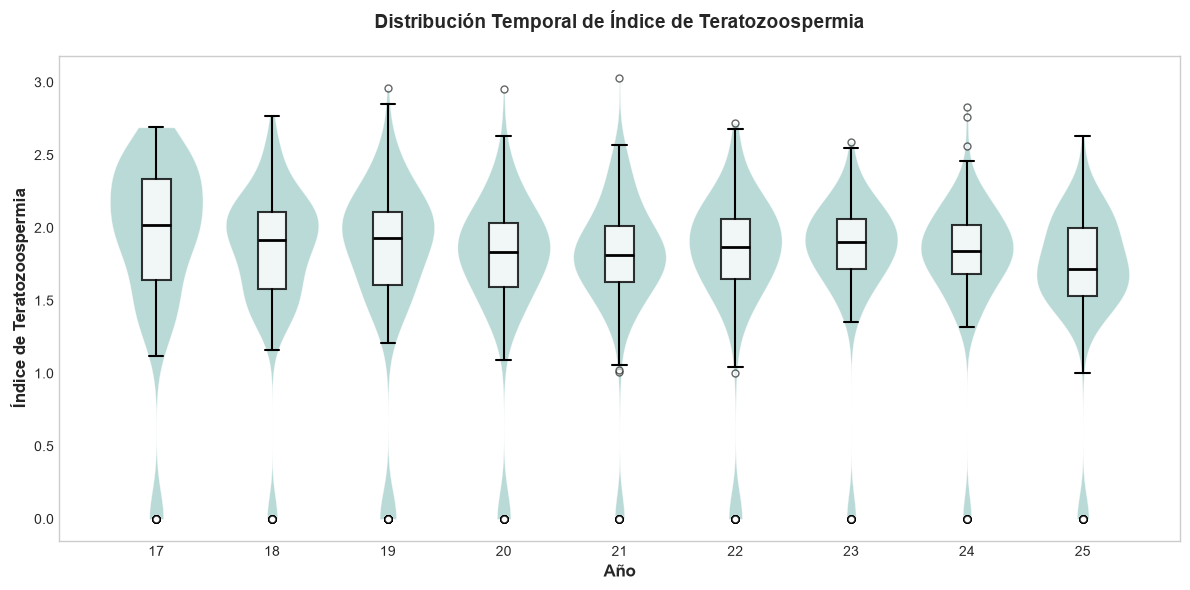

In [55]:
graficas_numericas(df,'indice_teratozoospermia', 'Índice de Teratozoospermia', color='#76B7B2')

**Resumen General**

La tabla muestra los estadísticos descriptivos del índice de teratozoospermia (ITZ) para cada año del período 2017-2025. El ITZ mide el número promedio de defectos por espermatozoide anormal, y sus valores varían entre 1.68 y 1.91 a lo largo del período. Se observa una tendencia general a la disminución, lo que indica que los espermatozoides presentan menos defectos promedio por célula en los años más recientes. La variabilidad es moderada (CV 26.27-34.86%) y la distribución presenta un fuerte sesgo negativo en todos los años.

**Análisis de Medidas de Tendencia Central**

| Año | Media | Mediana | Diferencia | Interpretación |
|-----|-------|---------|------------|----------------|
| 2017 | 1.91 | 2.02 | -0.11 | Valor más alto |
| 2018 | 1.81 | 1.92 | -0.11 | Descenso |
| 2019 | 1.77 | 1.93 | -0.16 | Descenso |
| 2020 | 1.72 | 1.83 | -0.11 | Descenso |
| 2021 | 1.76 | 1.81 | -0.05 | Descenso |
| 2022 | 1.75 | 1.87 | -0.12 | Descenso |
| 2023 | 1.80 | 1.90 | -0.10 | Leve aumento |
| 2024 | 1.77 | 1.84 | -0.07 | Estable |
| 2025 | 1.68| 1.72 | -0.04 | Valor más bajo |

- En todos los años, la media es menor que la mediana, indicando sesgo negativo
- El ITZ ha disminuido de 1.91 (2017) a 1.68 (2025)
- 2025 presenta el valor más bajo (media 1.68)
- 2017 presenta el valor más alto (media 1.91)

**Evolución del Índice de Teratozoospermia**

| Período | Media | Mediana | Cambio | Tendencia |
|---------|-------|---------|--------|-----------|
| 2017 | 1.91 | 2.02 | Valor inicial | Alto |
| 2018-2020 | 1.72 - 1.81 | 1.83 - 1.93 | -0.10 a -0.19 | Descenso |
| 2021-2024 | 1.75 - 1.80 | 1.81 - 1.90 | Estable | Estabilización |
| 2025 | 1.68 | 1.72 | -0.07 a -0.12 | Nuevo descenso |

- Tendencia general de disminución, ITZ más bajo en años recientes
- Reducción total de -0.23 puntos (12%) entre 2017 y 2025
- Descenso más pronunciado 2017 → 2020 (-0.19 puntos)
- 2025 presenta el punto más bajo de toda la serie

Análisis de Dispersión

| Año | Std | IQR | CV (%) | Interpretación |
|-----|-----|-----|--------|----------------|
| 2017 | 0.61 | 0.70 | 32.1 | Variabilidad más alta |
| 2018 | 0.51 | 0.53 | 27.9 | Variabilidad moderada |
| 2019 | 0.62 | 0.50 | 34.9 | Variabilidad más alta |
| 2020 | 0.56 | 0.44 | 32.8 | Variabilidad moderada |
| 2021 | 0.50 | 0.38 | 28.4 | Variabilidad moderada |
| 2022 | 0.56 | 0.41 | 32.2 | Variabilidad moderada |
| 2023 | 0.48 | 0.34 | 26.8 | Variabilidad más baja |
| 2024 | 0.47 | 0.34 | 26.3 | Variabilidad más baja |
| 2025 | 0.49 | 0.47 | 29.4 | Variabilidad moderada |

- El CV varía entre 26.27% y 34.86%, indicando una variabilidad moderada
- La variabilidad ha disminuido desde 2017 (CV 32.10% → 26.27% en 2024)
- El IQR se ha reducido de 0.70 (2017) a 0.34 (2024)
- 2023-2024 presentan la menor variabilidad

**Análisis de Valores Extremos**

| Año | Mínimo | Máximo | Rango | Interpretación |
|-----|--------|--------|-------|----------------|
| 2017 | 0.00 | 2.69 | 2.69 | Rango amplio |
| 2018 | 0.00 | 2.77 | 2.77 | Rango amplio |
| 2019 | 0.00 | 2.96 | 2.96 | Rango amplio |
| 2020 | 0.00 | 2.95 | 2.95 | Rango amplio |
| 2021 | 0.00 | 3.03 | 3.03 | Rango amplio |
| 2022 | 0.00 | 2.72 | 2.72 | Rango amplio |
| 2023 | 0.00 | 2.59 | 2.59 | Rango moderado |
| 2024 | 0.00 | 2.83 | 2.83 | Rango amplio |
| 2025 | 0.00 | 2.63 | 2.63 | Rango moderado |

- El valor mínimo es 0 en todos los años
- El valor máximo varía entre 2.59 y 3.03
- El rango se ha reducido ligeramente en los años recientes

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | -1.67 | 3.04 | Sesgo negativo fuerte |
| 2018 | -1.89 | 4.99 | Sesgo negativo fuerte |
| 2019 | -1.79 | 3.07 | Sesgo negativo fuerte |
| 2020 | -1.90 | 3.92 | Sesgo negativo fuerte |
| 2021 | -1.90 | 5.33 | Sesgo negativo fuerte |
| 2022 | -2.02 | 4.23 | Sesgo negativo fuerte |
| 2023 | -2.65 | 7.77 | Sesgo negativo extremo |
| 2024 | -2.40 | 7.49 | Sesgo negativo extremo |
| 2025 | -2.09 | 5.32 | Sesgo negativo fuerte |

- Todos los años presentan sesgo negativo (skew < -1.6)
- El sesgo se ha acentuado con el tiempo (de -1.67 a -2.65)
- 2023 muestra el sesgo más negativo (-2.65) y la mayor curtosis (7.77)
- La curtosis es alta en todos los años (> 3.0), indicando distribuciones apuntadas

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Índice de Teratozoospermia por Año**

Para evaluar si existe relación entre el año de estudio y el índice de teratozoospermia (número promedio de defectos por espermatozoide anormal), se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los índices de teratozoospermia entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en el índice de teratozoospermia de los pacientes.

In [56]:
funcion_numericas(df,'indice_teratozoospermia', 'Índice de Teratozoospermia')


=== Índice de Teratozoospermia ===

Prueba de Normalidad Global
- n = 2774, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 354, p-value = <1e-10 → No Normal
- Año 18: n = 398, p-value = <1e-10 → No Normal
- Año 19: n = 380, p-value = <1e-10 → No Normal
- Año 20: n = 256, p-value = <1e-10 → No Normal
- Año 21: n = 303, p-value = <1e-10 → No Normal
- Año 22: n = 288, p-value = <1e-10 → No Normal
- Año 23: n = 263, p-value = <1e-10 → No Normal
- Año 24: n = 256, p-value = <1e-10 → No Normal
- Año 25: n = 276, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 4.45, p-value = 2.25e-05

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 89.73, p-value = <1e-10
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     17

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en el índice de teratozoospermia entre los años de estudio (p < 1e-10). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años y a la falta de homogeneidad de varianzas (p < 0.001). Las pruebas post-hoc con corrección de Bonferroni identifican un patrón claro, 2017 es el año con el ITZ más alto (1.91), difiriendo de todos los años posteriores, mientras que 2025 es el año con el ITZ más bajo (1.68), difiriendo de varios años anteriores (2017, 2018, 2019, 2022, 2023).

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- Esto se debe al fuerte sesgo negativo y la presencia de valores extremos
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- Las varianzas son significativamente diferentes entre los años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- Existe evidencia abrumadora de que el ITZ varía entre los años (p < 0.001)
- El estadístico H = 89.73 indica una diferencia muy fuerte
- La probabilidad de observar estas diferencias por azar es prácticamente nula


**Año 2017 vs Todos los Años 2018-2025**

| Par de Años | p-value | Media 2017 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2018 | 0.001 | 1.91 | 1.81 | -0.10 |
| 2017 vs 2019 | 0.006 | 1.91 | 1.77 | -0.14 |
| 2017 vs 2020 | < 0.001 | 1.91 | 1.72 | -0.19 |
| 2017 vs 2021 | < 0.001 | 1.91 | 1.76 | -0.15 |
| 2017 vs 2022 | < 0.001 | 1.91 | 1.75 | -0.16 |
| 2017 vs 2023 | 0.003 | 1.91 | 1.80 | -0.11 |
| 2017 vs 2024 | < 0.001 | 1.91 | 1.77 | -0.14 |
| 2017 vs 2025 | < 0.001 | 1.91 | 1.68 | -0.23 |

**Año 2025 vs Años Anteriores**

| Par de Años | p-value | Media 2025 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2018 vs 2025 | < 0.001 | 1.68 | 1.81 | -0.13 |
| 2019 vs 2025 | < 0.001 | 1.68 | 1.77 | -0.09 |
| 2022 vs 2025 | 0.013 | 1.68 | 1.75 | -0.07 |
| 2023 vs 2025 | 0.001 | 1.68 | 1.80 | -0.12 |

### **Aglutinación**

#### **Análisis Descriptivo y Visual de la Distribución del Porcentaje de Aglutinación a lo Largo del Tiempo**

Para caracterizar la evolución temporal del porcentaje de aglutinación espermática en las muestras seminales, se realiza una transformación previa de la variable, convirtiendo la categoría "SIN AGLUTINACION" al valor numérico 0. Posteriormente, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales en la aglutinación espermática de la población atendida, posibles cambios en la variabilidad y anomalías en la distribución a lo largo del período estudiado.

In [57]:
df['aglutinacion_pct'] = pd.to_numeric(df['aglutinacion_pct'].replace('SIN AGLUTINACION', 0))


Estadísticos de Aglutinación según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,333,6.70,5.92,0.00,0.00,5.00,10.00,24.00,10.00,88.36,0.68,-0.24
18,288,6.22,6.07,0.00,0.00,5.00,10.00,35.00,10.00,97.62,1.18,2.35
19,297,6.27,7.35,0.00,0.00,5.00,10.00,70.00,10.00,117.24,3.10,20.47
20,209,5.72,6.71,0.00,0.00,5.00,10.00,40.00,10.00,117.29,1.32,2.70
21,251,6.30,6.94,0.00,0.00,6.00,10.00,30.00,10.00,110.14,0.98,0.49
22,232,5.82,7.14,0.00,0.00,5.00,10.00,35.00,10.00,122.74,1.23,1.31
23,210,4.30,5.89,0.00,0.00,0.00,10.00,28.00,10.00,136.95,1.16,0.59
24,218,4.32,5.56,0.00,0.00,0.00,8.75,25.00,8.75,128.61,1.16,0.84
25,242,4.69,5.72,0.00,0.00,3.00,10.00,30.00,10.00,121.88,1.26,1.90


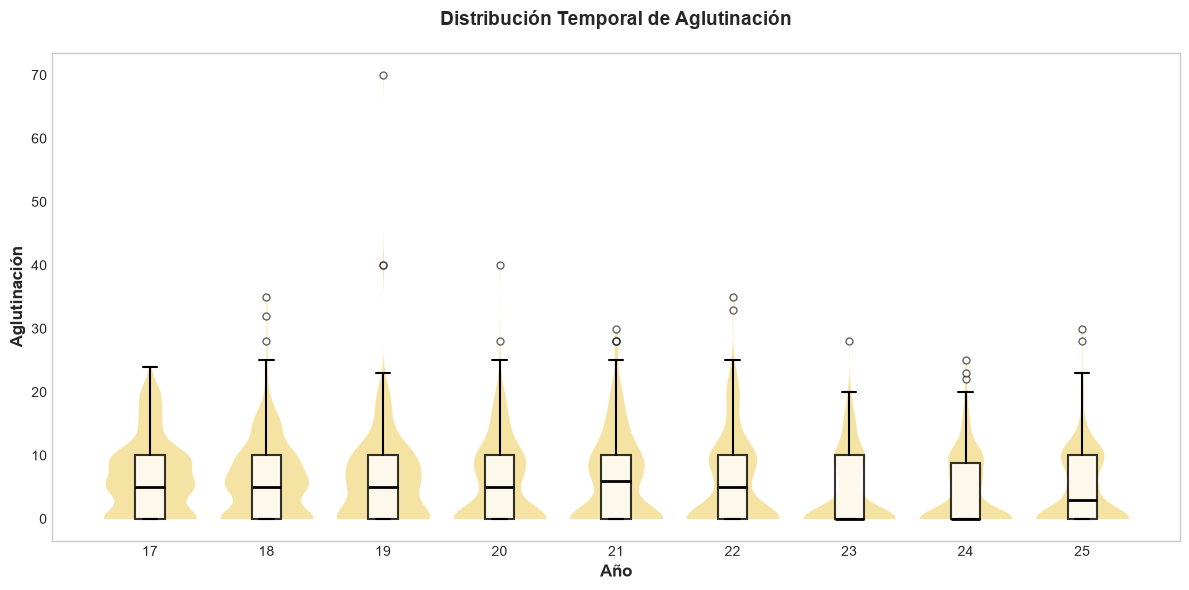

In [58]:
graficas_numericas(df,'aglutinacion_pct', 'Aglutinación', color='#EDC948')

**Resumen General**

La tabla muestra los estadísticos descriptivos del porcentaje de aglutinación espermática para cada año del período 2017-2025. Se observa que el porcentaje de aglutinación es bajo en todos los años, con medias que oscilan entre 4.30% y 6.70%. La variabilidad es extremadamente alta (CV 88.36-136.95%), y la distribución presenta un sesgo positivo en la mayoría de los años. La mediana es 0% o 5% en la mayoría de los años, lo que indica que al menos el 50% de los pacientes tienen muy poca o ninguna aglutinación.

**Análisis de Medidas de Tendencia Central**

| Año | Media (%) | Mediana (%) | Diferencia | Interpretación |
|-----|-----------|-------------|------------|----------------|
| 2017 | 6.70 | 5.00 | +1.70 | Valor más alto |
| 2018 | 6.22 | 5.00 | +1.22 | Segundo valor más alto |
| 2019 | 6.27 | 5.00 | +1.27 | Tercer valor más alto |
| 2020 | 5.72 | 5.00 | +0.72 | Moderado |
| 2021 | 6.30 | 6.00 | +0.30 | Moderado |
| 2022 | 5.82 | 5.00 | +0.82 | Moderado |
| 2023 | 4.30 | 0.00 | +4.30 | Valor más bajo |
| 2024 | 4.32 | 0.00 | +4.32 | Valor más bajo |
| 2025 | 4.69 | 3.00 | +1.69 | Bajo |

- En todos los años, la media es mayor que la mediana, indicando sesgo positivo
- La media ha disminuido de 6.70% (2017) a 4.69% (2025)
- 2023 y 2024 presentan los valores más bajos (media ~4.3%)
- La mediana es 0% en 2023 y 2024, indicando que más del 50% de los pacientes no tienen aglutinación

**Evolución de la Aglutinación**

| Período | Media (%) | Mediana (%) | Tendencia |
|---------|-----------|-------------|-----------|
| 2017-2019 | 6.22 - 6.70 | 5.00 | Nivel alto |
| 2020-2022 | 5.72 - 6.30 | 5.00 - 6.00 | Nivel intermedio |
| 2023-2025 | 4.30 - 4.69 | 0.00 - 3.00 | Nivel bajo |

- Tendencia general de disminución desde 2017
- Reducción total de -2.0 puntos porcentuales (30%) en la media entre 2017 y 2025
- Cambio en la mediana de 5% en años iniciales a 0-3% en años recientes
- Los niveles más bajos se registran en 2023-2025

**Análisis de Dispersión**

| Año | Std (%) | IQR (%) | CV (%) | Interpretación |
|-----|---------|---------|--------|----------------|
| 2017 | 5.92 | 10.0 | 88.4 | Variabilidad más baja |
| 2018 | 6.07 | 10.0 | 97.6 | Variabilidad extremadamente alta |
| 2019 | 7.35 | 10.0 | 117.2 | Variabilidad extremadamente alta |
| 2020 | 6.71 | 10.0 | 117.3 | Variabilidad extremadamente alta |
| 2021 | 6.94 | 10.0 | 110.1 | Variabilidad extremadamente alta |
| 2022 | 7.14 | 10.0 | 122.7 | Variabilidad más alta |
| 2023 | 5.89 | 10.0 | 137.0 | Variabilidad extremadamente alta |
| 2024 | 5.56 | 8.75 | 128.6 | Variabilidad extremadamente alta |
| 2025 | 5.72 | 10.0 | 121.9 | Variabilidad extremadamente alta |

- El CV es extremadamente alto (88-137%), indicando una variabilidad enorme
- La variabilidad ha aumentado desde 2017 (CV 88.36% → 136.95% en 2023)
- El IQR es de ~10 puntos en la mayoría de los años
- La alta variabilidad refleja que la mayoría de los pacientes tienen 0-10% y algunos tienen valores extremos

**Análisis de Valores Extremos**

| Año | Mínimo (%) | Máximo (%) | Rango | Interpretación |
|-----|------------|------------|-------|----------------|
| 2017 | 0 | 24 | 24 | Rango moderado |
| 2018 | 0 | 35 | 35 | Rango amplio |
| 2019 | 0 | 70 | 70 | Rango extremo |
| 2020 | 0 | 40 | 40 | Rango amplio |
| 2021 | 0 | 30 | 30 | Rango moderado |
| 2022 | 0 | 35 | 35 | Rango amplio |
| 2023 | 0 | 28 | 28 | Rango moderado |
| 2024 | 0 | 25 | 25 | Rango moderado |
| 2025 | 0 | 30 | 30 | Rango moderado |

- El valor mínimo es 0% en todos los años
- 2019 presenta el valor máximo más alto (70%)
- El rango se ha reducido en años recientes (de 70% en 2019 a 25-30% en 2024-2025)

**Análisis de Forma de la Distribución**

| Año | Skew (Asimetría) | Kurtosis (Curtosis) | Interpretación |
|-----|------------------|---------------------|----------------|
| 2017 | 0.68 | -0.24 | Sesgo positivo moderado |
| 2018 | 1.18 | 2.35 | Sesgo positivo fuerte |
| 2019 | 3.10 | 20.47 | Sesgo extremo |
| 2020 | 1.32 | 2.70 | Sesgo positivo fuerte |
| 2021 | 0.98 | 0.49 | Sesgo positivo moderado |
| 2022 | 1.23 | 1.31 | Sesgo positivo fuerte |
| 2023 | 1.16 | 0.59 | Sesgo positivo fuerte |
| 2024 | 1.16 | 0.84 | Sesgo positivo fuerte |
| 2025 | 1.26 | 1.90 | Sesgo positivo fuerte |

- Todos los años presentan sesgo positivo (skew > 0)
- 2019 muestra el sesgo más extremo (3.10) y la mayor curtosis (20.47)
- La distribución está sesgada hacia valores bajos, con una cola larga hacia valores altos

#### **Análisis de Normalidad, Homogeneidad de Varianzas y Comparación del Porcentaje de Aglutinación por Año**

Para evaluar si existe relación entre el año de estudio y el porcentaje de aglutinación espermática, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años; y (3) según el cumplimiento de los supuestos de normalidad y homogeneidad, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar los porcentajes de aglutinación entre años. En caso de encontrar diferencias significativas, se realizan pruebas post-hoc (Tukey HSD para ANOVA o Dunn con corrección de Bonferroni para Kruskal-Wallis) para identificar qué pares de años presentan diferencias estadísticamente significativas en la aglutinación espermática de los pacientes.

In [59]:
funcion_numericas(df,'aglutinacion_pct', 'Aglutinación')


=== Aglutinación ===

Prueba de Normalidad Global
- n = 2280, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 333, p-value = <1e-10 → No Normal
- Año 18: n = 288, p-value = <1e-10 → No Normal
- Año 19: n = 297, p-value = <1e-10 → No Normal
- Año 20: n = 209, p-value = <1e-10 → No Normal
- Año 21: n = 251, p-value = <1e-10 → No Normal
- Año 22: n = 232, p-value = <1e-10 → No Normal
- Año 23: n = 210, p-value = <1e-10 → No Normal
- Año 24: n = 218, p-value = <1e-10 → No Normal
- Año 25: n = 242, p-value = <1e-10 → No Normal

Evaluación de Supuestos para ANOVA
- Al menos un grupo no cumple normalidad

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 3.55, p-value = 4.22e-04

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 46.55, p-value = 1.87e-07
- Diferencias Significativas (p < 0.05)

Post-Hoc
Matriz de p-values (Bonferroni)
     17   18   19  

**Resumen General**

El análisis estadístico revela que existen diferencias altamente significativas en el porcentaje de aglutinación entre los años de estudio (p = 1.87e-07). La prueba no paramétrica de Kruskal-Wallis fue seleccionada debido al incumplimiento del supuesto de normalidad en todos los años y a la falta de homogeneidad de varianzas (p < 0.001). Las pruebas post-hoc con corrección de Bonferroni identifican un patrón claro, 2017 es el año con el porcentaje más alto de aglutinación (6.70%), difiriendo de 2023, 2024 y 2025, mientras que 2023 y 2024 presentan los valores más bajos (4.30-4.32%), difiriendo de varios años anteriores.

**Prueba de Normalidad**

- Todos los años presentan una distribución que no sigue una distribución normal
- Esto se debe al sesgo positivo y la presencia de valores extremos (0-70%)
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- Las varianzas son significativamente diferentes entre los años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Análisis Principal**

- Existe evidencia muy sólida de que la aglutinación varía entre los años (p < 0.001)
- El estadístico H = 46.55 indica una diferencia fuerte
- La probabilidad de observar estas diferencias por azar es prácticamente nula

**Año 2017 vs Años Recientes**

| Par de Años | p-value | Media 2017 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2023 | < 0.001 | 6.70 | 4.30 | -2.40 |
| 2017 vs 2024 | < 0.001 | 6.70 | 4.32 | -2.38 |
| 2017 vs 2025 | 0.002 | 6.70 | 4.69 | -2.01 |

**Año 2018 vs Años Recientes**

| Par de Años | p-value | Media 2018 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2018 vs 2023 | 0.004 | 6.22 | 4.30 | -1.92 |
| 2018 vs 2024 | 0.011 | 6.22 | 4.32 | -1.90 |

**Año 2019 vs Años Recientes**

| Par de Años | p-value | Media 2019 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2019 vs 2023 | 0.018 | 6.27 | 4.30 | -1.97 |
| 2019 vs 2024 | 0.041 | 6.27 | 4.32 | -1.95 |

**Año 2021 vs Año 2023**

| Par de Años | p-value | Media 2021 | Media 2023 | Diferenza |
|-------------|---------|------------|------------|-----------|
| 2021 vs 2023 | 0.036 | 6.30 | 4.30 | -2.00 |